# Full Evaluation Report

Comprehensive evaluation notebook computing all metrics from Section 5.2:
- **5.2.1** Process Performance Metrics (cycle time, utilization, throughput, waiting time, flow efficiency)
- **5.2.2** Learning Efficiency Metrics (convergence speed, sample efficiency, training stability)
- **5.2.3** Operational Behaviour Metrics (queue length, overload ratio, workload fairness, volunteer ratio)

Point `EXPERIMENT_DIR` at a results directory and run all cells.

In [43]:
# ============================================================
# CONFIGURATION — edit these before running
# ============================================================

EXPERIMENT_DIR = "/Users/bjornkoemans/master-cope-FINAL/results/runs/loan_app/aside_no_collab_CHECK"

# Working hours for waiting-time calculations
USE_WORKING_TIME = True
WORK_START_HOUR = 7
WORK_END_HOUR = 15

# Which log set to use for process performance metrics
# "final_eval" = final evaluation on test data (recommended)
# "eval"       = periodic evaluation during training
# "train"      = training episodes
LOG_TYPE = "final_eval"

# Smoothing window for learning curves
SMOOTH_WINDOW = 5

# Overload threshold: queue length above which a resource is "overloaded"
OVERLOAD_THRESHOLD = 5

# Convergence criterion: coefficient of variation below this = converged
CONVERGENCE_CV_THRESHOLD = 0.10


In [44]:
# ============================================================
# IMPORTS & SETUP
# ============================================================
import os, sys, re, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# ── Find project root (directory containing src/ and results/) ──
def _find_project_root():
    candidates = [os.path.dirname(os.path.abspath("__file__"))]
    d = os.path.abspath(".")
    for _ in range(10):
        candidates.append(d)
        d = os.path.dirname(d)
    for c in candidates:
        if os.path.isdir(os.path.join(c, "src")) and os.path.isdir(os.path.join(c, "results")):
            return c
    return os.path.abspath(".")

PROJECT_ROOT = _find_project_root()
print(f"Project root: {PROJECT_ROOT}")

# Resolve EXPERIMENT_DIR relative to project root
if not os.path.isabs(EXPERIMENT_DIR):
    EXPERIMENT_DIR = os.path.join(PROJECT_ROOT, EXPERIMENT_DIR)
print(f"Experiment dir: {EXPERIMENT_DIR}")
print(f"Exists: {os.path.isdir(EXPERIMENT_DIR)}")

# Ensure src/ is on the path
_src_dir = os.path.join(PROJECT_ROOT, "src")
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

# Configure working hours
if USE_WORKING_TIME:
    try:
        from environment.work_schedule import working_seconds_between, configure
        configure(WORK_START_HOUR, WORK_END_HOUR)
        print(f"Working hours: Mon-Fri {WORK_START_HOUR:02d}:00-{WORK_END_HOUR:02d}:00")
        HAS_WORK_SCHEDULE = True
    except ImportError:
        print("WARNING: work_schedule module not found, using calendar time")
        HAS_WORK_SCHEDULE = False
else:
    HAS_WORK_SCHEDULE = False

# ── Academic plotting style (Times New Roman, grayscale) ──
# Try to find Times New Roman or fall back to serif
_serif_font = "Times New Roman"
_available = {f.name for f in fm.fontManager.ttflist}
if _serif_font not in _available:
    for fallback in ["Times", "Nimbus Roman", "Liberation Serif", "DejaVu Serif"]:
        if fallback in _available:
            _serif_font = fallback
            break
    else:
        _serif_font = "serif"
print(f"Font: {_serif_font}")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [_serif_font],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "axes.prop_cycle": plt.cycler(color=["#000000"]),  # all black
})

Project root: /Users/bjornkoemans/Documents/GitHub/master-cope
Experiment dir: /Users/bjornkoemans/master-cope-FINAL/results/runs/loan_app/aside_no_collab_CHECK
Exists: True
Working hours: Mon-Fri 07:00-15:00
Font: Times New Roman


In [45]:
# ============================================================
# RESOLVE EXPERIMENT DIRECTORY
# ============================================================
def resolve_experiment_dir(path):
    """If path contains timestamp subdirs, pick the latest one."""
    p = Path(path)
    if not p.is_dir():
        raise FileNotFoundError(f"Directory not found: {path}")
    subdirs = sorted(
        [d for d in p.iterdir()
         if d.is_dir() and re.match(r"^\d{8}_\d{6}", d.name)],
        key=lambda d: d.name,
    )
    if subdirs:
        resolved = str(subdirs[-1])
        print(f"Resolved: {resolved}")
        return resolved
    return str(p)

EXPERIMENT_DIR = resolve_experiment_dir(EXPERIMENT_DIR)
print(f"Experiment: {EXPERIMENT_DIR}")

Resolved: /Users/bjornkoemans/master-cope-FINAL/results/runs/loan_app/aside_no_collab_CHECK/20260407_125401
Experiment: /Users/bjornkoemans/master-cope-FINAL/results/runs/loan_app/aside_no_collab_CHECK/20260407_125401


In [46]:
# ============================================================
# DISCOVER METHODS & ASSIGN STYLES (consistent colour palette)
# ============================================================
def discover_methods(experiment_dir, log_type="final_eval"):
    """Find all methods in the experiment directory.
    Returns dict: method_name -> list of CSV log file paths.
    """
    methods = {}
    for entry in sorted(os.listdir(experiment_dir)):
        entry_path = os.path.join(experiment_dir, entry)
        if not os.path.isdir(entry_path) or entry in ("logs", "configs", ".tmp_configs"):
            continue
        log_dir = os.path.join(entry_path, "logs", log_type)
        if not os.path.isdir(log_dir):
            ts_dirs = sorted(glob.glob(os.path.join(entry_path, "[0-9]*_[0-9]*/logs", log_type)))
            if ts_dirs:
                log_dir = ts_dirs[-1]
            else:
                continue
        csv_files = sorted(glob.glob(os.path.join(log_dir, "*.csv")))
        if csv_files:
            methods[entry] = csv_files
    return methods

# Grayscale palette + line styles + hatch patterns for print-friendly distinction
_GRAY_SHADES = ["#000000", "#555555", "#999999", "#BBBBBB", "#DDDDDD", "#707070", "#404040"]
_LINE_STYLES = ["-", "--", "-.", ":", "-", "--", "-."]
_MARKERS = ["o", "s", "^", "D", "v", "P", "X"]
_HATCHES = ["", "///", "...", "xxx", "\\\\\\", "+++", "---"]

def assign_styles(methods):
    """Assign consistent colors per method category (plus line styles, markers, hatch)."""
    styles = {}
    names = list(methods.keys())
    for i, name in enumerate(names):
        styles[name] = {
            "color": _GRAY_SHADES[i % len(_GRAY_SHADES)],
            "linestyle": _LINE_STYLES[i % len(_LINE_STYLES)],
            "marker": _MARKERS[i % len(_MARKERS)],
            "hatch": _HATCHES[i % len(_HATCHES)],
        }
    # Consistent colour palette per method category
    COLOR_MAPPO_COMM     = "#8B1A4B"  # dark pink / burgundy  (MAPPO + IC3Net / +comm)
    COLOR_MAPPO          = "#E89450"  # orange                (MAPPO without comm)
    COLOR_RANDOM         = "#F4C430"  # yellow / gold         (Random baseline)
    COLOR_BEST_MEDIAN    = "#4A4A4A"  # dark gray             (Best Median baseline)
    COLOR_SHORTEST_QUEUE = "#A8A8A8"  # light gray            (Shortest Queue baseline)

    for name in names:
        low = name.lower()
        if "comm" in low:
            styles[name]["color"] = COLOR_MAPPO_COMM
        elif "mappo" in low:
            styles[name]["color"] = COLOR_MAPPO
        elif "random" in low:
            styles[name]["color"] = COLOR_RANDOM
        elif "best" in low and "median" in low:
            styles[name]["color"] = COLOR_BEST_MEDIAN
        elif "shortest" in low and "queue" in low:
            styles[name]["color"] = COLOR_SHORTEST_QUEUE
        elif "baseline" in low:
            # Unknown baseline — fall back to a neutral gray
            styles[name]["color"] = "#707070"
    return styles

# For backward compat: colors dict maps name -> gray shade
def assign_colors(methods):
    s = assign_styles(methods)
    return {name: s[name]["color"] for name in s}

def method_label(name):
    """Pretty label for method names — consistent across the notebook."""
    low = name.lower()
    if "baseline" in low:
        if "random" in low:
            return "Random"
        if "best" in low and "median" in low:
            return "Best Median"
        if "shortest" in low and "queue" in low:
            return "Shortest Queue"
        return name.replace("_", " ").title()
    if "mappo" in low:
        # IC3Net = MAPPO with the communication module (flagged by "comm" in the folder name)
        if "comm" in low:
            return "MAPPO + IC3Net"
        return "MAPPO"
    return name.replace("_", " ").title()

def method_sort_key(name):
    """Fixed presentation order used across all figures & tables.
    Lower = earlier in bar charts, legends, tables.
    """
    low = name.lower()
    if "mappo" in low and "comm" in low: return 0   # MAPPO + IC3Net
    if "mappo" in low:                   return 1   # MAPPO
    if "random" in low:                  return 2   # Random
    if "best" in low and "median" in low: return 3  # Best Median
    if "shortest" in low and "queue" in low: return 4  # Shortest Queue
    return 99

methods = discover_methods(EXPERIMENT_DIR, LOG_TYPE)
# Enforce consistent ordering across every downstream dict built by iterating `methods`
methods = dict(sorted(methods.items(), key=lambda kv: method_sort_key(kv[0])))

colors = assign_colors(methods)
styles = assign_styles(methods)

print(f"Found {len(methods)} methods (in presentation order):")
for name, files in methods.items():
    print(f"  {method_label(name):20s}  ({name})  — {len(files)} episodes")

Found 6 methods (in presentation order):
  MAPPO + IC3Net        (mappo_parallel_comm)  — 10 episodes
  MAPPO                 (mappo_parallel)  — 10 episodes
  Random                (baseline_random)  — 10 episodes
  Best Median           (baseline_best_median)  — 10 episodes
  Shortest Queue        (baseline_shortest_queue)  — 10 episodes
  Baseline Ground Truth  (baseline_ground_truth)  — 10 episodes


In [47]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def safe_parse_timestamps(series):
    """Parse timestamps with varying precision (with or without fractional seconds)."""
    return pd.to_datetime(series, format="ISO8601", utc=True)

def calc_minutes_between(start, end):
    """Calculate minutes between two timestamps, using working hours if configured."""
    if HAS_WORK_SCHEDULE and USE_WORKING_TIME:
        return working_seconds_between(start, end) / 60.0
    return (end - start).total_seconds() / 60.0

def smooth(values, window):
    """Moving average with edge padding."""
    if len(values) < window:
        return values
    padded = np.pad(values, (window // 2, window - 1 - window // 2), mode="edge")
    return np.convolve(padded, np.ones(window) / window, mode="valid")

def load_training_summary(method_dir):
    """Parse training_summary.txt for reward curves."""
    summary_path = os.path.join(method_dir, "training_summary.txt")
    if not os.path.exists(summary_path):
        return None
    text = open(summary_path).read()
    train_rewards, eval_rewards = [], []
    in_train, in_eval = False, False
    for line in text.splitlines():
        if "Episode Rewards:" in line:
            in_train, in_eval = True, False
            continue
        if "Evaluation Rewards:" in line:
            in_train, in_eval = False, True
            continue
        if line.strip() == "" or line.startswith("="):
            in_train = in_eval = False
            continue
        m = re.match(r"\s*(Episode|Eval)\s+\d+:\s*([\d.eE+-]+)", line)
        if m:
            val = float(m.group(2))
            if in_train:
                train_rewards.append(val)
            elif in_eval:
                eval_rewards.append(val)
    return {"train": train_rewards, "eval": eval_rewards} if train_rewards or eval_rewards else None

def _is_best_median(name):
    """Check if a method name refers to the Best Median baseline."""
    return "best_median" in name.lower() or "best median" in name.lower()

def _get_role(agent_name):
    """Extract role from agent name, e.g. 'Clerk-000001' -> 'Clerk'."""
    return agent_name.rsplit("-", 1)[0] if "-" in agent_name else agent_name

print("Helper functions loaded.")

Helper functions loaded.


In [48]:
# ============================================================
# LOAD ALL LOG DATA
# ============================================================
def load_episode_data(csv_files):
    """Load and parse all episodes for a method. Returns list of DataFrames."""
    episodes = []
    for f in csv_files:
        try:
            df = pd.read_csv(f)
            if len(df) == 0:
                continue
            for col in ["case_open_time", "case_completed_time",
                        "task_assigned_time", "task_started_time", "task_completed_time"]:
                if col in df.columns:
                    df[col] = safe_parse_timestamps(df[col])
            episodes.append(df)
        except Exception as e:
            print(f"  Warning: could not load {os.path.basename(f)}: {e}")
    return episodes

# Load all data
all_data = {}  # method_name -> list[DataFrame]
for name, csv_files in methods.items():
    episodes = load_episode_data(csv_files)
    all_data[name] = episodes
    print(f"  {name}: {len(episodes)} episodes loaded, {sum(len(ep) for ep in episodes)} total tasks")

  mappo_parallel_comm: 10 episodes loaded, 13740 total tasks
  mappo_parallel: 10 episodes loaded, 13740 total tasks
  baseline_random: 10 episodes loaded, 13740 total tasks
  baseline_best_median: 10 episodes loaded, 13740 total tasks
  baseline_shortest_queue: 10 episodes loaded, 13740 total tasks
  baseline_ground_truth: 10 episodes loaded, 13740 total tasks


-
-
-

#
#
 
5
.
2
.
1
 
P
r
o
c
e
s
s
 
P
e
r
f
o
r
m
a
n
c
e
 
M
e
t
r
i
c
s

In [49]:
# ============================================================
# COMPUTE PROCESS PERFORMANCE METRICS PER EPISODE
# ============================================================
def compute_process_metrics(df):
    """Compute process performance metrics for a single episode DataFrame.
    
    Returns dict with:
      - avg_cycle_time_min: mean case duration (open -> completed)
      - avg_waiting_time_min: mean task waiting time (assigned -> started)
      - avg_processing_time_min: mean task processing time (started -> completed)
      - resource_utilization: fraction of time agents are busy
      - case_throughput: cases completed per hour
      - flow_efficiency: processing_time / cycle_time ratio
    """
    metrics = {}
    
    # ── Cycle time (case level) ──
    cases = df.groupby("case_id").agg(
        open_time=("case_open_time", "first"),
        completed_time=("case_completed_time", "first"),
        n_tasks=("task_id", "count"),
    ).dropna(subset=["open_time", "completed_time"])
    
    cycle_times = []
    for _, row in cases.iterrows():
        ct = calc_minutes_between(row["open_time"], row["completed_time"])
        cycle_times.append(ct)
    metrics["avg_cycle_time_min"] = np.mean(cycle_times) if cycle_times else np.nan
    metrics["std_cycle_time_min"] = np.std(cycle_times) if cycle_times else np.nan
    metrics["n_cases"] = len(cases)
    
    # ── Waiting time (task level: assigned -> started) ──
    waiting_times = []
    for _, row in df.iterrows():
        if pd.notna(row.get("task_assigned_time")) and pd.notna(row.get("task_started_time")):
            wt = calc_minutes_between(row["task_assigned_time"], row["task_started_time"])
            waiting_times.append(max(0, wt))
    metrics["avg_waiting_time_min"] = np.mean(waiting_times) if waiting_times else np.nan
    metrics["std_waiting_time_min"] = np.std(waiting_times) if waiting_times else np.nan
    
    # ── Processing time (task level: started -> completed) ──
    processing_times = []
    for _, row in df.iterrows():
        if pd.notna(row.get("task_started_time")) and pd.notna(row.get("task_completed_time")):
            pt = calc_minutes_between(row["task_started_time"], row["task_completed_time"])
            processing_times.append(max(0, pt))
    metrics["avg_processing_time_min"] = np.mean(processing_times) if processing_times else np.nan
    
    # ── Resource utilization ──
    # Sum of all agent busy time / (n_agents * simulation span)
    if len(df) > 0 and "task_agent_id" in df.columns:
        agents = df["task_agent_id"].unique()
        sim_start = df["case_open_time"].min()
        sim_end = df["task_completed_time"].max()
        if pd.notna(sim_start) and pd.notna(sim_end):
            sim_duration_min = calc_minutes_between(sim_start, sim_end)
            total_capacity_min = len(agents) * sim_duration_min if sim_duration_min > 0 else 1
            total_busy_min = sum(processing_times)
            metrics["resource_utilization"] = min(1.0, total_busy_min / total_capacity_min)
        else:
            metrics["resource_utilization"] = np.nan
        metrics["n_agents"] = len(agents)
    else:
        metrics["resource_utilization"] = np.nan
        metrics["n_agents"] = 0
    
    # ── Case throughput (cases per hour) ──
    if len(cases) > 0 and pd.notna(sim_start) and pd.notna(sim_end):
        sim_hours = calc_minutes_between(sim_start, sim_end) / 60.0
        metrics["case_throughput_per_hour"] = len(cases) / sim_hours if sim_hours > 0 else 0
    else:
        metrics["case_throughput_per_hour"] = np.nan
    
    # ── Flow efficiency (processing / cycle time) ──
    # Per case: sum of task processing times / case cycle time
    flow_effs = []
    for case_id, case_row in cases.iterrows():
        case_tasks = df[df["case_id"] == case_id]
        case_proc = 0
        for _, t in case_tasks.iterrows():
            if pd.notna(t["task_started_time"]) and pd.notna(t["task_completed_time"]):
                case_proc += calc_minutes_between(t["task_started_time"], t["task_completed_time"])
        case_cycle = calc_minutes_between(case_row["open_time"], case_row["completed_time"])
        if case_cycle > 0:
            flow_effs.append(case_proc / case_cycle)
    metrics["flow_efficiency"] = np.mean(flow_effs) if flow_effs else np.nan
    
    metrics["n_tasks"] = len(df)
    return metrics

# Compute for all methods
process_metrics = {}  # method -> list[dict] (one per episode)
for name, episodes in all_data.items():
    ep_metrics = [compute_process_metrics(ep) for ep in episodes]
    process_metrics[name] = ep_metrics

print("Process performance metrics computed.")

Process performance metrics computed.


In [50]:
# ============================================================
# TABLE 1: Process Performance Summary
# ============================================================
time_label = f"working hours ({WORK_START_HOUR:02d}:00-{WORK_END_HOUR:02d}:00)" if USE_WORKING_TIME else "calendar time"

rows = []
for name, ep_metrics in process_metrics.items():
    vals = {k: [m[k] for m in ep_metrics if not np.isnan(m.get(k, np.nan))]
            for k in ["avg_cycle_time_min", "avg_waiting_time_min", "avg_processing_time_min",
                       "resource_utilization", "case_throughput_per_hour", "flow_efficiency"]}
    row = {"Method": method_label(name)}
    for k, v in vals.items():
        if v:
            row[k + " (mean)"] = np.mean(v)
            row[k + " (std)"] = np.std(v)
        else:
            row[k + " (mean)"] = np.nan
            row[k + " (std)"] = np.nan
    row["n_episodes"] = len(ep_metrics)
    rows.append(row)

df_process = pd.DataFrame(rows).set_index("Method")

# Display a clean summary table
summary_cols = {
    "Cycle Time (min)": ("avg_cycle_time_min (mean)", "avg_cycle_time_min (std)"),
    "Waiting Time (min)": ("avg_waiting_time_min (mean)", "avg_waiting_time_min (std)"),
    "Processing Time (min)": ("avg_processing_time_min (mean)", "avg_processing_time_min (std)"),
    "Utilization": ("resource_utilization (mean)", "resource_utilization (std)"),
    "Throughput (/hr)": ("case_throughput_per_hour (mean)", "case_throughput_per_hour (std)"),
    "Flow Efficiency": ("flow_efficiency (mean)", "flow_efficiency (std)"),
}

display_rows = []
for method in df_process.index:
    r = {"Method": method}
    for label, (mean_col, std_col) in summary_cols.items():
        m = df_process.loc[method, mean_col]
        s = df_process.loc[method, std_col]
        if pd.notna(m):
            if "Utilization" in label or "Efficiency" in label:
                r[label] = f"{m:.1%} \u00b1 {s:.1%}"
            elif "Throughput" in label:
                r[label] = f"{m:.1f} \u00b1 {s:.1f}"
            else:
                r[label] = f"{m:.1f} \u00b1 {s:.1f}"
        else:
            r[label] = "—"
    r["Episodes"] = int(df_process.loc[method, "n_episodes"])
    display_rows.append(r)

df_display = pd.DataFrame(display_rows).set_index("Method")
print(f"\n{'='*90}")
print(f"  Table 1: Process Performance Metrics ({time_label})")
print(f"{'='*90}")
display(df_display)


  Table 1: Process Performance Metrics (working hours (07:00-15:00))


,Cycle Time (min),Waiting Time (min),Processing Time (min),Utilization,Throughput (/hr),Flow Efficiency,Episodes
Method,,,,,,,
MAPPO + IC3Net,559.5 ± 106.2,54.5 ± 17.6,41.8 ± 2.7,33.4% ± 2.1%,1.2 ± 0.0,65.4% ± 6.4%,10
MAPPO,1235.7 ± 395.5,176.6 ± 78.4,41.2 ± 1.7,28.1% ± 2.9%,1.0 ± 0.1,40.1% ± 11.6%,10
Random,539.2 ± 85.3,50.2 ± 12.1,41.7 ± 2.1,33.7% ± 1.7%,1.2 ± 0.0,66.5% ± 5.9%,10
Best Median,3315.1 ± 491.8,739.9 ± 179.8,44.8 ± 2.1,26.9% ± 1.6%,0.8 ± 0.1,15.3% ± 1.7%,10
Shortest Queue,321.7 ± 30.2,13.8 ± 3.6,41.0 ± 1.9,34.0% ± 1.6%,1.3 ± 0.0,102.5% ± 5.2%,10
Baseline Ground Truth,525.1 ± 102.8,47.4 ± 15.7,42.3 ± 2.3,34.1% ± 2.0%,1.2 ± 0.0,70.8% ± 7.6%,10


In [51]:
# ============================================================
# TABLE 1d: Train vs Test Comparison
# Loads training data separately and compares key metrics
# ============================================================
time_label = f"working hours ({WORK_START_HOUR:02d}:00-{WORK_END_HOUR:02d}:00)" if USE_WORKING_TIME else "calendar time"

# Load training data (separate from final_eval)
train_methods = discover_methods(EXPERIMENT_DIR, log_type="train")
train_all_data = {}
for name, csv_files in train_methods.items():
    eps = load_episode_data(csv_files)
    if eps:
        train_all_data[name] = eps

# Compute process metrics for train data
train_process_metrics = {}
for name, episodes in train_all_data.items():
    ep_metrics_list = []
    for ep in episodes:
        if ep.empty:
            continue
        m = {}
        # Task waiting time (assigned → started)
        if "task_assigned_time" in ep.columns and "task_started_time" in ep.columns:
            waits = ep.apply(lambda r: calc_minutes_between(r["task_assigned_time"], r["task_started_time"]), axis=1)
            m["avg_waiting_time_min"] = waits.mean()
        # Case cycle time (open → completed)
        if "case_open_time" in ep.columns and "case_completed_time" in ep.columns:
            cases = ep.groupby("case_id").agg(
                open_time=("case_open_time", "min"),
                close_time=("case_completed_time", "max")
            ).dropna()
            if len(cases) > 0:
                cycles = cases.apply(lambda r: calc_minutes_between(r["open_time"], r["close_time"]), axis=1)
                m["avg_cycle_time_min"] = cycles.mean()
        # Processing time (started → completed)
        if "task_started_time" in ep.columns and "task_completed_time" in ep.columns:
            procs = ep.apply(lambda r: calc_minutes_between(r["task_started_time"], r["task_completed_time"]), axis=1)
            m["avg_processing_time_min"] = procs.mean()
        if m:
            ep_metrics_list.append(m)
    if ep_metrics_list:
        train_process_metrics[name] = ep_metrics_list

# Build comparison table
comparison_rows = []
metrics_to_compare = [
    ("Cycle Time (min)", "avg_cycle_time_min"),
    ("Waiting Time (min)", "avg_waiting_time_min"),
    ("Processing Time (min)", "avg_processing_time_min"),
]

for name in sorted(set(list(process_metrics.keys()) + list(train_process_metrics.keys()))):
    row = {"Method": method_label(name)}
    
    # Test data (final_eval) — from already computed process_metrics
    test_eps = process_metrics.get(name, [])
    # Train data
    train_eps = train_process_metrics.get(name, [])
    
    for label, key in metrics_to_compare:
        # Test
        test_vals = [m[key] for m in test_eps if key in m and not np.isnan(m[key])]
        if test_vals:
            row[f"{label} Test"] = f"{np.mean(test_vals):.1f} ± {np.std(test_vals):.1f}"
        else:
            row[f"{label} Test"] = "—"
        
        # Train (use last 5 episodes for stable estimate)
        train_vals = [m[key] for m in train_eps[-5:] if key in m and not np.isnan(m[key])]
        if train_vals:
            row[f"{label} Train"] = f"{np.mean(train_vals):.1f} ± {np.std(train_vals):.1f}"
        else:
            row[f"{label} Train"] = "—"
    
    row["N Test"] = len(test_eps)
    row["N Train"] = len(train_eps)
    comparison_rows.append(row)

df_comparison = pd.DataFrame(comparison_rows).set_index("Method")

# Reorder columns: group by metric (train | test)
ordered_cols = []
for label, _ in metrics_to_compare:
    ordered_cols.append(f"{label} Train")
    ordered_cols.append(f"{label} Test")
ordered_cols += ["N Train", "N Test"]
df_comparison = df_comparison[ordered_cols]

print(f"\n{'='*120}")
print(f"  Table 1d: Train vs Test Performance Comparison ({time_label})")
print(f"  Train = last 5 training episodes | Test = final evaluation episodes")
print(f"{'='*120}")
display(df_comparison)


  Table 1d: Train vs Test Performance Comparison (working hours (07:00-15:00))
  Train = last 5 training episodes | Test = final evaluation episodes


,Cycle Time (min) Train,Cycle Time (min) Test,Waiting Time (min) Train,Waiting Time (min) Test,Processing Time (min) Train,Processing Time (min) Test,N Train,N Test
Method,,,,,,,,
Best Median,10024.1 ± 1205.0,3315.1 ± 491.8,2643.3 ± 305.3,739.9 ± 179.8,43.5 ± 1.6,44.8 ± 2.1,10,10
Baseline Ground Truth,535.1 ± 33.0,525.1 ± 102.8,48.4 ± 5.4,47.4 ± 15.7,42.3 ± 0.9,42.3 ± 2.3,10,10
Random,606.1 ± 44.0,539.2 ± 85.3,60.5 ± 7.6,50.2 ± 12.1,42.3 ± 1.0,41.7 ± 2.1,10,10
Shortest Queue,341.9 ± 24.5,321.7 ± 30.2,15.1 ± 3.5,13.8 ± 3.6,42.0 ± 1.2,41.0 ± 1.9,10,10
MAPPO,601.7 ± 19.4,1235.7 ± 395.5,58.4 ± 3.7,176.6 ± 78.4,42.7 ± 0.4,41.2 ± 1.7,40,10
MAPPO + IC3Net,614.6 ± 69.8,559.5 ± 106.2,61.8 ± 11.0,54.5 ± 17.6,42.6 ± 0.9,41.8 ± 2.7,40,10


In [52]:
# ============================================================
# TABLE 1b: Case-Level Metrics (sum of task times per case)
# ============================================================
rows_case = []
for name, episodes in all_data.items():
    case_waiting = []
    case_processing = []
    case_total = []
    case_n_tasks = []
    
    for ep in episodes:
        for case_id, grp in ep.groupby("case_id"):
            # Sum waiting times (assigned -> started) per case
            wt_sum = 0
            pt_sum = 0
            for _, row in grp.iterrows():
                if pd.notna(row.get("task_assigned_time")) and pd.notna(row.get("task_started_time")):
                    wt_sum += calc_minutes_between(row["task_assigned_time"], row["task_started_time"])
                if pd.notna(row.get("task_started_time")) and pd.notna(row.get("task_completed_time")):
                    pt_sum += calc_minutes_between(row["task_started_time"], row["task_completed_time"])
            case_waiting.append(max(0, wt_sum))
            case_processing.append(max(0, pt_sum))
            case_total.append(max(0, wt_sum + pt_sum))
            case_n_tasks.append(len(grp))
    
    rows_case.append({
        "Method": method_label(name),
        "Tasks/Case": f"{np.mean(case_n_tasks):.1f}",
        "Waiting (min)": f"{np.mean(case_waiting):.1f} ± {np.std(case_waiting):.1f}",
        "Processing (min)": f"{np.mean(case_processing):.1f} ± {np.std(case_processing):.1f}",
        "Total (min)": f"{np.mean(case_total):.1f} ± {np.std(case_total):.1f}",
        "Episodes": len(episodes),
    })

df_case = pd.DataFrame(rows_case).set_index("Method")

print(f"\n{'='*100}")
print(f"  Table 1b: Case-Level Metrics — sum of task times per case ({time_label})")
print(f"{'='*100}")
display(df_case)


  Table 1b: Case-Level Metrics — sum of task times per case (working hours (07:00-15:00))


,Tasks/Case,Waiting (min),Processing (min),Total (min),Episodes
Method,,,,,
MAPPO + IC3Net,7.4,405.1 ± 386.9,310.5 ± 233.6,715.6 ± 454.3,10
MAPPO,7.4,1312.0 ± 1144.0,305.7 ± 233.8,1617.6 ± 1158.4,10
Random,7.4,372.8 ± 347.4,309.6 ± 221.5,682.3 ± 405.1,10
Best Median,7.4,5495.1 ± 3345.2,332.6 ± 250.3,5827.7 ± 3355.6,10
Shortest Queue,7.4,102.5 ± 174.8,304.3 ± 232.7,406.7 ± 290.9,10
Baseline Ground Truth,7.4,352.4 ± 359.2,313.8 ± 231.6,666.2 ± 421.6,10


In [53]:
# ============================================================
# TABLE 1c: Waiting Time Distribution Analysis
# ============================================================
pd.set_option("display.max_rows", None)  # show all rows

# ── 1. Spread statistics per method ──
print(f"{'='*120}")
print(f"  Table 1c: Waiting Time Distribution — per task (assigned → started), {time_label}")
print(f"{'='*120}\n")

spread_rows = []
for name, episodes in all_data.items():
    all_waits = []
    for ep in episodes:
        for _, row in ep.iterrows():
            if pd.notna(row.get("task_assigned_time")) and pd.notna(row.get("task_started_time")):
                wt = calc_minutes_between(row["task_assigned_time"], row["task_started_time"])
                all_waits.append(max(0, wt))
    
    if not all_waits:
        continue
    arr = np.array(all_waits)
    mean, std = np.mean(arr), np.std(arr)
    within_1std = np.sum(np.abs(arr - mean) <= std) / len(arr) * 100
    within_2std = np.sum(np.abs(arr - mean) <= 2 * std) / len(arr) * 100
    
    spread_rows.append({
        "Method": method_label(name),
        "N tasks": len(arr),
        "Mean (min)": f"{mean:.1f}",
        "Std (min)": f"{std:.1f}",
        "Median": f"{np.median(arr):.1f}",
        "P25": f"{np.percentile(arr, 25):.1f}",
        "P75": f"{np.percentile(arr, 75):.1f}",
        "P95": f"{np.percentile(arr, 95):.1f}",
        "Max": f"{np.max(arr):.1f}",
        "Within 1σ": f"{within_1std:.1f}%",
        "Within 2σ": f"{within_2std:.1f}%",
        "Skewness": f"{pd.Series(arr).skew():.2f}",
    })

display(pd.DataFrame(spread_rows).set_index("Method"))

# ── 2. Breakdown per task type ──
print(f"\n{'='*120}")
print(f"  Waiting Time per Task Type (min)")
print(f"{'='*120}\n")

task_type_data = {}
for name, episodes in all_data.items():
    type_waits = defaultdict(list)
    for ep in episodes:
        for _, row in ep.iterrows():
            if pd.notna(row.get("task_assigned_time")) and pd.notna(row.get("task_started_time")):
                wt = max(0, calc_minutes_between(row["task_assigned_time"], row["task_started_time"]))
                tname = row.get("task_name", "unknown")
                type_waits[tname].append(wt)
    task_type_data[name] = type_waits

all_task_types = sorted(set(t for tw in task_type_data.values() for t in tw.keys()))
task_rows = []
for ttype in all_task_types:
    row = {"Task": ttype}
    for name in all_data.keys():
        vals = task_type_data[name].get(ttype, [])
        if vals:
            row[method_label(name)] = f"{np.mean(vals):.1f} ± {np.std(vals):.1f}"
        else:
            row[method_label(name)] = "—"
    task_rows.append(row)
display(pd.DataFrame(task_rows).set_index("Task"))

# ── 3. Breakdown per role (agents aggregated by role) ──
print(f"\n{'='*120}")
print(f"  Waiting Time per Role (min)")
print(f"{'='*120}\n")

def _get_role(agent_name):
    """Extract role from 'Clerk-000001' or 'Clerk-000001|Clerk-000002'."""
    first = str(agent_name).split("|")[0]
    return first.rsplit("-", 1)[0].strip() if "-" in first else first

for name, episodes in all_data.items():
    role_waits = defaultdict(list)
    agent_col = "task_agent_name" if "task_agent_name" in episodes[0].columns else "task_agent_id"
    for ep in episodes:
        for _, row in ep.iterrows():
            if pd.notna(row.get("task_assigned_time")) and pd.notna(row.get("task_started_time")):
                wt = max(0, calc_minutes_between(row["task_assigned_time"], row["task_started_time"]))
                role = _get_role(row.get(agent_col, "unknown"))
                role_waits[role].append(wt)
    
    role_rows = []
    for role in sorted(role_waits.keys()):
        vals = np.array(role_waits[role])
        role_rows.append({
            "Role": role,
            "N tasks": len(vals),
            "Mean (min)": f"{np.mean(vals):.1f}",
            "Std": f"{np.std(vals):.1f}",
            "Median": f"{np.median(vals):.1f}",
            "P25": f"{np.percentile(vals, 25):.1f}",
            "P75": f"{np.percentile(vals, 75):.1f}",
            "P95": f"{np.percentile(vals, 95):.1f}",
            "Max": f"{np.max(vals):.1f}",
        })
    
    print(f"\n  ▸ {method_label(name)}")
    display(pd.DataFrame(role_rows).set_index("Role"))

# ── 4. Breakdown per agent (full table) ──
print(f"\n{'='*120}")
print(f"  Waiting Time per Agent (min)")
print(f"{'='*120}\n")

for name, episodes in all_data.items():
    agent_waits = defaultdict(list)
    agent_col = "task_agent_name" if "task_agent_name" in episodes[0].columns else "task_agent_id"
    for ep in episodes:
        for _, row in ep.iterrows():
            if pd.notna(row.get("task_assigned_time")) and pd.notna(row.get("task_started_time")):
                wt = max(0, calc_minutes_between(row["task_assigned_time"], row["task_started_time"]))
                agent = row.get(agent_col, "unknown")
                agent_waits[agent].append(wt)
    
    agent_rows = []
    for agent in sorted(agent_waits.keys()):
        vals = np.array(agent_waits[agent])
        agent_rows.append({
            "Agent": agent,
            "N tasks": len(vals),
            "Mean (min)": f"{np.mean(vals):.1f}",
            "Std": f"{np.std(vals):.1f}",
            "Median": f"{np.median(vals):.1f}",
            "P95": f"{np.percentile(vals, 95):.1f}",
            "Max": f"{np.max(vals):.1f}",
        })
    
    print(f"\n  ▸ {method_label(name)}")
    display(pd.DataFrame(agent_rows).set_index("Agent"))

pd.reset_option("display.max_rows")  # restore default

  Table 1c: Waiting Time Distribution — per task (assigned → started), working hours (07:00-15:00)



,N tasks,Mean (min),Std (min),Median,P25,P75,P95,Max,Within 1σ,Within 2σ,Skewness
Method,,,,,,,,,,,
MAPPO + IC3Net,13740,54.5,141.7,0.0,0.0,24.0,372.8,1435.5,90.7%,93.6%,3.77
MAPPO,13740,176.6,473.8,0.0,0.0,47.0,1225.7,3494.8,90.3%,94.5%,3.73
Random,13740,50.2,129.6,0.0,0.0,23.5,357.9,1372.0,90.9%,93.2%,3.73
Best Median,13740,739.9,1064.0,139.9,0.0,1297.4,3052.2,5678.3,84.5%,93.8%,1.66
Shortest Queue,13740,13.8,65.7,0.0,0.0,0.0,60.9,1089.6,95.7%,97.1%,6.42
Baseline Ground Truth,13740,47.4,134.4,0.0,0.0,17.0,347.0,1440.0,91.7%,93.9%,4.42



  Waiting Time per Task Type (min)



,MAPPO + IC3Net,MAPPO,Random,Best Median,Shortest Queue,Baseline Ground Truth
Task,,,,,,
AML check,156.8 ± 243.4,716.8 ± 826.8,130.0 ± 219.0,1675.6 ± 1370.4,55.5 ± 126.2,137.8 ± 246.4
Applicant completes form,32.4 ± 92.1,31.4 ± 97.1,31.0 ± 87.8,34.8 ± 101.2,23.6 ± 89.1,11.7 ± 43.8
Appraise property,110.7 ± 194.5,466.7 ± 669.1,104.8 ± 175.4,1506.3 ± 1138.3,39.5 ± 104.8,101.2 ± 175.4
Approve application,30.8 ± 91.8,24.5 ± 91.3,36.3 ± 94.4,224.5 ± 590.4,0.0 ± 0.0,27.1 ± 82.3
Approve loan offer,14.5 ± 51.3,26.7 ± 83.0,19.1 ± 63.0,20.2 ± 67.1,3.8 ± 27.5,23.4 ± 72.9
Assess loan risk,25.0 ± 83.3,22.1 ± 72.2,21.2 ± 68.6,17.9 ± 58.9,2.5 ± 23.1,19.5 ± 65.8
Cancel application,29.0 ± 79.8,21.5 ± 67.4,32.9 ± 92.8,187.1 ± 588.7,0.0 ± 0.0,22.6 ± 76.1
Check application form completeness,24.6 ± 77.4,24.7 ± 81.0,24.3 ± 77.3,788.7 ± 778.4,0.0 ± 0.0,16.4 ± 66.9
Check credit history,27.5 ± 82.0,23.0 ± 72.5,28.0 ± 82.9,1161.8 ± 1032.6,0.0 ± 0.0,22.5 ± 76.0



  Waiting Time per Role (min)


  ▸ MAPPO + IC3Net


...

,N tasks,Mean (min),Std,Median,P95,Max
Agent,,,,,,
AML Investigator-000001,1850,1675.6,1370.4,1416.6,4345.5,5678.3
Applicant-000001,180,34.8,101.2,0.0,249.1,588.6
Appraiser-000002,1850,1506.3,1138.3,1446.1,3589.0,4968.4
Clerk-000001,256,2.9,28.3,0.0,0.3,331.3
Clerk-000002,2083,1163.6,1042.1,951.1,3436.2,4839.0
Clerk-000003,232,3.4,29.4,0.0,0.0,327.3
Clerk-000004,260,0.6,5.0,0.0,0.0,63.5
Clerk-000005,271,1.6,18.9,0.0,0.0,305.7
Clerk-000006,283,1.1,8.4,0.0,0.0,99.6



  ▸ Shortest Queue


,N tasks,Mean (min),Std,Median,P95,Max
Agent,,,,,,
AML Investigator-000001,907,57.4,124.0,0.0,379.3,810.5
AML Investigator-000002,943,53.7,128.3,0.0,378.6,1089.6
Applicant-000001,180,23.6,89.1,0.0,106.1,637.7
Appraiser-000001,956,37.5,100.9,0.0,319.0,660.1
Appraiser-000002,894,41.6,108.7,0.0,323.7,742.8
Clerk-000001,744,0.0,0.0,0.0,0.0,0.0
Clerk-000002,761,0.0,0.0,0.0,0.0,0.0
Clerk-000003,755,0.0,0.0,0.0,0.0,0.0
Clerk-000004,725,0.0,0.0,0.0,0.0,0.0



  ▸ Baseline Ground Truth


,N tasks,Mean (min),Std,Median,P95,Max
Agent,,,,,,
AML Investigator-000001,930,195.8,302.8,42.7,873.3,1440.0
AML Investigator-000002,920,79.1,150.3,11.2,447.0,1092.8
Applicant-000001,180,11.7,43.8,0.0,72.3,414.8
Appraiser-000001,920,79.9,150.1,2.0,449.6,716.0
Appraiser-000002,930,122.1,195.0,23.7,577.6,1075.4
Clerk-000001,690,16.4,64.7,0.0,76.0,592.1
Clerk-000002,780,24.7,82.2,0.0,138.5,570.0
Clerk-000003,770,21.9,74.1,0.0,120.7,500.6
Clerk-000004,760,17.3,61.9,0.0,110.9,619.6


/var/folders/cn/swk31v1j7rxb_0ch62ts2n_h0000gn/T/ipykernel_20700/3873709529.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False,


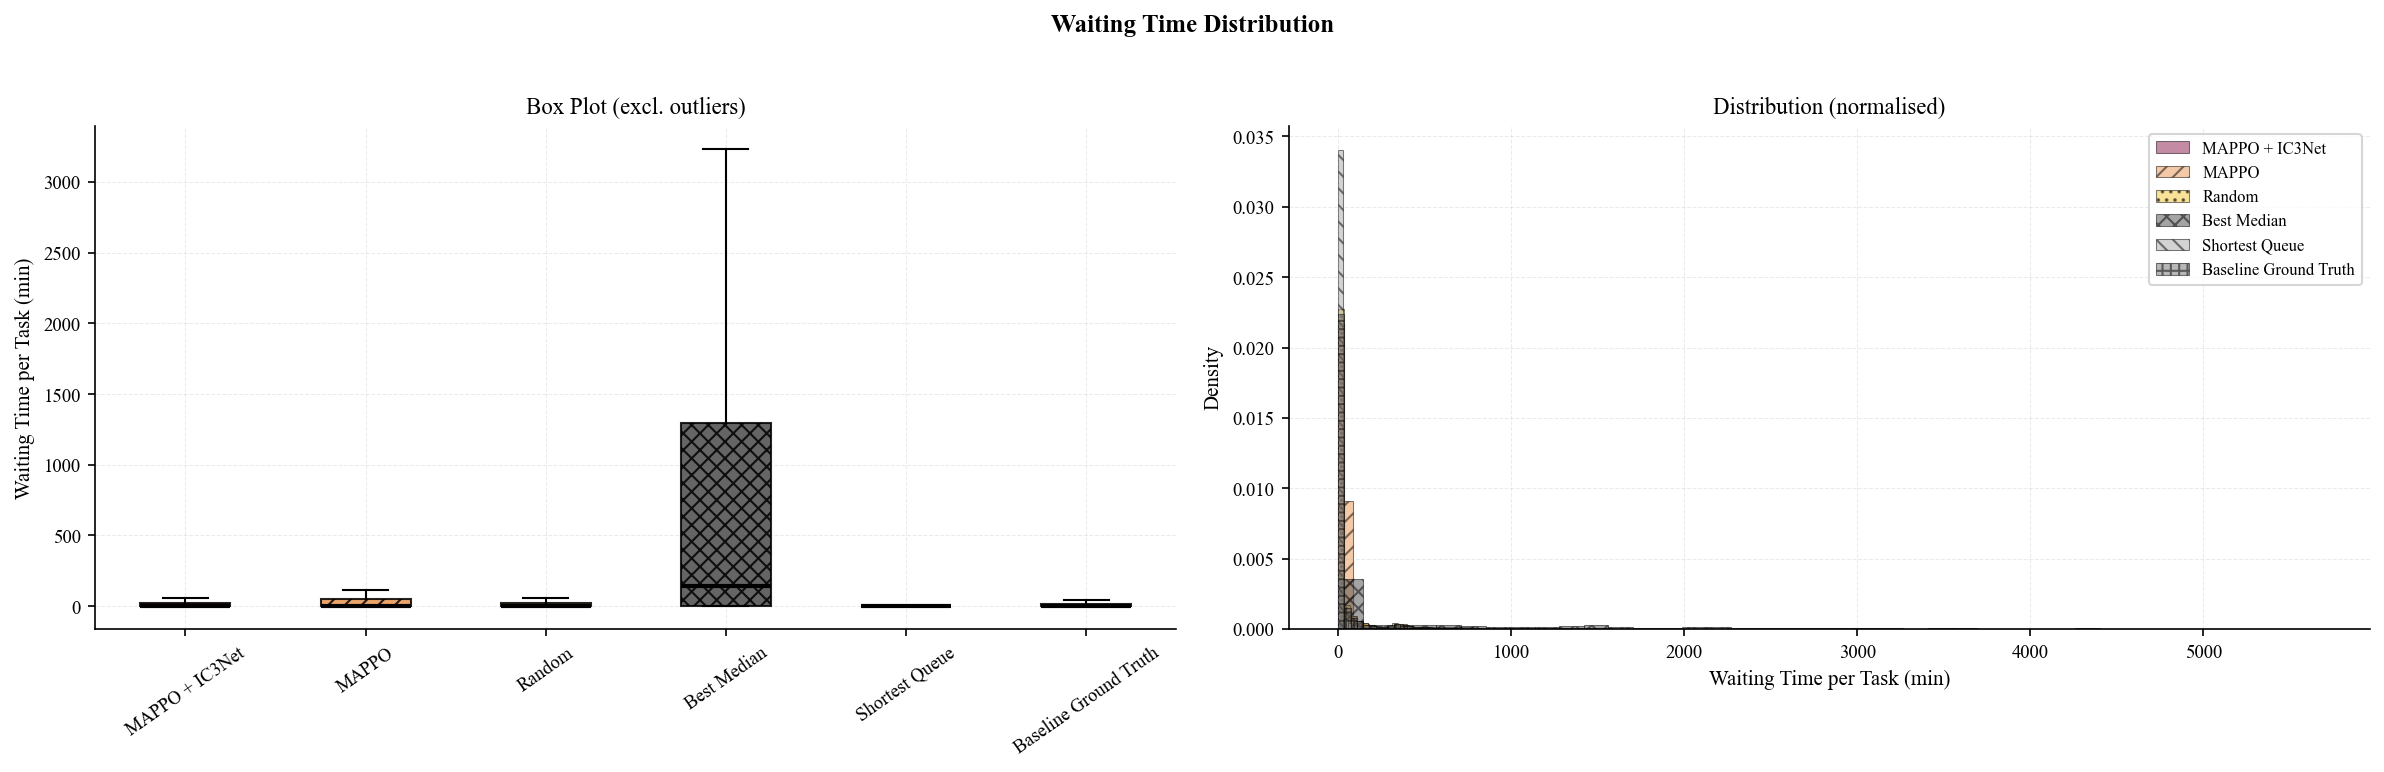

In [54]:
# ============================================================
# FIGURE 1b: Waiting Time Distribution (violin + box, grayscale)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Waiting Time Distribution", fontweight="bold", y=1.02)

# Collect per-task waiting times
method_wait_data = {}
for name, episodes in all_data.items():
    waits = []
    for ep in episodes:
        for _, row in ep.iterrows():
            if pd.notna(row.get("task_assigned_time")) and pd.notna(row.get("task_started_time")):
                wt = max(0, calc_minutes_between(row["task_assigned_time"], row["task_started_time"]))
                waits.append(wt)
    method_wait_data[name] = waits

ordered = list(method_wait_data.keys())
labels = [method_label(n) for n in ordered]
data = [method_wait_data[n] for n in ordered]

# ── Left: Box plot (grayscale) ──
ax = axes[0]
bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(color="black"), capprops=dict(color="black"))
for i, (patch, name) in enumerate(zip(bp["boxes"], ordered)):
    patch.set_facecolor(styles[name]["color"])
    patch.set_edgecolor("black")
    patch.set_hatch(styles[name]["hatch"])
    patch.set_alpha(0.85)
ax.set_ylabel("Waiting Time per Task (min)")
ax.set_title("Box Plot (excl. outliers)")
ax.tick_params(axis="x", rotation=35)

# ── Right: Histogram overlay ──
ax = axes[1]
for name in ordered:
    vals = method_wait_data[name]
    if not vals:
        continue
    s = styles[name]
    ax.hist(vals, bins=40, alpha=0.5, color=s["color"], edgecolor="black",
            linewidth=0.5, label=method_label(name), density=True,
            hatch=s["hatch"])
ax.set_xlabel("Waiting Time per Task (min)")
ax.set_ylabel("Density")
ax.set_title("Distribution (normalised)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("waiting_time_distribution.pdf", bbox_inches="tight")
plt.show()

[Fig 1] avg_cycle_time_min:
    MAPPO + IC3Net      chart='559.5 ± 106.2'  (= Table 1 value)
    MAPPO               chart='1235.7 ± 395.5'  (= Table 1 value)
    Random              chart='539.2 ± 85.3'  (= Table 1 value)
    Best Median         chart='3315.1 ± 491.8'  (= Table 1 value)
    Shortest Queue      chart='321.7 ± 30.2'  (= Table 1 value)
    Baseline Ground Truth  chart='525.1 ± 102.8'  (= Table 1 value)
[Fig 1] avg_waiting_time_min:
    MAPPO + IC3Net      chart='54.5 ± 17.6'  (= Table 1 value)
    MAPPO               chart='176.6 ± 78.4'  (= Table 1 value)
    Random              chart='50.2 ± 12.1'  (= Table 1 value)
    Best Median         chart='739.9 ± 179.8'  (= Table 1 value)
    Shortest Queue      chart='13.8 ± 3.6'  (= Table 1 value)
    Baseline Ground Truth  chart='47.4 ± 15.7'  (= Table 1 value)
[Fig 1] resource_utilization:
    MAPPO + IC3Net      chart='33.4% ± 2.1%'  (= Table 1 value)
    MAPPO               chart='28.1% ± 2.9%'  (= Table 1 value)
    Rand

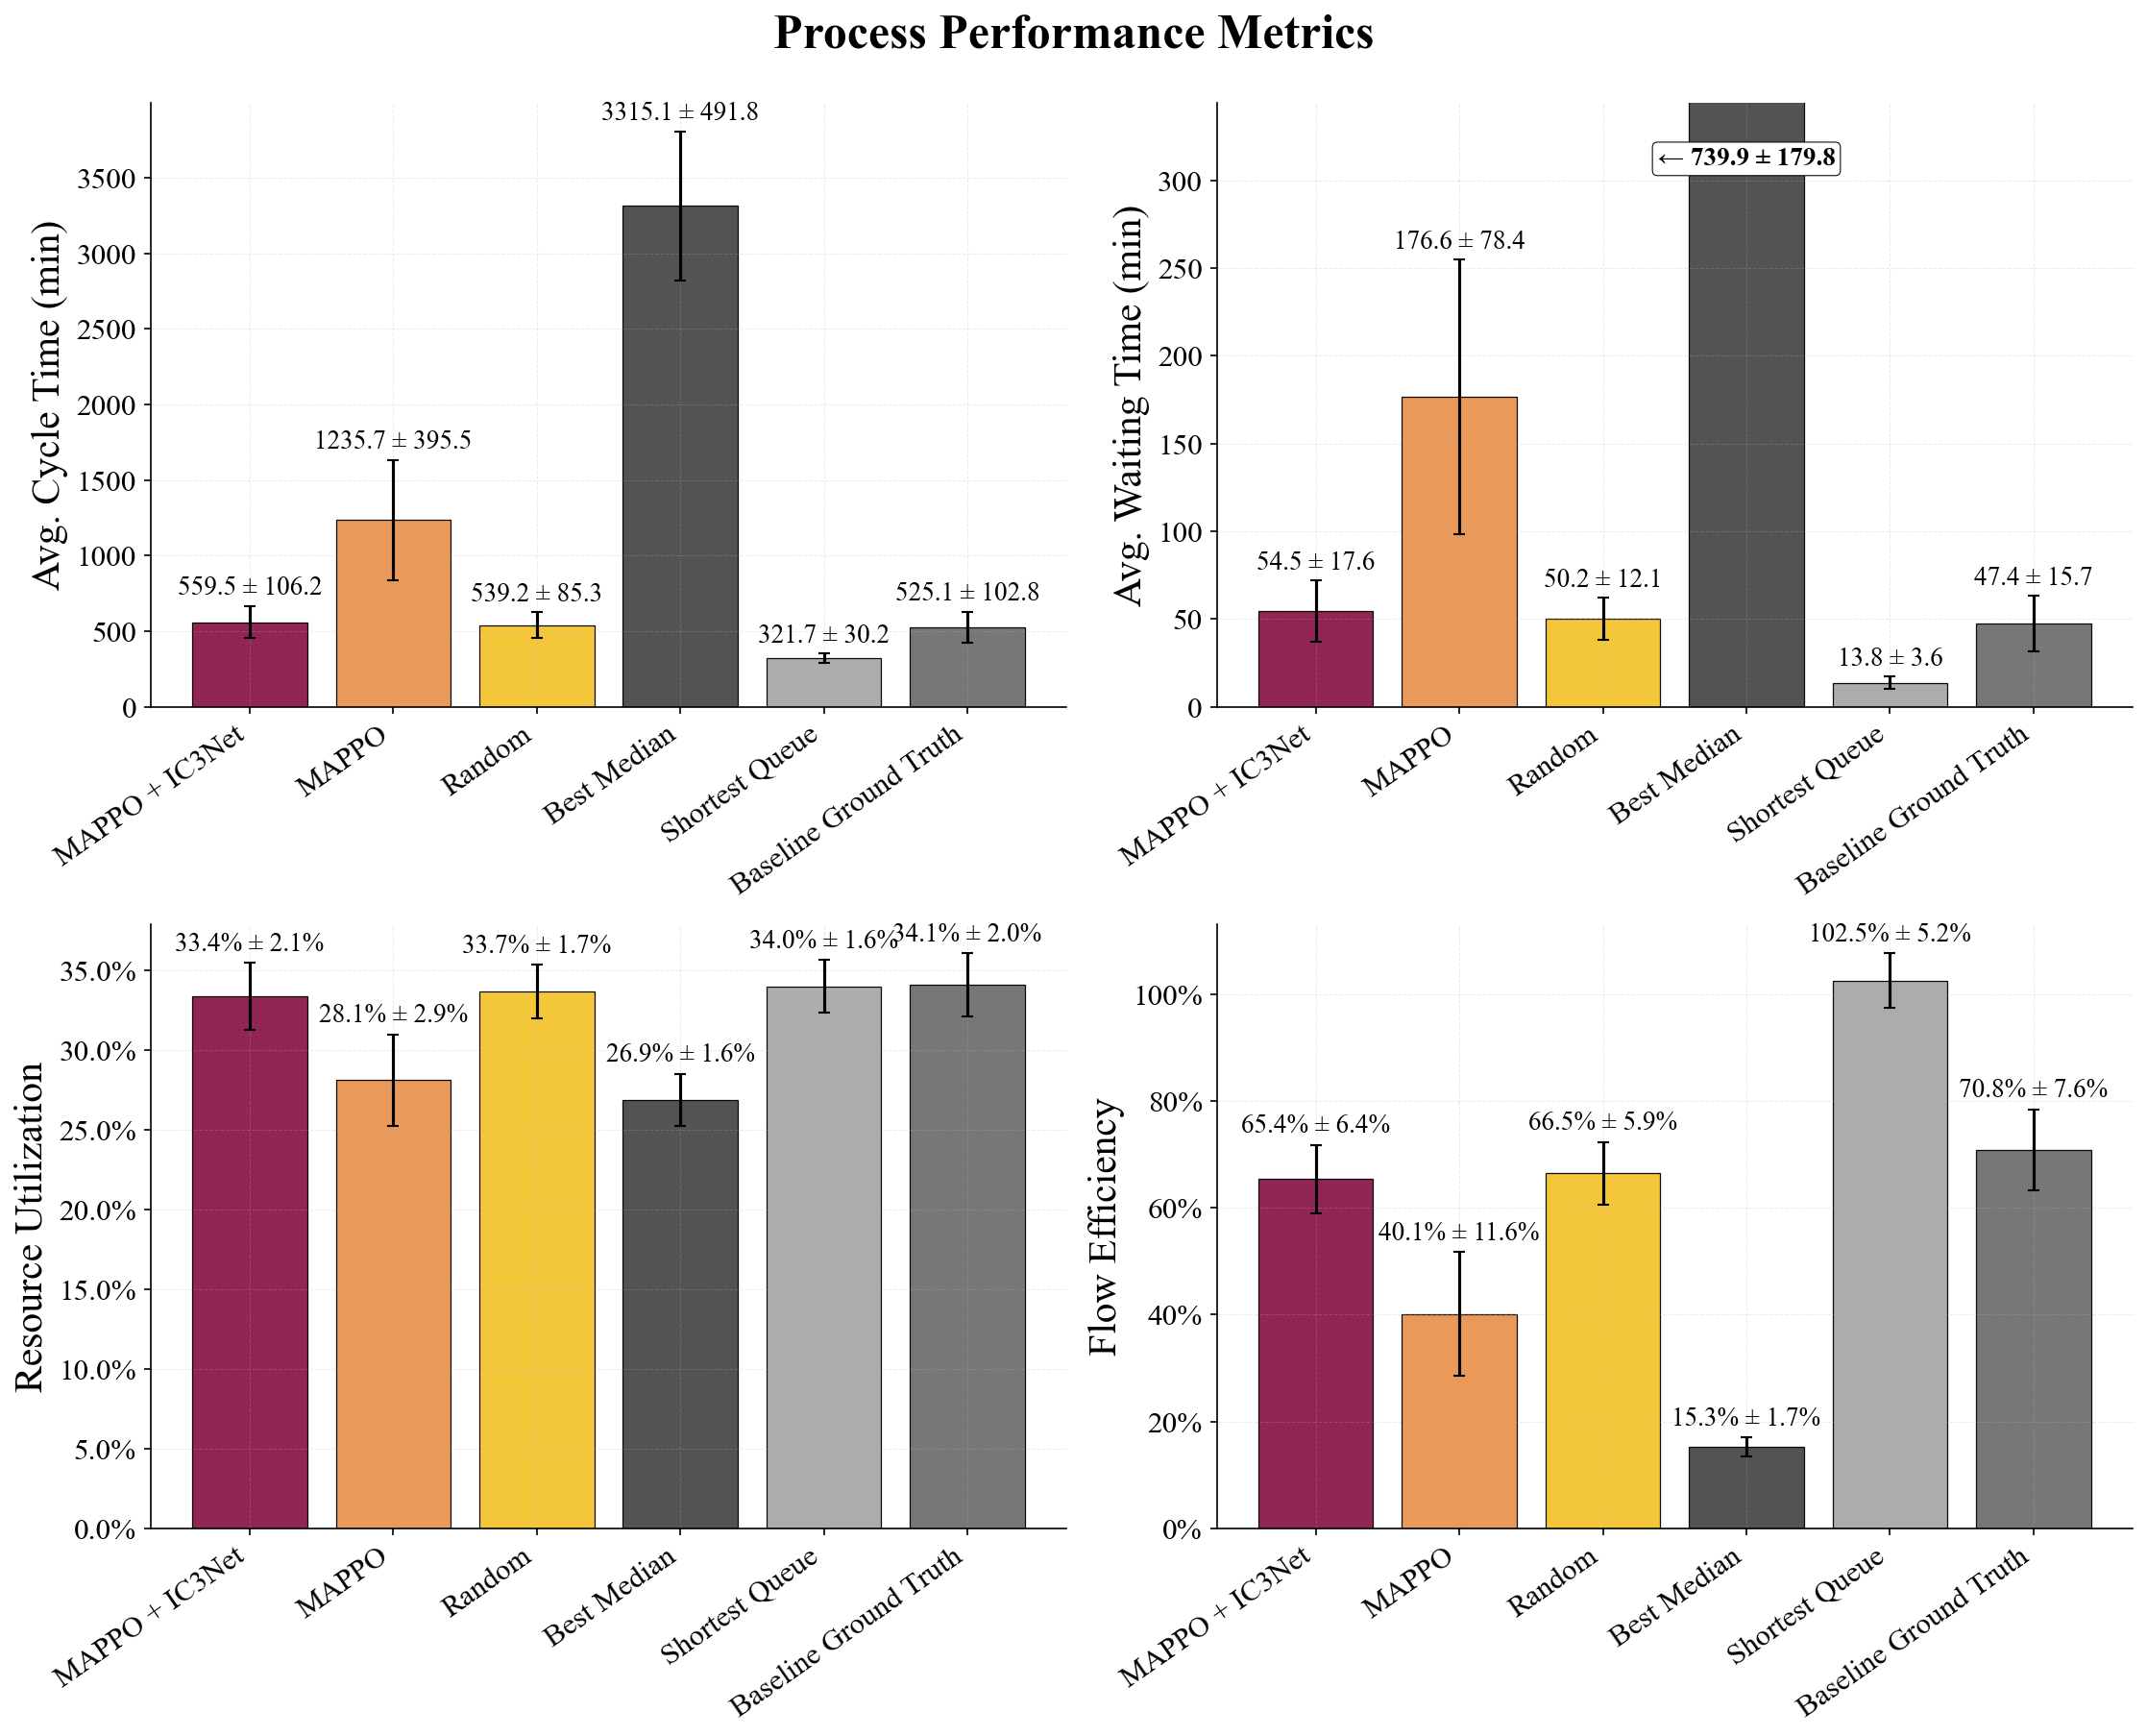

In [55]:
# ============================================================
# FIGURE 1: Process Performance Bar Charts (coloured)
# 2x2 layout. Bar labels show mean ± std in the SAME format as Table 1.
# ============================================================

metric_configs = [
    ("avg_cycle_time_min",    "Avg. Cycle Time (min)",    False),
    ("avg_waiting_time_min",  "Avg. Waiting Time (min)",  False),
    ("resource_utilization",  "Resource Utilization",     True),
    ("flow_efficiency",       "Flow Efficiency",          True),
]

method_names = list(process_metrics.keys())
x = np.arange(len(method_names))

TITLE_FS, AXLABEL_FS, TICK_FS, VALUE_FS, BM_ANNOT_FS = 24, 20, 15, 13, 13

def _fmt_process(m, s, is_ratio):
    """Format EXACTLY like Table 1: percentages use .1%, minutes use .1f."""
    if is_ratio:
        return f"{m:.1%} ± {s:.1%}"
    return f"{m:.1f} ± {s:.1f}"

def _plot_process_bars(zoom=False):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    fig.suptitle("Process Performance Metrics",
                 fontweight="bold", y=1.00, fontsize=TITLE_FS)

    for ax, (metric_key, ylabel, is_ratio) in zip(axes, metric_configs):
        # Collect means & stds in the SAME way Table 1 does
        means, stds = [], []
        for name in method_names:
            vals = [m[metric_key] for m in process_metrics[name]
                    if not np.isnan(m.get(metric_key, np.nan))]
            means.append(float(np.mean(vals)) if vals else 0.0)
            stds.append(float(np.std(vals))  if vals else 0.0)

        bar_colors = [styles[n]["color"] for n in method_names]
        bars = ax.bar(x, means, yerr=stds, capsize=3, color=bar_colors, alpha=0.95,
                      edgecolor="black", linewidth=0.6)
        ax.set_ylabel(ylabel, fontsize=AXLABEL_FS)
        ax.set_xticks(x)
        ax.set_xticklabels([method_label(n) for n in method_names],
                           rotation=35, ha="right", fontsize=TICK_FS)
        ax.tick_params(axis="y", labelsize=TICK_FS)
        if is_ratio:
            ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

        # Detect best-median bar for zoom handling
        bm_idx = [i for i, n in enumerate(method_names) if _is_best_median(n)]
        non_bm_tops = [means[i] + stds[i] for i in range(len(means)) if i not in bm_idx]
        non_bm_max  = max(non_bm_tops) if non_bm_tops else (max(means) if means else 1.0)
        bm_max      = max(means[i] for i in bm_idx) if bm_idx else 0.0
        zoomed      = zoom and bm_idx and bm_max > non_bm_max * 2.5 and not is_ratio
        if zoomed:
            ax.set_ylim(0, non_bm_max * 1.35)

        y_ref = non_bm_max if zoomed else max(means + [1e-9])
        y_off = 0.012 * y_ref

        # Value labels — "mean ± std" in the SAME format as Table 1
        for i_bar, (bar, m, s) in enumerate(zip(bars, means, stds)):
            if i_bar in bm_idx and zoomed:
                continue  # BM off-scale — drawn as arrow annotation
            if m <= 0:
                continue
            ax.text(bar.get_x() + bar.get_width() / 2.0,
                    bar.get_height() + s + y_off,
                    _fmt_process(m, s, is_ratio),
                    ha="center", va="bottom", fontsize=VALUE_FS)

        # Off-scale BM annotation (zoom only)
        if zoomed:
            for bi in bm_idx:
                ax.annotate(f"← {_fmt_process(means[bi], stds[bi], is_ratio)}",
                            xy=(x[bi], non_bm_max * 1.25),
                            fontsize=BM_ANNOT_FS, fontweight="bold",
                            ha="center", va="top",
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                      edgecolor="black", linewidth=0.5))

        # Diagnostic: print BOTH chart label and what the table prints — they
        # must be the character-for-character identical for every row.
        print(f"[Fig 1] {metric_key}:")
        for n, m, s in zip(method_names, means, stds):
            lbl = _fmt_process(m, s, is_ratio)
            print(f"    {method_label(n):18s}  chart='{lbl}'  (= Table 1 value)")

    plt.tight_layout()
    return fig


fig = _plot_process_bars(zoom=True)
plt.savefig("process_performance_zoomed.pdf", bbox_inches="tight")
plt.show()


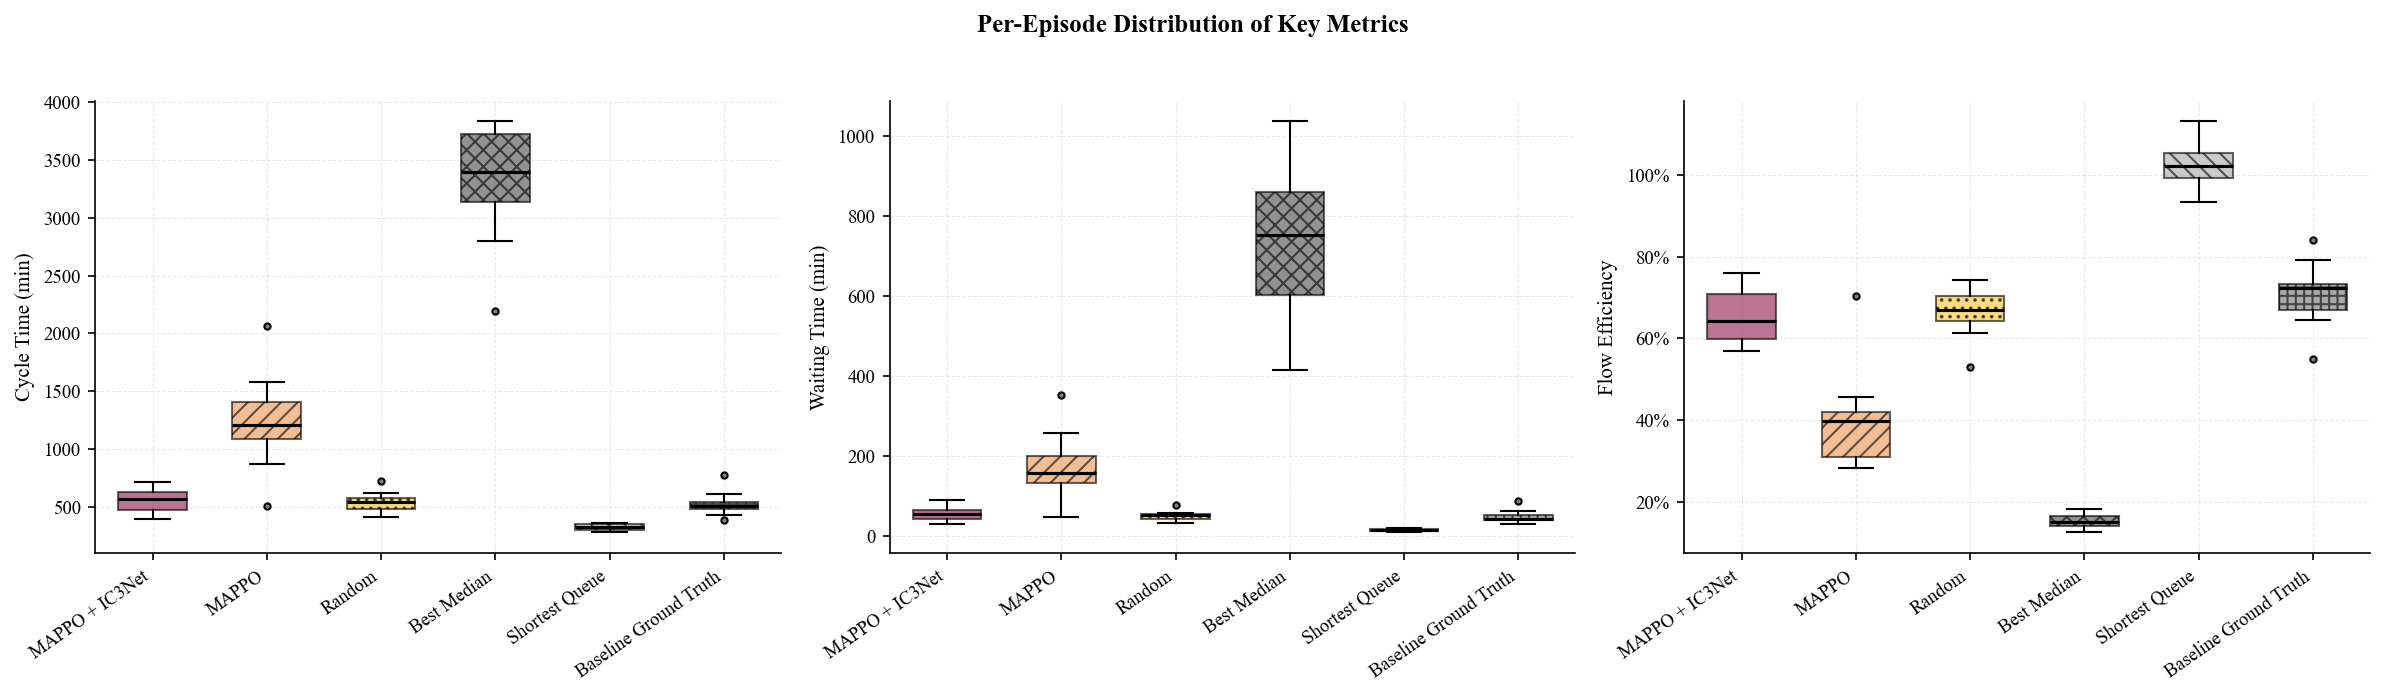

In [56]:
# ============================================================
# FIGURE 2: Per-Episode Breakdown (Box Plots, grayscale)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Per-Episode Distribution of Key Metrics", fontweight="bold", y=1.02)

box_metrics = [
    ("avg_cycle_time_min", "Cycle Time (min)"),
    ("avg_waiting_time_min", "Waiting Time (min)"),
    ("flow_efficiency", "Flow Efficiency"),
]

for ax, (metric_key, ylabel) in zip(axes, box_metrics):
    data_for_box, labels, box_grays = [], [], []
    for name in method_names:
        vals = [m[metric_key] for m in process_metrics[name] if not np.isnan(m.get(metric_key, np.nan))]
        if vals:
            data_for_box.append(vals)
            labels.append(method_label(name))
            box_grays.append(styles[name]["color"])
    bp = ax.boxplot(data_for_box, patch_artist=True, widths=0.6,
                    medianprops={"color": "black", "linewidth": 1.5},
                    flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "gray"})
    for patch, c, name in zip(bp["boxes"], box_grays, [n for n in method_names if any(
            not np.isnan(m.get(metric_key, np.nan)) for m in process_metrics[n])]):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
        patch.set_edgecolor("black")
        patch.set_hatch(styles[name]["hatch"])
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_ylabel(ylabel)
    if "Efficiency" in ylabel:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

plt.tight_layout()
plt.savefig("process_performance_boxplots.pdf", bbox_inches="tight")
plt.show()

-
-
-

#
#
 
5
.
2
.
2
 
L
e
a
r
n
i
n
g
 
E
f
f
i
c
i
e
n
c
y
 
M
e
t
r
i
c
s

In [57]:
# ============================================================
# LOAD TRAINING REWARD CURVES
# ============================================================
reward_curves = {}  # method -> {"train": [...], "eval": [...]}

for entry in sorted(os.listdir(EXPERIMENT_DIR)):
    entry_path = os.path.join(EXPERIMENT_DIR, entry)
    if not os.path.isdir(entry_path) or entry in ("logs", "configs", ".tmp_configs"):
        continue
    result = load_training_summary(entry_path)
    if result:
        reward_curves[entry] = result
        print(f"  {entry}: {len(result['train'])} train, {len(result['eval'])} eval episodes")

if not reward_curves:
    print("  No training summaries found (baselines only?).")

  mappo_parallel: 40 train, 40 eval episodes
  mappo_parallel_comm: 40 train, 40 eval episodes


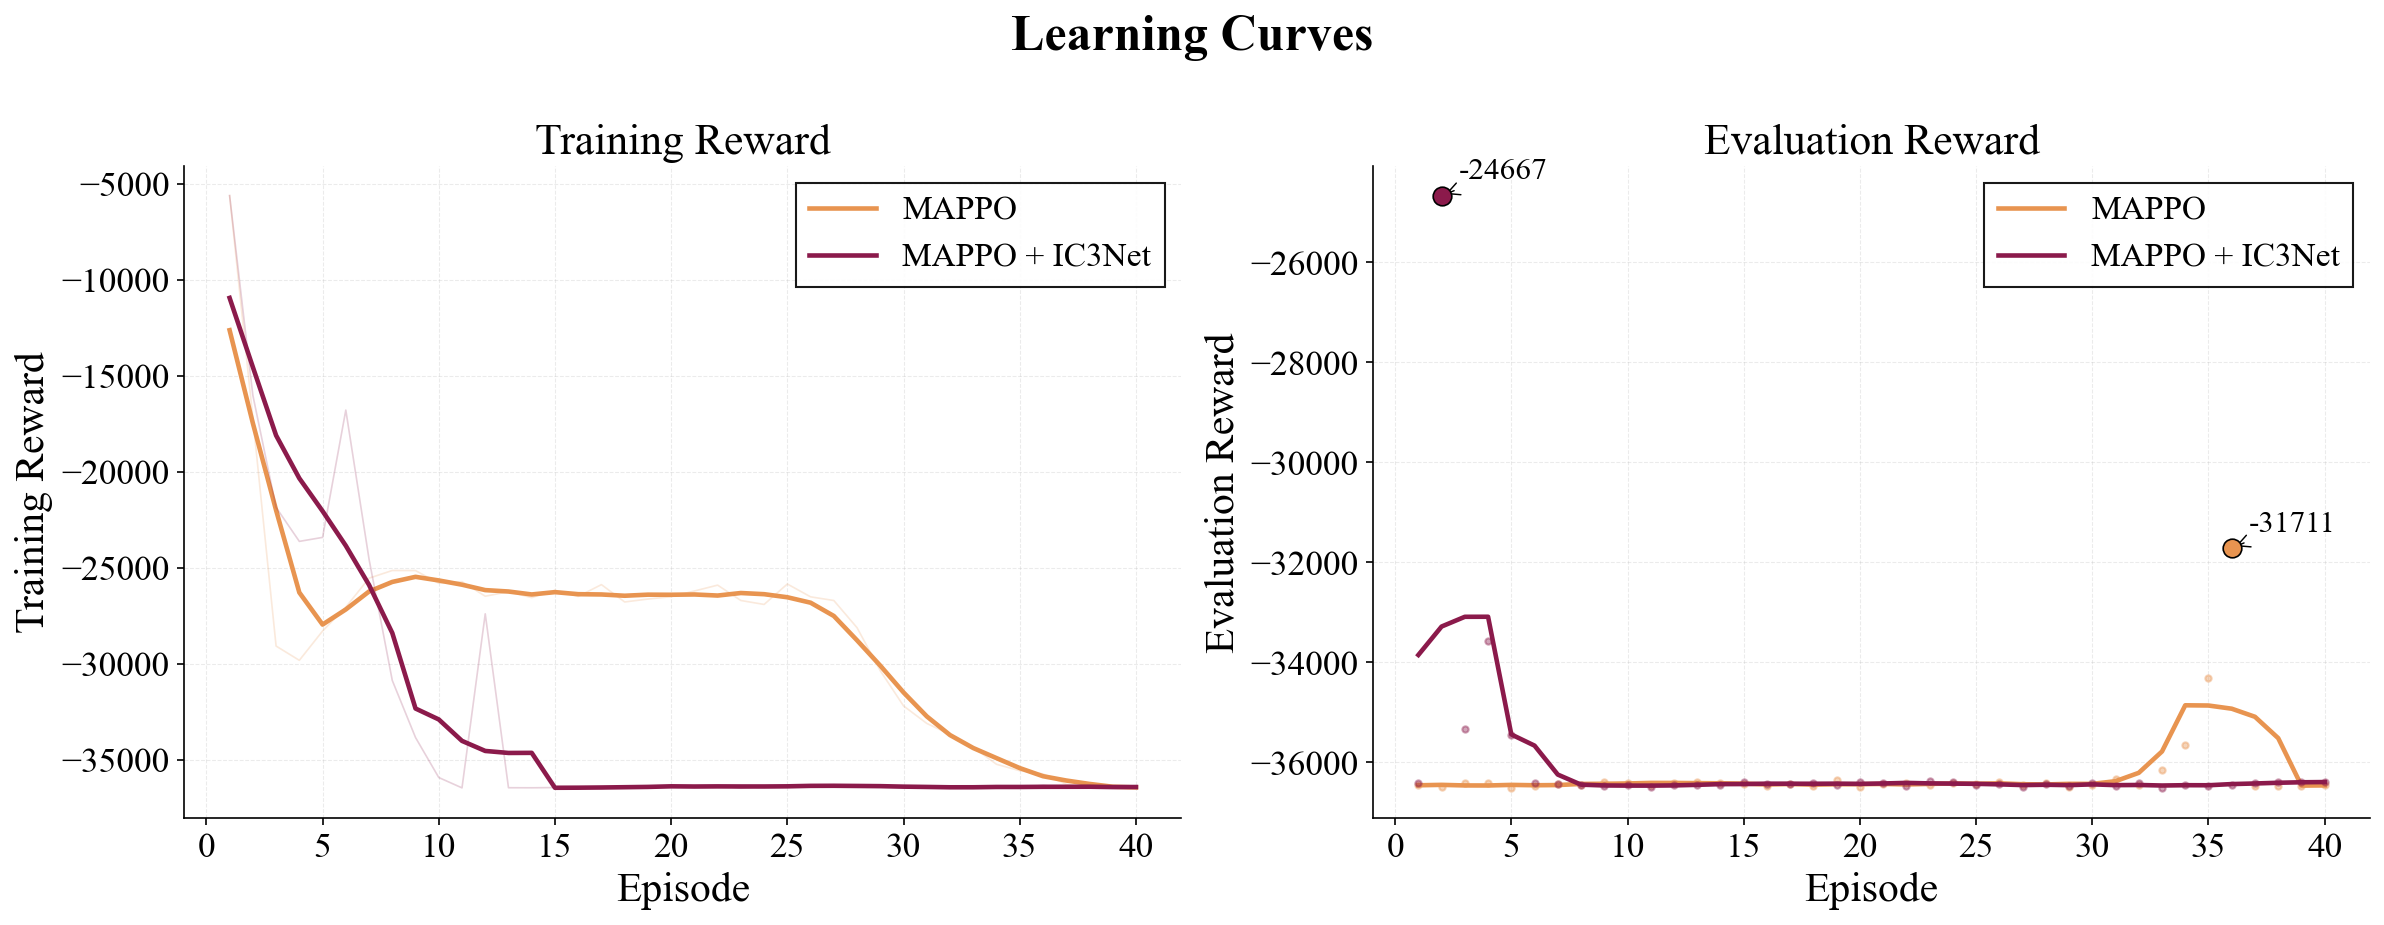

In [58]:
# ============================================================
# FIGURE 3: Learning Curves (grayscale, distinct line styles)
# ============================================================
TITLE_FS, AXLABEL_FS, TICK_FS, LEGEND_FS, ANNOT_FS = 24, 20, 17, 16, 15

if reward_curves:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Learning Curves", fontweight="bold", y=1.02, fontsize=TITLE_FS)
    
    for name, curves in reward_curves.items():
        s = styles.get(name, {"color": "#333"})
        label = method_label(name)
        
        if curves["train"]:
            eps = np.arange(1, len(curves["train"]) + 1)
            ax1.plot(eps, curves["train"], alpha=0.2, color=s["color"], linewidth=0.8)
            ax1.plot(eps, smooth(curves["train"], SMOOTH_WINDOW),
                     color=s["color"], linewidth=2.2, linestyle="-", label=label)
        
        if curves["eval"]:
            eps = np.arange(1, len(curves["eval"]) + 1)
            ax2.plot(eps, curves["eval"], color=s["color"], linewidth=1,
                     marker="o", markersize=3, alpha=0.4, linestyle="none")
            ax2.plot(eps, smooth(curves["eval"], SMOOTH_WINDOW),
                     color=s["color"], linewidth=2.2, linestyle="-", label=label)
            best_idx = np.argmax(curves["eval"])
            ax2.scatter(best_idx + 1, curves["eval"][best_idx], color=s["color"],
                        s=80, zorder=5, edgecolors="black", linewidth=0.8, marker="o")
            ax2.annotate(f"{curves['eval'][best_idx]:.0f}",
                         (best_idx + 1, curves["eval"][best_idx]),
                         textcoords="offset points", xytext=(8, 8), fontsize=ANNOT_FS,
                         arrowprops=dict(arrowstyle="->", color="black", lw=0.7))
    
    for ax, ttl, ylab in [(ax1, "Training Reward", "Training Reward"),
                           (ax2, "Evaluation Reward", "Evaluation Reward")]:
        ax.set_xlabel("Episode", fontsize=AXLABEL_FS)
        ax.set_ylabel(ylab, fontsize=AXLABEL_FS)
        ax.set_title(ttl, fontsize=AXLABEL_FS + 1)
        ax.tick_params(axis="both", labelsize=TICK_FS)
        ax.legend(loc="best", framealpha=0.9, edgecolor="black",
                  fancybox=False, fontsize=LEGEND_FS)
    
    plt.tight_layout()
    plt.savefig("learning_curves.pdf", bbox_inches="tight")
    plt.show()
else:
    print("No training curves to plot.")


In [59]:
# ============================================================
# COMPUTE LEARNING EFFICIENCY METRICS
# ============================================================
learning_metrics = {}

# NumPy 2.0+ renamed np.trapz -> np.trapezoid; fall back for older NumPy
_trapezoid = getattr(np, "trapezoid", None) or np.trapz

for name, curves in reward_curves.items():
    m = {}
    eval_r = np.array(curves["eval"]) if curves["eval"] else np.array([])
    train_r = np.array(curves["train"]) if curves["train"] else np.array([])
    
    # ── Convergence speed ──
    # Episode where rolling CV drops below threshold
    if len(eval_r) >= 4:
        window = min(10, len(eval_r) // 2)
        converged_ep = None
        for i in range(window, len(eval_r)):
            segment = eval_r[i - window:i]
            mean_val = np.mean(segment)
            if mean_val != 0:
                cv = np.std(segment) / abs(mean_val)
                if cv < CONVERGENCE_CV_THRESHOLD:
                    converged_ep = i
                    break
        m["convergence_episode"] = converged_ep if converged_ep else f">{len(eval_r)}"
    else:
        m["convergence_episode"] = "N/A"
    
    # ── Sample efficiency: AUC of eval reward curve (normalized) ──
    if len(eval_r) > 1:
        # Normalize to [0, 1] range for comparability
        r_min, r_max = eval_r.min(), eval_r.max()
        if r_max > r_min:
            normalized = (eval_r - r_min) / (r_max - r_min)
        else:
            normalized = np.ones_like(eval_r)
        m["sample_efficiency_auc"] = _trapezoid(normalized) / len(normalized)
    else:
        m["sample_efficiency_auc"] = np.nan
    
    # ── Training stability: CV of last 25% of eval rewards ──
    if len(eval_r) >= 4:
        tail = eval_r[-(len(eval_r) // 4):]
        tail_mean = np.mean(tail)
        m["stability_cv"] = np.std(tail) / abs(tail_mean) if tail_mean != 0 else np.nan
        m["final_reward_mean"] = tail_mean
        m["final_reward_std"] = np.std(tail)
    else:
        m["stability_cv"] = np.nan
        m["final_reward_mean"] = np.nan
        m["final_reward_std"] = np.nan
    
    # Best eval reward
    m["best_eval_reward"] = float(eval_r.max()) if len(eval_r) > 0 else np.nan
    m["total_episodes"] = len(train_r)
    
    learning_metrics[name] = m

# Display table
if learning_metrics:
    rows = []
    for name, m in learning_metrics.items():
        rows.append({
            "Method": method_label(name),
            "Episodes": m["total_episodes"],
            "Convergence (ep)": m["convergence_episode"],
            "Sample Eff. (AUC)": f"{m['sample_efficiency_auc']:.3f}" if not np.isnan(m.get('sample_efficiency_auc', np.nan)) else "—",
            "Stability (CV)": f"{m['stability_cv']:.3f}" if not np.isnan(m.get('stability_cv', np.nan)) else "—",
            "Final Reward": f"{m['final_reward_mean']:.0f} \u00b1 {m['final_reward_std']:.0f}" if not np.isnan(m.get('final_reward_mean', np.nan)) else "—",
            "Best Reward": f"{m['best_eval_reward']:.0f}" if not np.isnan(m.get('best_eval_reward', np.nan)) else "—",
        })
    print(f"\n{'='*90}")
    print(f"  Table 2: Learning Efficiency Metrics")
    print(f"{'='*90}")
    display(pd.DataFrame(rows).set_index("Method"))
else:
    print("No learning metrics (no trainable methods found).")


  Table 2: Learning Efficiency Metrics


,Episodes,Convergence (ep),Sample Eff. (AUC),Stability (CV),Final Reward,Best Reward
Method,,,,,,
MAPPO,40,10,0.058,0.041,-35650 ± 1460,-31711
MAPPO + IC3Net,40,12,0.042,0.001,-36437 ± 39,-24667


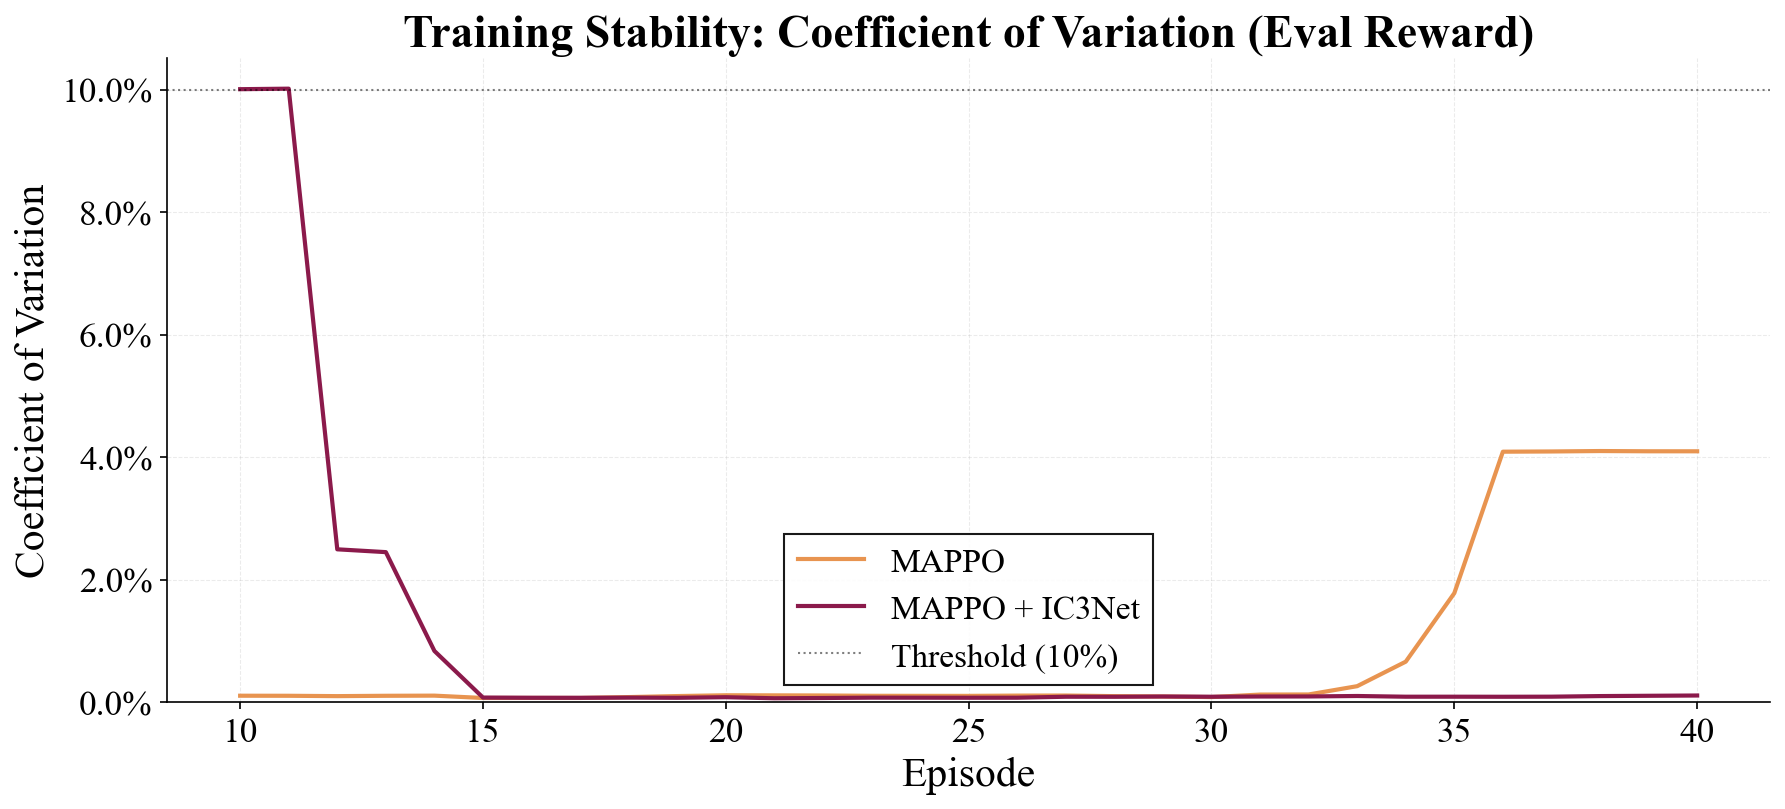

In [60]:
# ============================================================
# FIGURE 4: Training Stability — Coefficient of Variation
# ============================================================
TITLE_FS, AXLABEL_FS, TICK_FS, LEGEND_FS = 22, 20, 17, 16

if reward_curves:
    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.set_title("Training Stability: Coefficient of Variation (Eval Reward)",
                 fontweight="bold", fontsize=TITLE_FS)
    
    for name, curves in reward_curves.items():
        eval_r = np.array(curves["eval"])
        if len(eval_r) < 4:
            continue
        s = styles.get(name, {"color": "#333"})
        window = min(10, len(eval_r) // 2)
        cvs = []
        for i in range(window, len(eval_r) + 1):
            segment = eval_r[i - window:i]
            mean_val = np.mean(segment)
            cv = np.std(segment) / abs(mean_val) if mean_val != 0 else 0
            cvs.append(cv)
        eps = np.arange(window, len(eval_r) + 1)
        ax.plot(eps, cvs, color=s["color"], linewidth=2.0, linestyle="-",
                label=method_label(name))
    
    ax.axhline(y=CONVERGENCE_CV_THRESHOLD, color="black", linestyle=":", alpha=0.5, linewidth=1,
               label=f"Threshold ({CONVERGENCE_CV_THRESHOLD:.0%})")
    ax.set_xlabel("Episode", fontsize=AXLABEL_FS)
    ax.set_ylabel("Coefficient of Variation", fontsize=AXLABEL_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.legend(loc="best", framealpha=0.9, edgecolor="black",
              fancybox=False, fontsize=LEGEND_FS)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.savefig("training_stability.pdf", bbox_inches="tight")
    plt.show()


-
-
-

#
#
 
5
.
2
.
3
 
O
p
e
r
a
t
i
o
n
a
l
 
B
e
h
a
v
i
o
u
r
 
M
e
t
r
i
c
s

In [61]:
# ============================================================
# COMPUTE OPERATIONAL BEHAVIOUR METRICS PER EPISODE
# ============================================================
def compute_operational_metrics(df, overload_threshold=5):
    """Compute operational behaviour metrics for a single episode.
    
    Returns dict with:
      - avg_queue_length: average tasks waiting per agent at assignment time
      - overload_ratio: fraction of agents exceeding queue threshold
      - workload_fairness_cv: coefficient of variation of per-agent task counts
      - volunteer_ratio: fraction of volunteer vs fallback assignments
      - avg_volunteers_per_task: mean number of volunteers per task
      - fallback_ratio: fraction of fallback assignments
    """
    metrics = {}
    
    # ── Queue length approximation ──
    # Count concurrent pending tasks per agent at each assignment time
    if "task_agent_id" in df.columns and len(df) > 0:
        agents = df["task_agent_id"].unique()
        agent_task_counts = df.groupby("task_agent_id").size()
        
        # Simulate queue: for each task assignment, count how many other tasks
        # assigned to that agent are still in progress
        queue_lengths = []
        df_sorted = df.sort_values("task_assigned_time").copy()
        for agent_id in agents:
            agent_tasks = df_sorted[df_sorted["task_agent_id"] == agent_id].copy()
            for idx, row in agent_tasks.iterrows():
                assigned = row["task_assigned_time"]
                if pd.isna(assigned):
                    continue
                # Count tasks assigned to this agent before this one that haven't completed yet
                pending = ((agent_tasks["task_assigned_time"] < assigned) &
                           (agent_tasks["task_completed_time"] > assigned)).sum()
                queue_lengths.append(pending)
        
        metrics["avg_queue_length"] = np.mean(queue_lengths) if queue_lengths else 0
        metrics["max_queue_length"] = max(queue_lengths) if queue_lengths else 0
        
        # ── Overload ratio ──
        overloaded = sum(1 for q in queue_lengths if q >= overload_threshold)
        metrics["overload_ratio"] = overloaded / len(queue_lengths) if queue_lengths else 0
        
        # ── Workload fairness (CV of per-agent task counts) ──
        counts = agent_task_counts.values
        mean_count = np.mean(counts)
        metrics["workload_fairness_cv"] = np.std(counts) / mean_count if mean_count > 0 else 0
        metrics["workload_std"] = np.std(counts)
        metrics["workload_min"] = int(np.min(counts))
        metrics["workload_max"] = int(np.max(counts))
    else:
        metrics["avg_queue_length"] = np.nan
        metrics["max_queue_length"] = np.nan
        metrics["overload_ratio"] = np.nan
        metrics["workload_fairness_cv"] = np.nan
        metrics["workload_std"] = np.nan
        metrics["workload_min"] = np.nan
        metrics["workload_max"] = np.nan
    
    # ── Volunteer / fallback analysis ──
    if "task_assignment_type" in df.columns:
        total = len(df)
        volunteer_mask = df["task_assignment_type"].str.contains("volunteer", case=False, na=False)
        fallback_mask = df["task_assignment_type"].str.contains("fallback", case=False, na=False)
        
        metrics["volunteer_ratio"] = volunteer_mask.sum() / total if total > 0 else 0
        metrics["fallback_ratio"] = fallback_mask.sum() / total if total > 0 else 0
        
        # Average number of volunteers per task
        if "task_volunteers" in df.columns:
            vol_counts = []
            for v in df["task_volunteers"].dropna():
                v_str = str(v).strip()
                if v_str and v_str != "nan":
                    vol_counts.append(len(v_str.split("|")))
                else:
                    vol_counts.append(0)
            metrics["avg_volunteers_per_task"] = np.mean(vol_counts) if vol_counts else 0
        else:
            metrics["avg_volunteers_per_task"] = np.nan
    else:
        metrics["volunteer_ratio"] = np.nan
        metrics["fallback_ratio"] = np.nan
        metrics["avg_volunteers_per_task"] = np.nan
    
    return metrics

# Compute for all methods
operational_metrics = {}
for name, episodes in all_data.items():
    ep_metrics = [compute_operational_metrics(ep, OVERLOAD_THRESHOLD) for ep in episodes]
    operational_metrics[name] = ep_metrics

print("Operational behaviour metrics computed.")

Operational behaviour metrics computed.


In [62]:
# ============================================================
# TABLE 3: Operational Behaviour Summary
# ============================================================
rows = []
for name, ep_metrics in operational_metrics.items():
    def agg(key):
        vals = [m[key] for m in ep_metrics if not np.isnan(m.get(key, np.nan))]
        return (np.mean(vals), np.std(vals)) if vals else (np.nan, np.nan)
    
    ql_m, ql_s = agg("avg_queue_length")
    ol_m, ol_s = agg("overload_ratio")
    wf_m, wf_s = agg("workload_fairness_cv")
    vr_m, vr_s = agg("volunteer_ratio")
    fr_m, fr_s = agg("fallback_ratio")
    av_m, av_s = agg("avg_volunteers_per_task")
    
    def fmt(m, s, pct=False):
        if np.isnan(m): return "—"
        if pct: return f"{m:.1%} \u00b1 {s:.1%}"
        return f"{m:.2f} \u00b1 {s:.2f}"
    
    rows.append({
        "Method": method_label(name),
        "Avg Queue Length": fmt(ql_m, ql_s),
        f"Overload Ratio (>{OVERLOAD_THRESHOLD})": fmt(ol_m, ol_s, pct=True),
        "Workload Fairness (CV)": fmt(wf_m, wf_s),
        "Volunteer Ratio": fmt(vr_m, vr_s, pct=True),
        "Fallback Ratio": fmt(fr_m, fr_s, pct=True),
        "Avg Volunteers/Task": fmt(av_m, av_s),
    })

print(f"\n{'='*90}")
print(f"  Table 3: Operational Behaviour Metrics")
print(f"{'='*90}")
display(pd.DataFrame(rows).set_index("Method"))


  Table 3: Operational Behaviour Metrics


,Avg Queue Length,Overload Ratio (>5),Workload Fairness (CV),Volunteer Ratio,Fallback Ratio,Avg Volunteers/Task
Method,,,,,,
MAPPO + IC3Net,0.85 ± 0.21,4.3% ± 2.4%,0.26 ± 0.01,0.0% ± 0.0%,100.0% ± 0.0%,0.00 ± 0.00
MAPPO,2.86 ± 1.24,12.9% ± 5.1%,0.38 ± 0.07,10.1% ± 4.8%,89.9% ± 4.8%,1.00 ± 0.00
Random,0.80 ± 0.15,3.5% ± 1.5%,0.26 ± 0.01,89.1% ± 0.6%,10.9% ± 0.6%,2.80 ± 0.04
Best Median,12.31 ± 2.46,47.0% ± 3.9%,0.91 ± 0.01,100.0% ± 0.0%,0.0% ± 0.0%,1.00 ± 0.00
Shortest Queue,0.17 ± 0.03,0.1% ± 0.2%,0.25 ± 0.01,100.0% ± 0.0%,0.0% ± 0.0%,1.00 ± 0.00
Baseline Ground Truth,0.70 ± 0.18,3.0% ± 1.9%,0.23 ± 0.00,0.0% ± 0.0%,0.0% ± 0.0%,1.00 ± 0.00


[Fig 5] avg_queue_length:
    MAPPO + IC3Net      chart='0.85 ± 0.21'  (= Table 3 value)
    MAPPO               chart='2.86 ± 1.24'  (= Table 3 value)
    Random              chart='0.80 ± 0.15'  (= Table 3 value)
    Best Median         chart='12.31 ± 2.46'  (= Table 3 value)
    Shortest Queue      chart='0.17 ± 0.03'  (= Table 3 value)
    Baseline Ground Truth  chart='0.70 ± 0.18'  (= Table 3 value)
[Fig 5] overload_ratio:
    MAPPO + IC3Net      chart='4.3% ± 2.4%'  (= Table 3 value)
    MAPPO               chart='12.9% ± 5.1%'  (= Table 3 value)
    Random              chart='3.5% ± 1.5%'  (= Table 3 value)
    Best Median         chart='47.0% ± 3.9%'  (= Table 3 value)
    Shortest Queue      chart='0.1% ± 0.2%'  (= Table 3 value)
    Baseline Ground Truth  chart='3.0% ± 1.9%'  (= Table 3 value)
[Fig 5] workload_fairness_cv:
    MAPPO + IC3Net      chart='0.26 ± 0.01'  (= Table 3 value)
    MAPPO               chart='0.38 ± 0.07'  (= Table 3 value)
    Random              chart

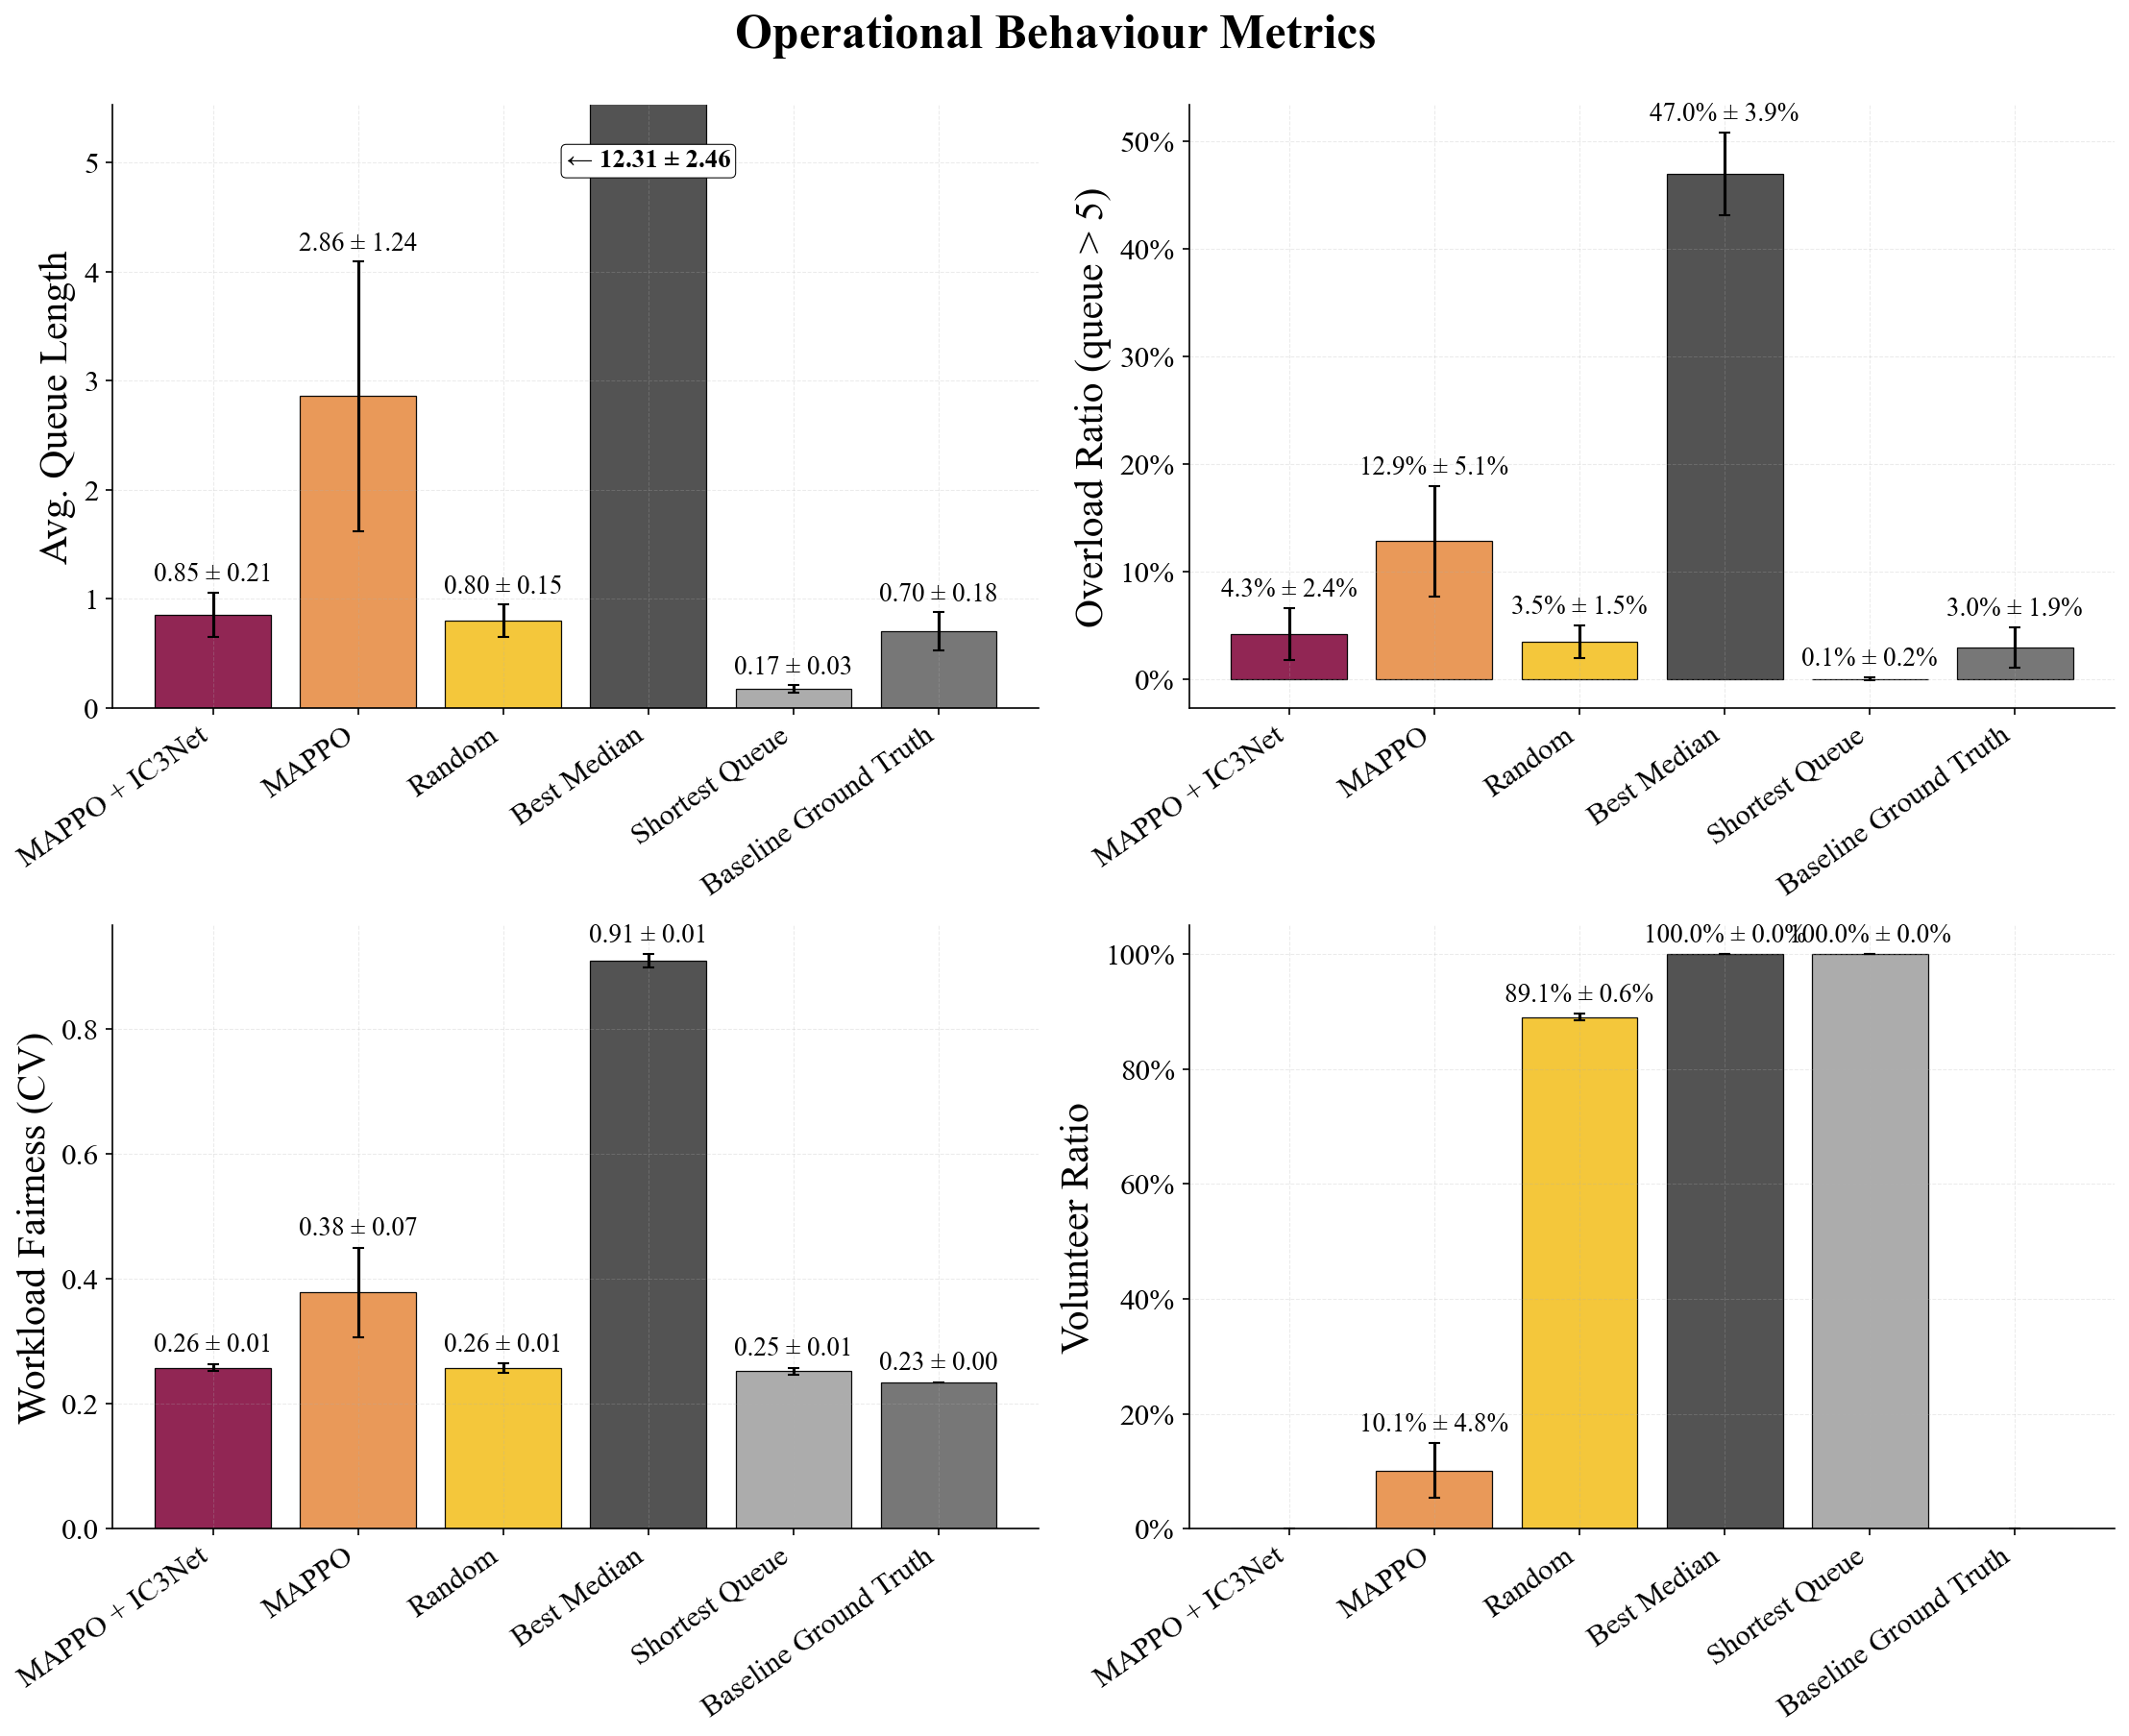

In [63]:
# ============================================================
# FIGURE 5: Operational Behaviour Bar Charts (coloured)
# 2x2 layout. Bar labels show mean ± std in the SAME format as Table 3.
# ============================================================

op_configs = [
    ("avg_queue_length",       "Avg. Queue Length",                                        False),
    ("overload_ratio",         f"Overload Ratio (queue > {OVERLOAD_THRESHOLD})",          True),
    ("workload_fairness_cv",   "Workload Fairness (CV)",                                   False),
    ("volunteer_ratio",        "Volunteer Ratio",                                          True),
]

TITLE_FS, AXLABEL_FS, TICK_FS, VALUE_FS, BM_ANNOT_FS = 24, 20, 15, 13, 13

def _fmt_op(m, s, is_pct):
    """Format EXACTLY like Table 3: percentages use .1%, numbers use .2f."""
    if is_pct:
        return f"{m:.1%} ± {s:.1%}"
    return f"{m:.2f} ± {s:.2f}"

def _plot_operational_bars(zoom=False):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    fig.suptitle("Operational Behaviour Metrics",
                 fontweight="bold", y=1.00, fontsize=TITLE_FS)

    for ax, (metric_key, ylabel, is_pct) in zip(axes, op_configs):
        means, stds = [], []
        for name in method_names:
            vals = [m[metric_key] for m in operational_metrics[name]
                    if not np.isnan(m.get(metric_key, np.nan))]
            means.append(float(np.mean(vals)) if vals else 0.0)
            stds.append(float(np.std(vals))  if vals else 0.0)

        bar_colors = [styles[n]["color"] for n in method_names]
        bars = ax.bar(x, means, yerr=stds, capsize=3, color=bar_colors, alpha=0.95,
                      edgecolor="black", linewidth=0.6)
        ax.set_ylabel(ylabel, fontsize=AXLABEL_FS)
        ax.set_xticks(x)
        ax.set_xticklabels([method_label(n) for n in method_names],
                           rotation=35, ha="right", fontsize=TICK_FS)
        ax.tick_params(axis="y", labelsize=TICK_FS)
        if is_pct:
            ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

        bm_idx = [i for i, n in enumerate(method_names) if _is_best_median(n)]
        non_bm_tops = [means[i] + stds[i] for i in range(len(means)) if i not in bm_idx]
        non_bm_max  = max(non_bm_tops) if non_bm_tops else (max(means) if means else 1.0)
        bm_max      = max(means[i] for i in bm_idx) if bm_idx else 0.0
        zoomed      = zoom and bm_idx and bm_max > non_bm_max * 2.5 and not is_pct
        if zoomed:
            ax.set_ylim(0, non_bm_max * 1.35)

        y_ref = non_bm_max if zoomed else max(means + [1e-9])
        y_off = 0.012 * y_ref
        for i_bar, (bar, m, s) in enumerate(zip(bars, means, stds)):
            if i_bar in bm_idx and zoomed:
                continue
            if m <= 0:
                continue
            ax.text(bar.get_x() + bar.get_width() / 2.0,
                    bar.get_height() + s + y_off,
                    _fmt_op(m, s, is_pct),
                    ha="center", va="bottom", fontsize=VALUE_FS)

        if zoomed:
            for bi in bm_idx:
                ax.annotate(f"← {_fmt_op(means[bi], stds[bi], is_pct)}",
                            xy=(x[bi], non_bm_max * 1.25),
                            fontsize=BM_ANNOT_FS, fontweight="bold",
                            ha="center", va="top",
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                      edgecolor="black", linewidth=0.5))

        print(f"[Fig 5] {metric_key}:")
        for n, m, s in zip(method_names, means, stds):
            lbl = _fmt_op(m, s, is_pct)
            print(f"    {method_label(n):18s}  chart='{lbl}'  (= Table 3 value)")

    plt.tight_layout()
    return fig


fig = _plot_operational_bars(zoom=True)
plt.savefig("operational_behaviour_zoomed.pdf", bbox_inches="tight")
plt.show()


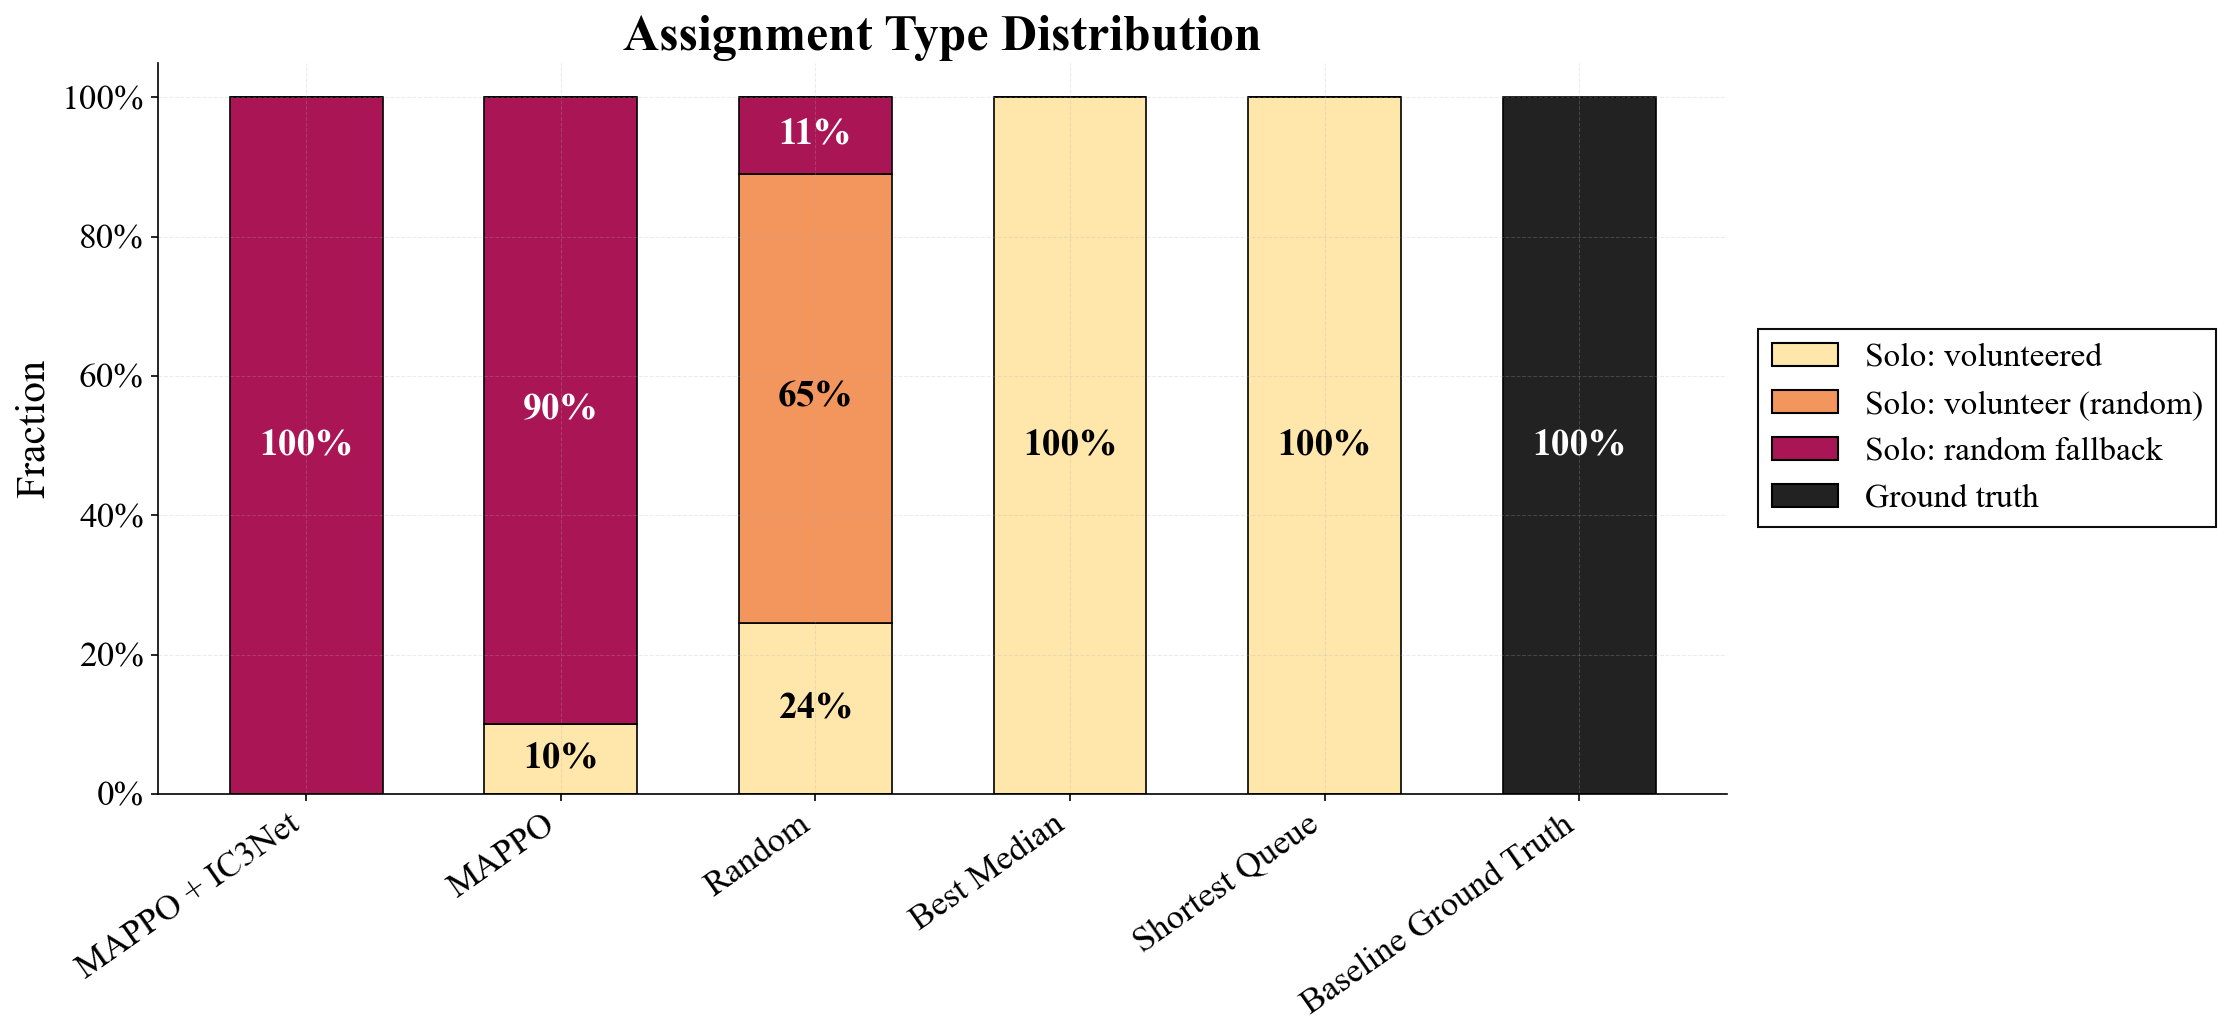

In [64]:
# ============================================================
# FIGURE 6: Assignment Type Distribution (Stacked Bar, coloured)
# ============================================================
TITLE_FS, AXLABEL_FS, TICK_FS, LEGEND_FS, BAR_PCT_FS = 24, 20, 17, 16, 18

fig, ax = plt.subplots(figsize=(15, 7))
ax.set_title("Assignment Type Distribution", fontweight="bold", fontsize=TITLE_FS)

# Collect assignment type fractions per method
assignment_data = {}
all_types = set()
for name, episodes in all_data.items():
    type_counts = defaultdict(int)
    total = 0
    for ep in episodes:
        if "task_assignment_type" in ep.columns:
            for t in ep["task_assignment_type"].dropna():
                type_counts[t] += 1
                total += 1
                all_types.add(t)
    if total > 0:
        assignment_data[name] = {t: c / total for t, c in type_counts.items()}

if assignment_data:
    # High-contrast palette — stays in the yellow / orange / pink family
    # but spreads values wide enough that every segment is distinct.
    _type_config = {
        "solo_volunteer":                  {"label": "Solo: volunteered",           "color": "#FFE6AB"},
        "solo_volunteer_random":           {"label": "Solo: volunteer (random)",    "color": "#F3965E"},
        "solo_fallback_random":            {"label": "Solo: random fallback",       "color": "#AA1555"},
        "collab_volunteer":                {"label": "Collab: exact match",         "color": "#24A793"},
        "collab_volunteer_all_random":     {"label": "Collab: volunteer (random)",  "color": "#5287C6"},
        "collab_volunteer_partial_random": {"label": "Collab: partial fill",        "color": "#5B2182"},
        "collab_fallback_random":          {"label": "Collab: full random fallback","color": "#FFCD00"},
    }
    _fallback_palette = ["#4A4A4A", "#9E9E9E", "#222222"]

    type_styles = {}
    for t in _type_config:
        if t in all_types:
            type_styles[t] = _type_config[t]
    for t in sorted(all_types):
        if t not in type_styles:
            fi = len(type_styles) - len(_type_config)
            type_styles[t] = {
                "label": t.replace("_", " ").capitalize(),
                "color": _fallback_palette[fi % len(_fallback_palette)],
            }

    ordered_types = list(type_styles.keys())
    bar_width = 0.6
    method_list = list(assignment_data.keys())
    x_pos = np.arange(len(method_list))

    bottoms = np.zeros(len(method_list))
    for atype in ordered_types:
        ts = type_styles[atype]
        vals = [assignment_data[m].get(atype, 0) for m in method_list]
        ax.bar(x_pos, vals, bar_width, bottom=bottoms,
               color=ts["color"], alpha=1.0, edgecolor="black", linewidth=0.8)

        # Big, bold percentage labels inside each segment (≥ 2%).
        for xi, (v, b) in enumerate(zip(vals, bottoms)):
            if v < 0.02:
                continue
            mid_y = b + v / 2
            # Luminance-based contrast picker
            hexc = ts["color"].lstrip("#")
            r, g, bl = int(hexc[0:2], 16), int(hexc[2:4], 16), int(hexc[4:6], 16)
            lum = (0.299 * r + 0.587 * g + 0.114 * bl) / 255
            text_color = "black" if lum > 0.55 else "white"
            ax.text(x_pos[xi], mid_y, f"{v:.0%}",
                    ha="center", va="center",
                    fontsize=BAR_PCT_FS, fontweight="bold",
                    color=text_color)

        bottoms += vals

    ax.set_xticks(x_pos)
    ax.set_xticklabels([method_label(m) for m in method_list],
                       rotation=35, ha="right", fontsize=TICK_FS)
    ax.tick_params(axis="y", labelsize=TICK_FS)
    ax.set_ylabel("Fraction", fontsize=AXLABEL_FS)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.set_ylim(0, 1.05)

    # Legend: plain colour patches, outside the plot on the right
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor=type_styles[t]["color"], edgecolor="black",
              label=type_styles[t]["label"])
        for t in ordered_types
    ]
    ax.legend(handles=legend_handles,
              loc="center left", bbox_to_anchor=(1.02, 0.5),
              fontsize=LEGEND_FS, ncol=1,
              framealpha=0.95, edgecolor="black", fancybox=False,
              borderaxespad=0.)

    plt.tight_layout()
    plt.savefig("assignment_distribution.pdf", bbox_inches="tight")
    plt.show()
else:
    print("No assignment type data available.")


In [65]:
# ============================================================
# TABLE: Assignment Type Distribution (counts & percentages)
# ============================================================

if assignment_data:
    sorted_types = sorted(all_types)
    method_list = list(assignment_data.keys())
    
    assignment_counts = {}
    assignment_totals = {}
    for name, episodes in all_data.items():
        type_counts = defaultdict(int)
        total = 0
        for ep in episodes:
            if "task_assignment_type" in ep.columns:
                for t in ep["task_assignment_type"].dropna():
                    type_counts[t] += 1
                    total += 1
        assignment_counts[name] = dict(type_counts)
        assignment_totals[name] = total
    
    _type_labels = {
        "solo_volunteer": "Volunteered",
        "solo_volunteer_random": "Vol. (random tie-break)",
        "solo_fallback_random": "Fallback (timeout)",
        "collab_volunteer": "Collab: exact match",
        "collab_volunteer_all_random": "Collab: all random",
        "collab_volunteer_partial_random": "Collab: partial random",
        "collab_fallback_random": "Collab: fallback",
    }
    
    rows = []
    for atype in sorted_types:
        row = {"Assignment Type": _type_labels.get(atype, atype.replace("_", " ").title())}
        for name in method_list:
            count = assignment_counts.get(name, {}).get(atype, 0)
            frac = assignment_data[name].get(atype, 0)
            row[method_label(name)] = f"{count:,}  ({frac:.1%})"
        rows.append(row)
    
    total_row = {"Assignment Type": "TOTAL"}
    for name in method_list:
        total_row[method_label(name)] = f"{assignment_totals.get(name, 0):,}  (100%)"
    rows.append(total_row)
    
    print(f"\n{'='*90}")
    print(f"  Assignment Type Distribution")
    print(f"{'='*90}")
    df_assign = pd.DataFrame(rows).set_index("Assignment Type")
    display(df_assign)
else:
    print("No assignment type data available.")


  Assignment Type Distribution


,MAPPO + IC3Net,MAPPO,Random,Best Median,Shortest Queue,Baseline Ground Truth
Assignment Type,,,,,,
Ground Truth,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),"13,740 (100.0%)"
Fallback (timeout),"13,740 (100.0%)","12,355 (89.9%)","1,504 (10.9%)",0 (0.0%),0 (0.0%),0 (0.0%)
Volunteered,0 (0.0%),"1,385 (10.1%)","3,366 (24.5%)","13,740 (100.0%)","13,740 (100.0%)",0 (0.0%)
Vol. (random tie-break),0 (0.0%),0 (0.0%),"8,870 (64.6%)",0 (0.0%),0 (0.0%),0 (0.0%)
TOTAL,"13,740 (100%)","13,740 (100%)","13,740 (100%)","13,740 (100%)","13,740 (100%)","13,740 (100%)"


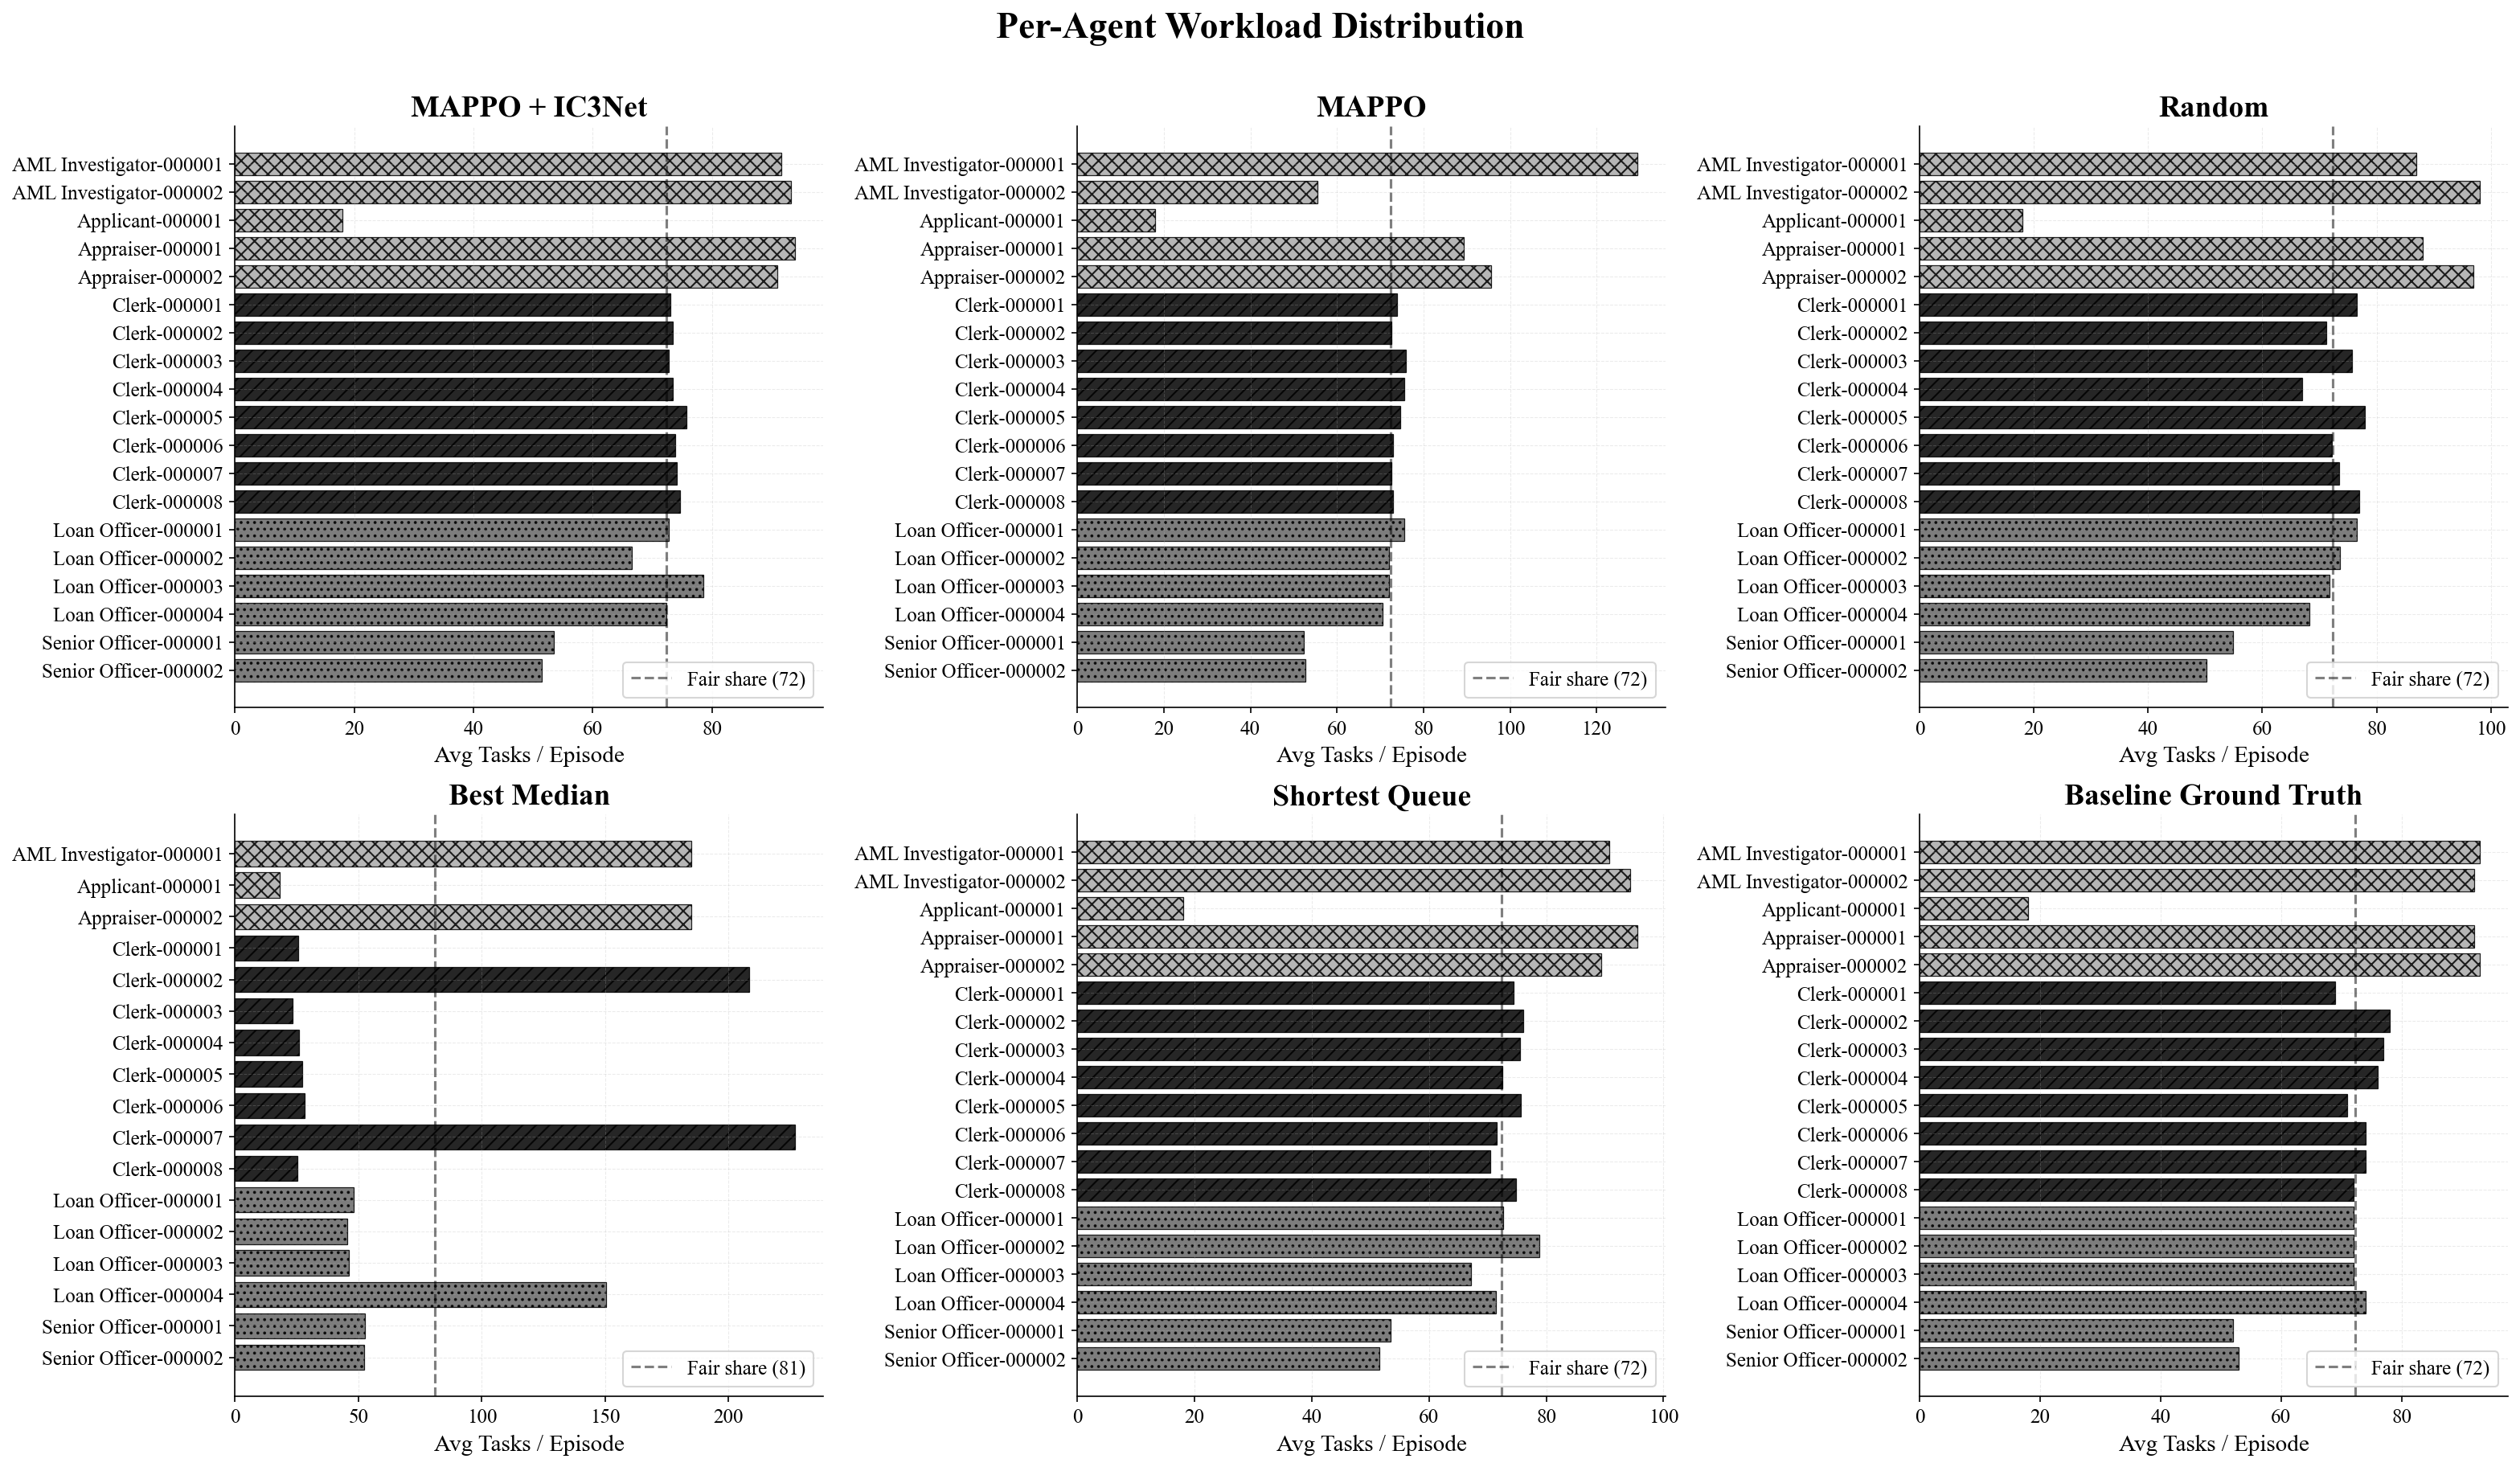

In [66]:
# ============================================================
# FIGURE 7: Workload Distribution per Agent (grayscale)
# 3 columns × 2 rows layout with enlarged fonts for readability
# ============================================================
n_methods = len(all_data)
n_cols = 3
n_rows = -(-n_methods // n_cols)  # ceil

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7 * n_cols, 6 * n_rows),
    squeeze=False,
)
fig.suptitle("Per-Agent Workload Distribution", fontweight="bold", y=1.01, fontsize=22)

# Grayscale shades for agent roles
role_styles = {
    "technician": {"color": "#000000", "hatch": "///"},
    "pharmacist": {"color": "#666666", "hatch": "..."},
    "other":      {"color": "#AAAAAA", "hatch": "xxx"},
}

for idx, (name, episodes) in enumerate(all_data.items()):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    # Aggregate task counts per agent across all episodes
    agent_totals = defaultdict(int)
    for ep in episodes:
        if "task_agent_name" in ep.columns:
            for agent, count in ep.groupby("task_agent_name").size().items():
                agent_totals[agent] += count

    if not agent_totals:
        ax.set_title(method_label(name), fontsize=18, fontweight="bold")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, fontsize=14)
        continue

    # Sort agents by name
    sorted_agents = sorted(agent_totals.keys())
    counts = [agent_totals[a] / len(episodes) for a in sorted_agents]  # avg per episode

    # Assign grayscale by role
    bar_colors = []
    bar_hatches = []
    for a in sorted_agents:
        a_lower = a.lower()
        if "technician" in a_lower or "clerk" in a_lower:
            bar_colors.append(role_styles["technician"]["color"])
            bar_hatches.append(role_styles["technician"]["hatch"])
        elif "pharmacist" in a_lower or "officer" in a_lower or "senior" in a_lower:
            bar_colors.append(role_styles["pharmacist"]["color"])
            bar_hatches.append(role_styles["pharmacist"]["hatch"])
        else:
            bar_colors.append(role_styles["other"]["color"])
            bar_hatches.append(role_styles["other"]["hatch"])

    y_pos = np.arange(len(sorted_agents))
    bars = ax.barh(y_pos, counts, color=bar_colors, alpha=0.85,
                   edgecolor="black", linewidth=0.6)
    for bar, h in zip(bars, bar_hatches):
        bar.set_hatch(h)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_agents, fontsize=12)
    ax.tick_params(axis="x", labelsize=12)
    ax.set_xlabel("Avg Tasks / Episode", fontsize=14)
    ax.set_title(method_label(name), fontsize=18, fontweight="bold")
    ax.invert_yaxis()

    # Reference line for fair distribution
    fair_share = np.mean(counts)
    ax.axvline(fair_share, color="black", linestyle="--", alpha=0.5,
               label=f"Fair share ({fair_share:.0f})")
    ax.legend(fontsize=12, loc="lower right")

# Hide unused subplots
for i in range(n_methods, n_rows * n_cols):
    row, col = divmod(i, n_cols)
    axes[row][col].set_visible(False)

plt.tight_layout()
plt.savefig("workload_distribution.pdf", bbox_inches="tight")
plt.show()


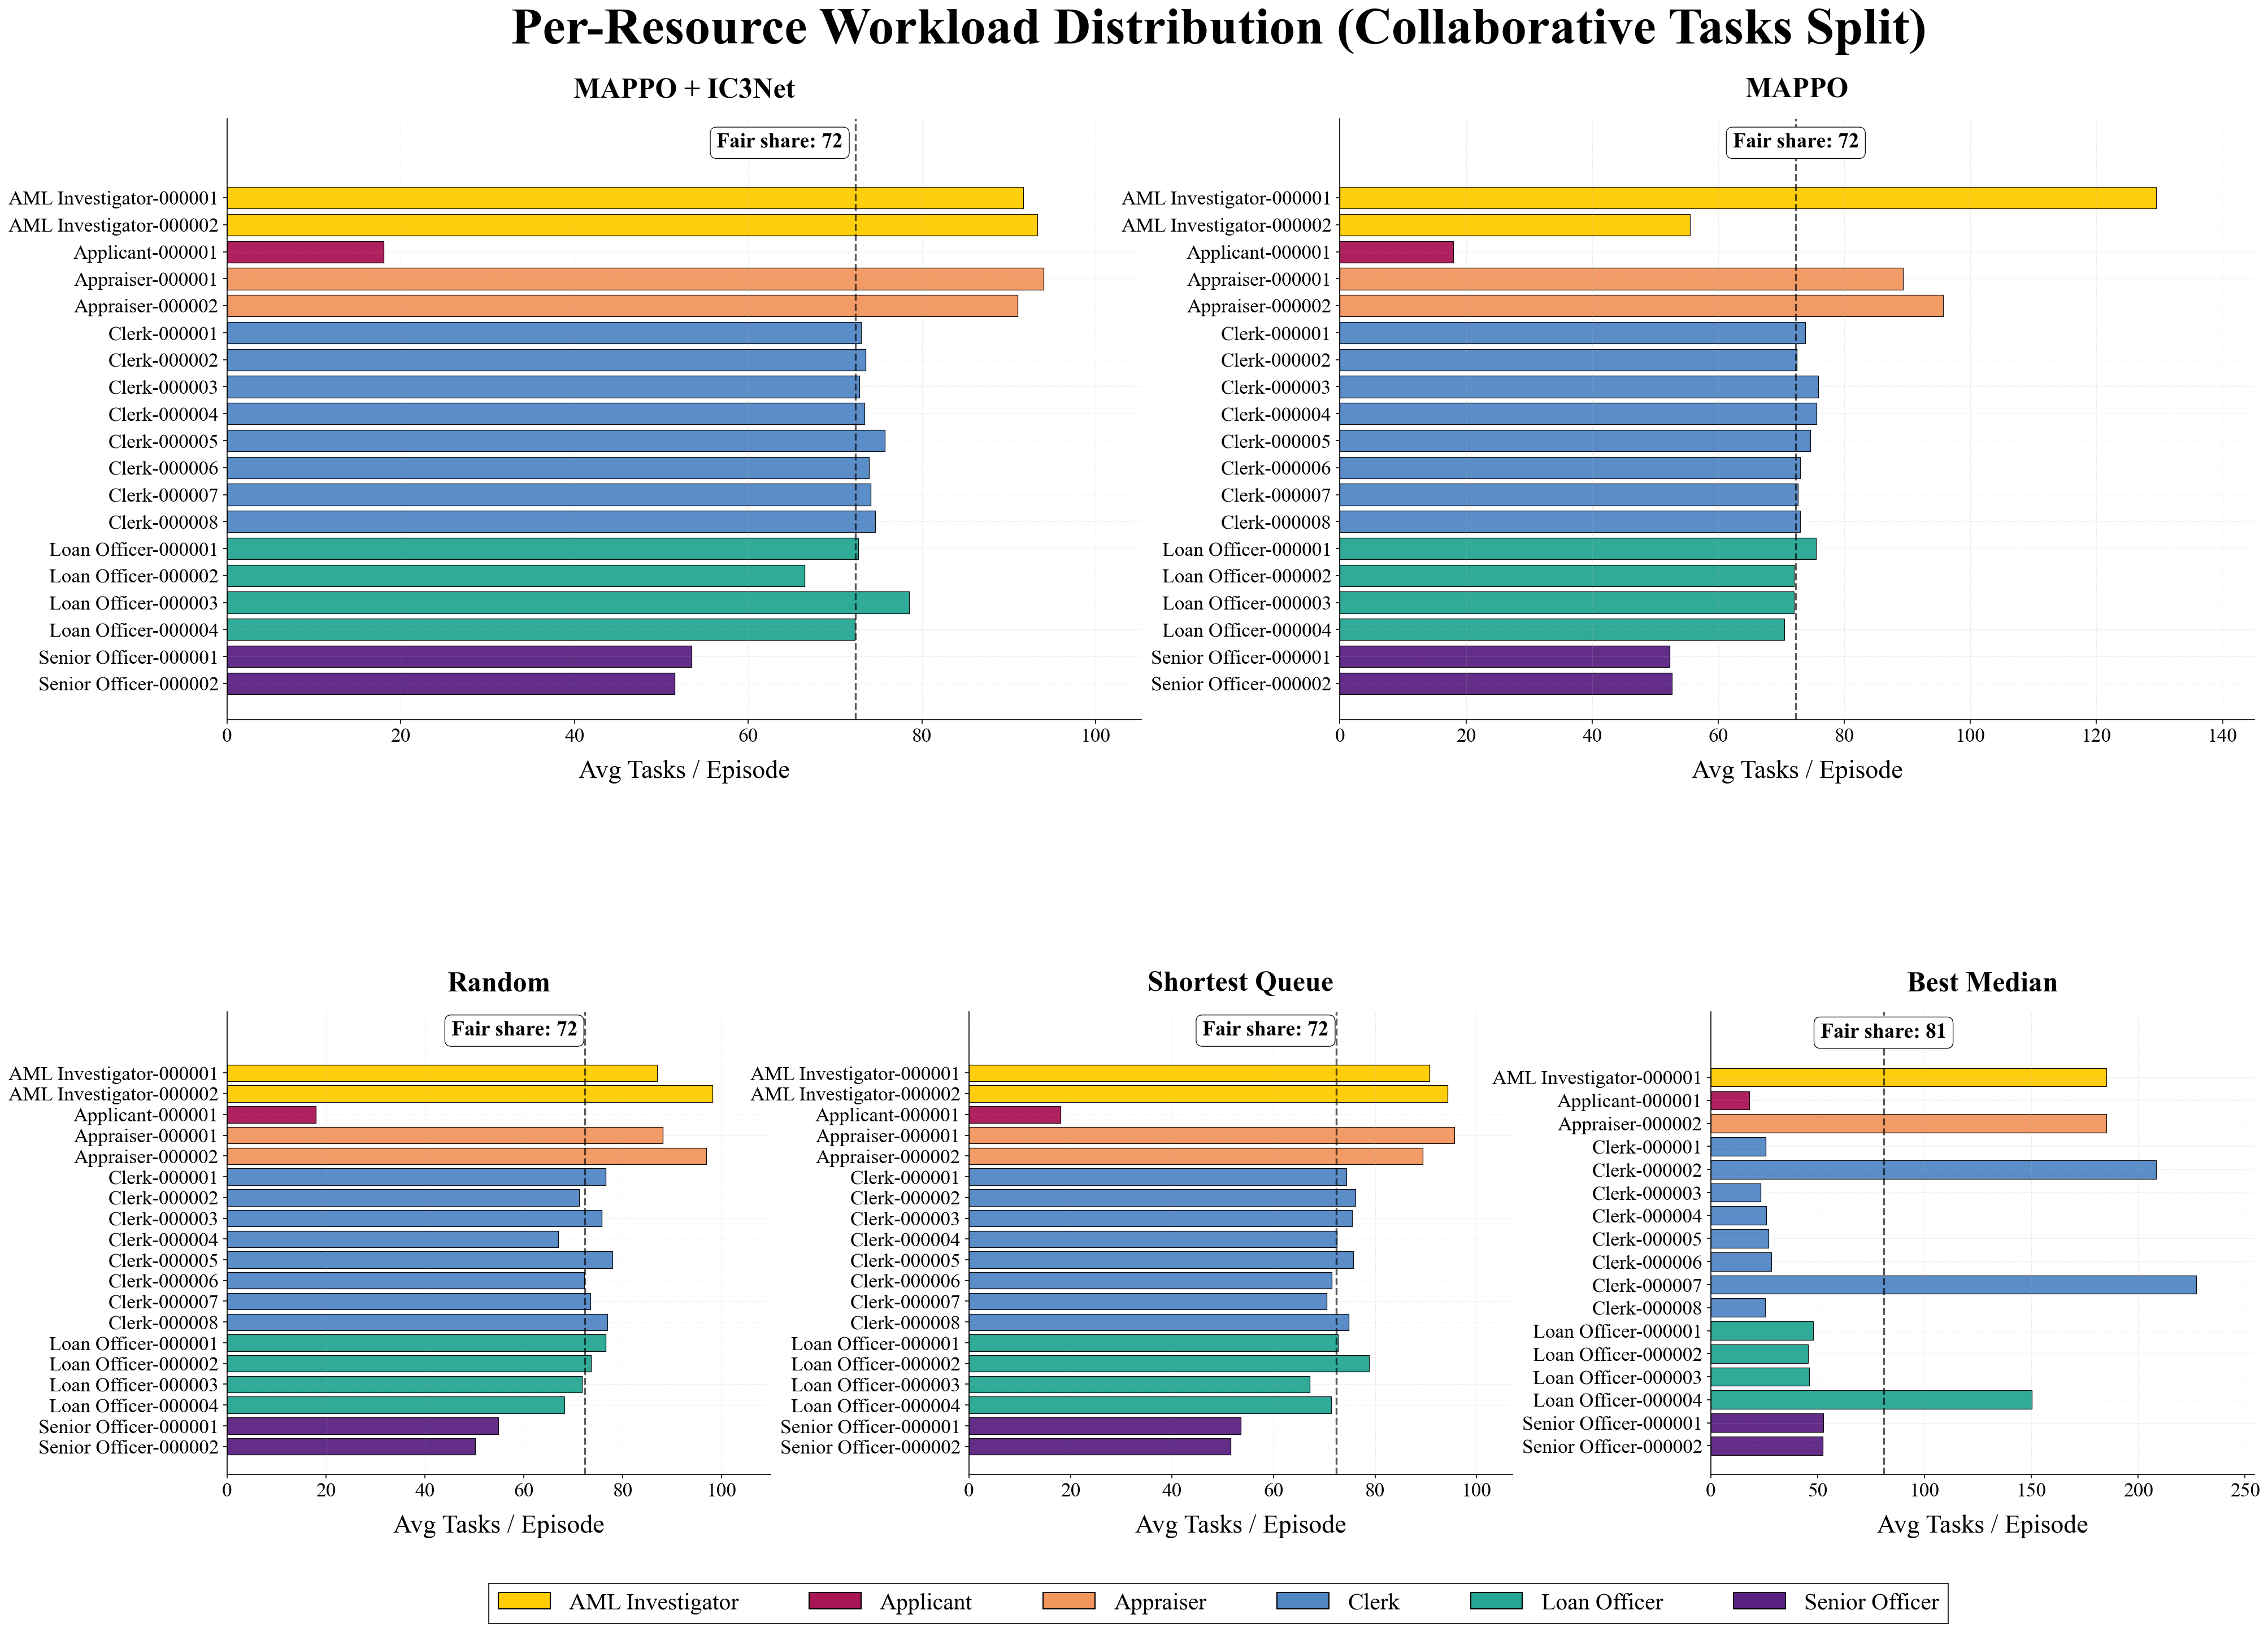

In [80]:
# ============================================================
# FIGURE 7b: Workload Distribution per Individual Resource
# Layout: 2 main methods on top — bigger (MAPPO + IC3Net, MAPPO)
#         3 baselines below (Random, Shortest Queue, Best Median)
# Collaborative tasks split across participating agents.
# Each role gets its own distinct colour from the project palette.
# ============================================================
import re as _re
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

TITLE_FS, AXLABEL_FS, TICK_FS, LEGEND_FS, SUBTITLE_FS = 44, 22, 17, 18, 24

top_order    = ["mappo_parallel_comm", "mappo_parallel"]
bottom_order = ["baseline_random", "baseline_shortest_queue", "baseline_best_median"]

top_methods    = [m for m in top_order    if m in all_data]
bottom_methods = [m for m in bottom_order if m in all_data]
leftovers = [m for m in all_data if m not in top_methods and m not in bottom_methods]
bottom_methods += leftovers

# Explicit colour per role (from project palette). Each role is visually distinct.
ROLE_COLORS = {
    "AML Investigator": "#FFCD00",  # yellow
    "Appraiser":        "#F3965E",  # orange
    "Applicant":        "#AA1555",  # magenta
    "Clerk":            "#5287C6",  # blue
    "Loan Officer":     "#24A793",  # teal
    "Senior Officer":   "#5B2182",  # purple
}
_FALLBACK_PALETTE = ["#FFE6AB", "#6A6A6A", "#B5B5B5"]

def _role_for(agent_name):
    """Extract the role label by stripping trailing '-<digits>' / '_<digits>' / spaces+digits."""
    stripped = _re.sub(r"[-_\s]*\d+\s*$", "", agent_name).strip()
    return stripped if stripped else agent_name

def _color_for(role, _cache={}):
    if role in ROLE_COLORS:
        return ROLE_COLORS[role]
    if role not in _cache:
        _cache[role] = _FALLBACK_PALETTE[len(_cache) % len(_FALLBACK_PALETTE)]
    return _cache[role]

# Generous canvas so nothing collides
fig = plt.figure(figsize=(26, 20))
gs = gridspec.GridSpec(
    2, 6, figure=fig,
    hspace=0.55, wspace=1.15,
    height_ratios=[1.3, 1.0],
    top=0.91, bottom=0.11, left=0.05, right=0.97,
)
fig.suptitle("Per-Resource Workload Distribution (Collaborative Tasks Split)",
             fontweight="bold", fontsize=TITLE_FS, y=0.975)

seen_roles = []   # preserve first-seen order for the legend

def _plot_one(ax, name):
    episodes = all_data[name]
    agent_totals = defaultdict(int)
    for ep in episodes:
        if "task_agent_name" in ep.columns:
            for _, row_data in ep.iterrows():
                agent_str = str(row_data["task_agent_name"])
                for agent in [a.strip() for a in agent_str.split("|")]:
                    if agent and agent != "nan":
                        agent_totals[agent] += 1

    if not agent_totals:
        ax.set_title(method_label(name), fontsize=SUBTITLE_FS,
                     fontweight="bold", pad=18)
        ax.text(0.5, 0.5, "No data", ha="center", va="center",
                transform=ax.transAxes, fontsize=AXLABEL_FS)
        return

    sorted_agents = sorted(agent_totals.keys())
    counts = [agent_totals[a] / len(episodes) for a in sorted_agents]
    roles  = [_role_for(a) for a in sorted_agents]
    bar_colors = [_color_for(r) for r in roles]

    for r in roles:
        if r not in seen_roles:
            seen_roles.append(r)

    y_pos = np.arange(len(sorted_agents))
    ax.barh(y_pos, counts, color=bar_colors, alpha=0.95,
            edgecolor="black", linewidth=0.6)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_agents, fontsize=TICK_FS)
    ax.set_xlabel("Avg Tasks / Episode", fontsize=AXLABEL_FS, labelpad=12)
    ax.tick_params(axis="x", labelsize=TICK_FS)
    ax.set_title(method_label(name), fontsize=SUBTITLE_FS,
                 fontweight="bold", pad=18)
    ax.invert_yaxis()

    # Modest right-side padding so bars can never touch the plot edge
    max_val = max(counts) if counts else 1.0
    ax.set_xlim(0, max_val * 1.12)

    # Dashed reference line at the fair-share value
    fair_share = float(np.mean(counts))
    ax.axvline(fair_share, color="black", linestyle="--",
               alpha=0.65, linewidth=1.6)

    # Carve out empty space ABOVE the first bar (inside the axes) so the
    # Fair-share label can sit right next to its dashed line without
    # overlapping any role-name bar OR the subplot title (title lives
    # OUTSIDE the axes, so putting the label INSIDE is fully safe).
    bot, top = ax.get_ylim()   # inverted: bot > top
    ax.set_ylim(bot, top - 1.6)

    # Horizontal placement: stay near the line, but if the line is close to
    # an edge, anchor the label so it doesn't slide off the axes.
    if fair_share < 0.35 * max_val:
        anchor_x = fair_share + 0.015 * max_val
        anchor_ha = "left"
    elif fair_share > 0.65 * max_val:
        anchor_x = fair_share - 0.015 * max_val
        anchor_ha = "right"
    else:
        anchor_x = fair_share
        anchor_ha = "center"

    ax.text(anchor_x, top - 0.7, f"Fair share: {fair_share:.0f}",
            ha=anchor_ha, va="center",
            fontsize=LEGEND_FS, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="black", linewidth=0.6))

# Top row: 2 bigger subplots (MAPPO + IC3Net, MAPPO)
for slot, name in zip([gs[0, 0:3], gs[0, 3:6]], top_methods[:2]):
    _plot_one(fig.add_subplot(slot), name)

# Bottom row: 3 equal-width baselines
for slot, name in zip([gs[1, 0:2], gs[1, 2:4], gs[1, 4:6]], bottom_methods):
    _plot_one(fig.add_subplot(slot), name)

# Single figure-level role legend at the bottom
legend_handles = [Patch(facecolor=_color_for(r), edgecolor="black", label=r)
                  for r in seen_roles]
if legend_handles:
    fig.legend(handles=legend_handles,
               loc="lower center", bbox_to_anchor=(0.5, 0.015),
               ncol=min(len(legend_handles), 6), fontsize=LEGEND_FS + 2,
               frameon=True, edgecolor="black", fancybox=False,
               handlelength=2.2, columnspacing=3.0)

plt.savefig("workload_distribution_per_resource.pdf", bbox_inches="tight")
plt.show()


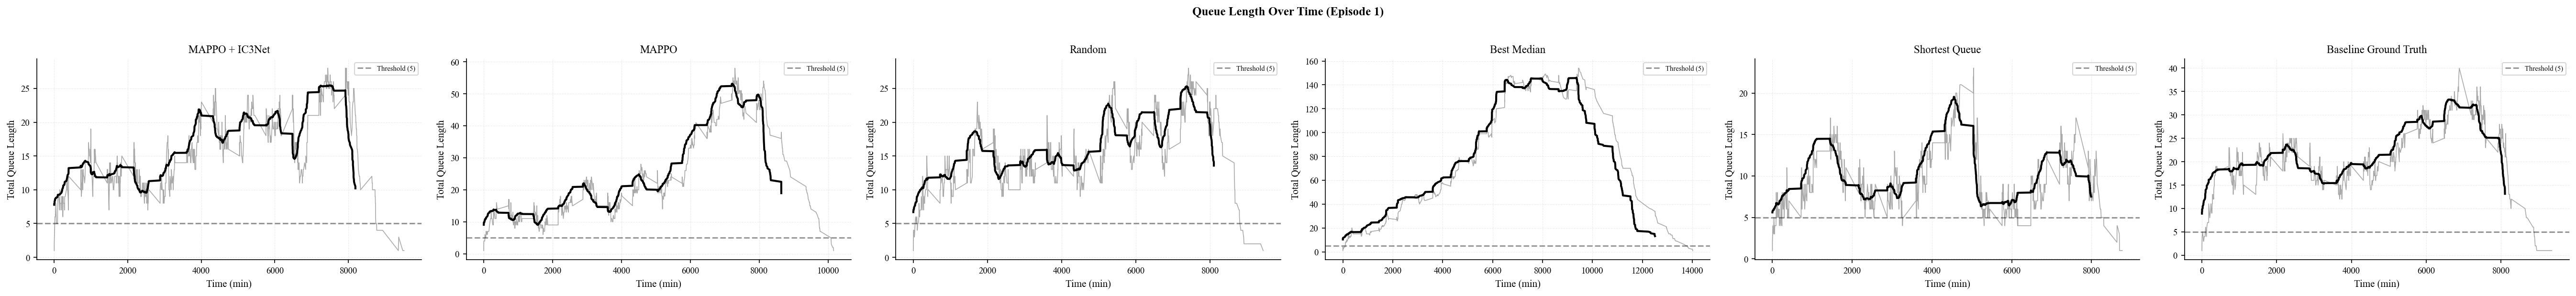

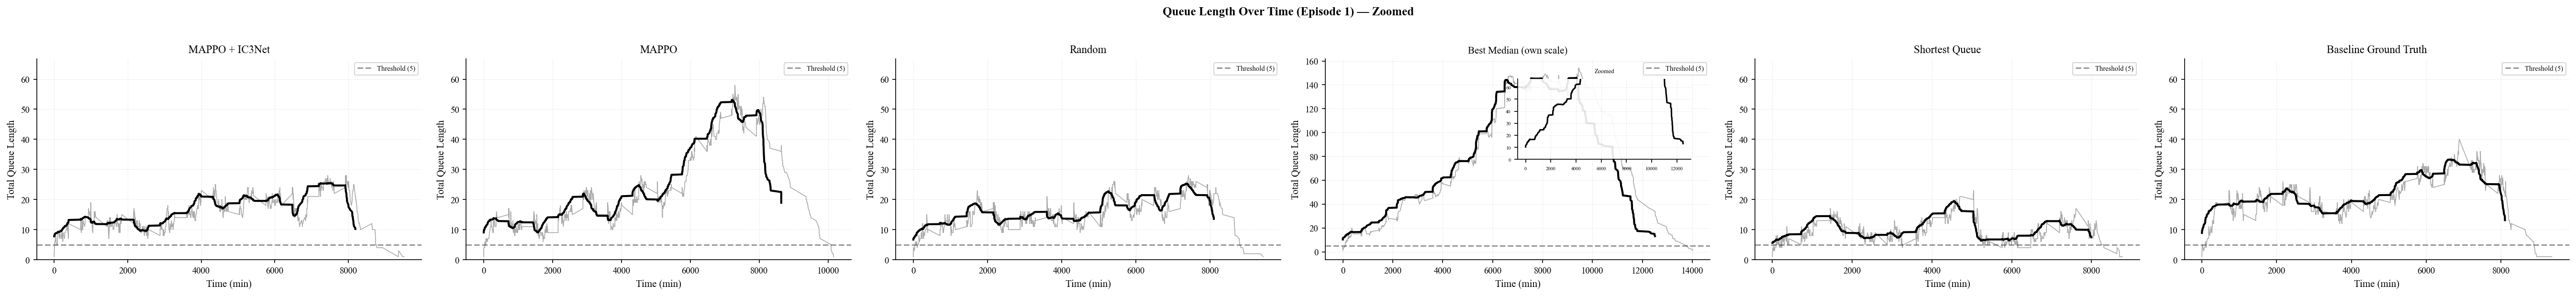

In [68]:
# ============================================================
# FIGURE 7b: Queue Length Over Time (per episode, grayscale)
# Two versions: full scale + zoomed with BM inset
# ============================================================

def compute_queue_timeline(df):
    """Compute queue length at each assignment event.
    Returns sorted list of (timestamp, total_queue)."""
    if "task_agent_id" not in df.columns or len(df) == 0:
        return []
    df_s = df.sort_values("task_assigned_time").copy()
    timeline = []
    for _, row in df_s.iterrows():
        t = row["task_assigned_time"]
        if pd.isna(t):
            continue
        pending = ((df_s["task_assigned_time"] <= t) &
                   (df_s["task_completed_time"] > t)).sum()
        timeline.append((t, pending))
    return timeline

def _plot_queue_panels(all_data, title_suffix="", zoom_to_non_bm=False):
    """Plot queue length panels for all methods. If zoom_to_non_bm, excludes BM from
    shared y-axis and adds BM as inset in its own panel."""
    n = len(all_data)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), squeeze=False)
    fig.suptitle(f"Queue Length Over Time (Episode 1){title_suffix}", fontweight="bold", y=1.02)

    # First pass: compute all data and find non-BM max
    panel_data = {}
    non_bm_max = 0
    for name, episodes in all_data.items():
        if not episodes:
            panel_data[name] = ([], [])
            continue
        timeline = compute_queue_timeline(episodes[0])
        if not timeline:
            panel_data[name] = ([], [])
            continue
        t0 = min(t[0] for t in timeline)
        x_min = [calc_minutes_between(t0, t[0]) for t in timeline]
        queues = [t[1] for t in timeline]
        # Smooth
        if len(queues) >= 10:
            window = max(5, len(queues) // 20)
            smoothed = list(np.convolve(queues, np.ones(window)/window, mode="valid"))
            panel_data[name] = (x_min[:len(smoothed)], smoothed, x_min, queues)
        else:
            panel_data[name] = (x_min, queues, x_min, queues)
        if not _is_best_median(name):
            non_bm_max = max(non_bm_max, max(queues) if queues else 0)

    for idx, (name, episodes) in enumerate(all_data.items()):
        ax = axes[0][idx]
        data = panel_data[name]
        if len(data[0]) == 0:
            ax.set_title(method_label(name))
            continue

        is_bm = _is_best_median(name)

        if zoom_to_non_bm and is_bm:
            # Show BM at its own scale but mark it
            ax.plot(data[2], data[3], color="#555555", linewidth=0.8, alpha=0.5)
            if len(data[0]) > 0:
                ax.plot(data[0], data[1], color="#000000", linewidth=2)
            ax.set_title(f"{method_label(name)} (own scale)", fontsize=10)
            # Add small inset showing the zoomed range
            inset = ax.inset_axes([0.5, 0.5, 0.45, 0.4])
            inset.plot(data[0], data[1], color="#000000", linewidth=1.5)
            inset.set_ylim(0, non_bm_max * 1.15)
            inset.set_title("Zoomed", fontsize=6)
            inset.tick_params(labelsize=5)
            inset.patch.set_facecolor("white")
            inset.patch.set_alpha(0.9)
            for sp in inset.spines.values():
                sp.set_linewidth(0.8)
        else:
            ax.plot(data[2], data[3], color="#555555", linewidth=0.8, alpha=0.5)
            if len(data[0]) > 0:
                ax.plot(data[0], data[1], color="#000000", linewidth=2)
            ax.set_title(method_label(name))
            if zoom_to_non_bm:
                ax.set_ylim(0, non_bm_max * 1.15)

        ax.axhline(OVERLOAD_THRESHOLD, color="black", linestyle="--", alpha=0.4,
                   label=f"Threshold ({OVERLOAD_THRESHOLD})")
        ax.set_xlabel("Time (min)")
        ax.set_ylabel("Total Queue Length")
        ax.legend(fontsize=7)

    plt.tight_layout()
    return fig

# Version 1: Full scale
fig = _plot_queue_panels(all_data, title_suffix="")
plt.savefig("queue_length_over_time.pdf", bbox_inches="tight")
plt.show()

# Version 2: Zoomed to non-BM range
fig = _plot_queue_panels(all_data, title_suffix=" — Zoomed", zoom_to_non_bm=True)
plt.savefig("queue_length_over_time_zoomed.pdf", bbox_inches="tight")
plt.show()

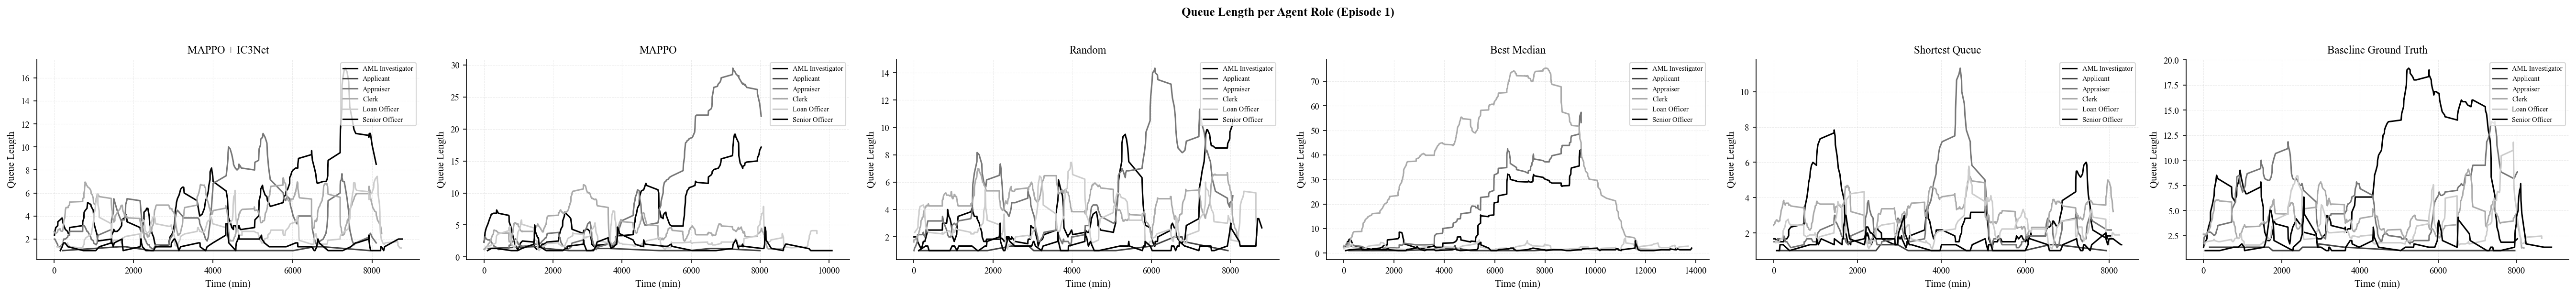

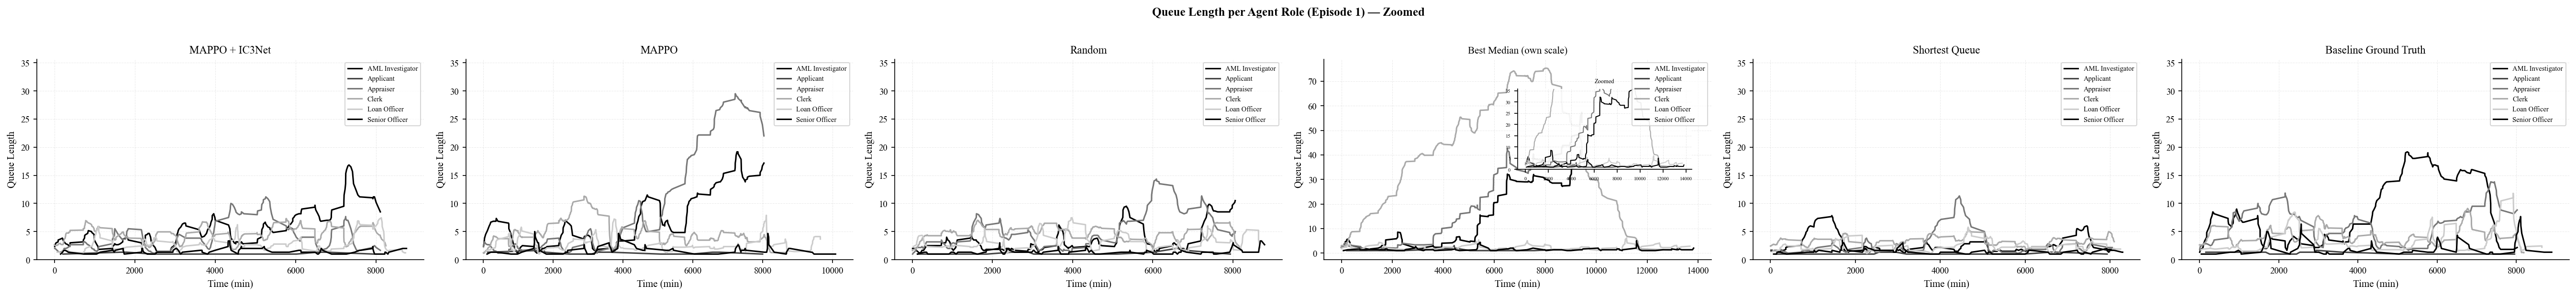

In [69]:
# ============================================================
# FIGURE 7c: Queue Length per Agent Role (Episode 1, grayscale)
# Two versions: full scale + zoomed with BM inset
# ============================================================

def get_agent_role(agent_name):
    """Extract role from agent name like 'Clerk-000001'."""
    first = str(agent_name).split("|")[0]
    return first.rsplit("-", 1)[0].strip() if "-" in first else first

role_grays = {}
_rg = ["#000000", "#444444", "#777777", "#AAAAAA", "#CCCCCC"]

def _plot_queue_role_panels(all_data, title_suffix="", zoom_to_non_bm=False):
    n = len(all_data)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), squeeze=False)
    fig.suptitle(f"Queue Length per Agent Role (Episode 1){title_suffix}", fontweight="bold", y=1.02)

    # First pass: compute all role data and find non-BM max
    all_panel_data = {}
    non_bm_max = 0

    for name, episodes in all_data.items():
        if not episodes:
            all_panel_data[name] = {}
            continue
        ep = episodes[0]
        agent_col = "task_agent_name" if "task_agent_name" in ep.columns else "task_agent_id"
        df_s = ep.sort_values("task_assigned_time")
        t0 = df_s["task_assigned_time"].dropna().min()

        role_queues = defaultdict(list)
        for _, row in df_s.iterrows():
            t = row["task_assigned_time"]
            if pd.isna(t):
                continue
            agent = str(row[agent_col]).split("|")[0]
            role = get_agent_role(agent)
            role_agents = [a for a in ep[agent_col].unique()
                           if get_agent_role(str(a).split("|")[0]) == role]
            pending = 0
            for ra in role_agents:
                ra_tasks = df_s[df_s[agent_col].astype(str).str.contains(str(ra).split("|")[0], regex=False)]
                pending += ((ra_tasks["task_assigned_time"] <= t) &
                            (ra_tasks["task_completed_time"] > t)).sum()
            role_queues[role].append((t, pending))

        # Smooth each role
        panel = {}
        for role in sorted(role_queues.keys()):
            points = role_queues[role]
            if not points:
                continue
            x_min = [calc_minutes_between(t0, p[0]) for p in points]
            y_vals = [p[1] for p in points]
            if len(y_vals) >= 10:
                window = max(3, len(y_vals) // 30)
                smoothed = list(np.convolve(y_vals, np.ones(window)/window, mode="valid"))
                panel[role] = (x_min[:len(smoothed)], smoothed)
            else:
                panel[role] = (x_min, y_vals)
            if not _is_best_median(name):
                non_bm_max = max(non_bm_max, max(y_vals))

            if role not in role_grays:
                role_grays[role] = _rg[len(role_grays) % len(_rg)]

        all_panel_data[name] = panel

    # Plot
    for idx, (name, episodes) in enumerate(all_data.items()):
        ax = axes[0][idx]
        panel = all_panel_data[name]
        is_bm = _is_best_median(name)

        if not panel:
            ax.set_title(method_label(name))
            continue

        if zoom_to_non_bm and is_bm:
            # Full scale in main, zoomed inset
            for role, (rx, ry) in panel.items():
                ax.plot(rx, ry, color=role_grays.get(role, "#555555"), linewidth=1.5, label=role)
            ax.set_title(f"{method_label(name)} (own scale)", fontsize=10)
            ax.legend(fontsize=7, loc="upper right")
            # Inset zoomed to non-BM range
            inset = ax.inset_axes([0.5, 0.45, 0.45, 0.4])
            for role, (rx, ry) in panel.items():
                inset.plot(rx, ry, color=role_grays.get(role, "#555555"), linewidth=1)
            inset.set_ylim(0, non_bm_max * 1.15)
            inset.set_title("Zoomed", fontsize=6)
            inset.tick_params(labelsize=5)
            inset.patch.set_facecolor("white")
            inset.patch.set_alpha(0.9)
            for sp in inset.spines.values():
                sp.set_linewidth(0.8)
        else:
            for role, (rx, ry) in panel.items():
                ax.plot(rx, ry, color=role_grays.get(role, "#555555"), linewidth=1.5, label=role)
            ax.set_title(method_label(name))
            ax.legend(fontsize=7, loc="upper right")
            if zoom_to_non_bm:
                ax.set_ylim(0, non_bm_max * 1.15)

        ax.set_xlabel("Time (min)")
        ax.set_ylabel("Queue Length")

    plt.tight_layout()
    return fig

# Version 1: Full scale
fig = _plot_queue_role_panels(all_data)
plt.savefig("queue_length_per_role.pdf", bbox_inches="tight")
plt.show()

# Version 2: Zoomed
fig = _plot_queue_role_panels(all_data, title_suffix=" — Zoomed", zoom_to_non_bm=True)
plt.savefig("queue_length_per_role_zoomed.pdf", bbox_inches="tight")
plt.show()

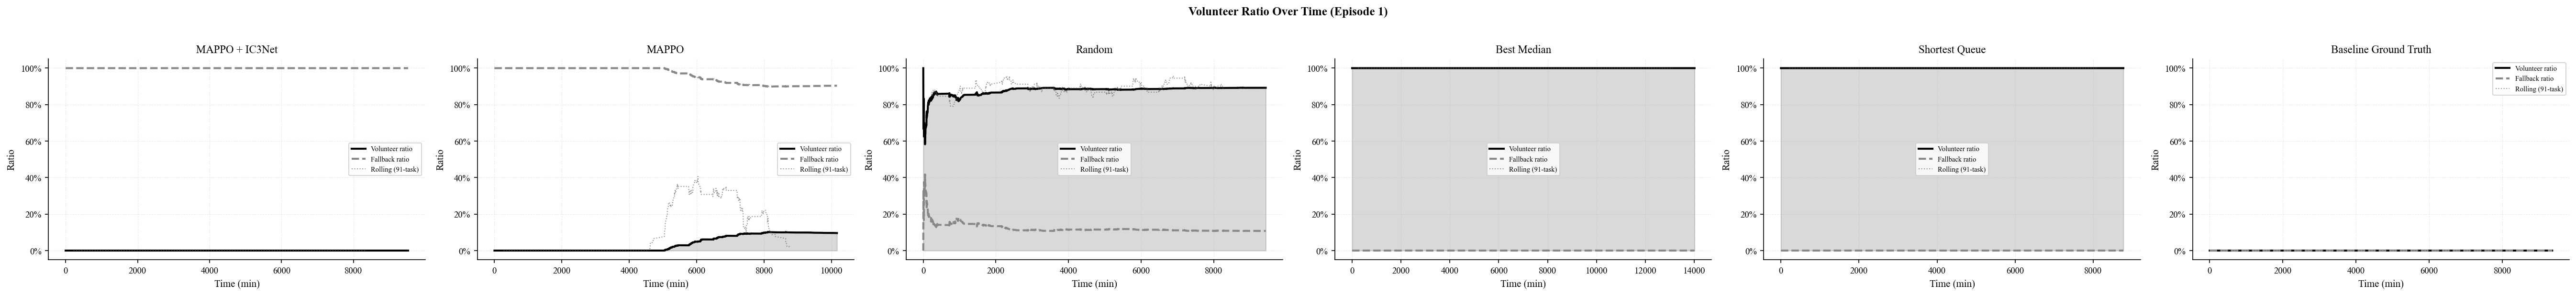

In [70]:
# ============================================================
# FIGURE 7d: Volunteer vs Fallback Ratio Over Time (Episode 1)
# Shows cumulative volunteer/fallback ratio as tasks are assigned
# ============================================================

fig, axes = plt.subplots(1, len(all_data), figsize=(6 * len(all_data), 4), squeeze=False)
fig.suptitle("Volunteer Ratio Over Time (Episode 1)", fontweight="bold", y=1.02)

for idx, (name, episodes) in enumerate(all_data.items()):
    ax = axes[0][idx]
    if not episodes:
        ax.set_title(method_label(name))
        continue
    
    ep = episodes[0]
    if "task_assignment_type" not in ep.columns:
        ax.set_title(method_label(name))
        ax.text(0.5, 0.5, "No assignment type data", ha="center", va="center",
                transform=ax.transAxes)
        continue
    
    df_s = ep.sort_values("task_assigned_time").copy()
    df_s = df_s.dropna(subset=["task_assigned_time", "task_assignment_type"])
    
    t0 = df_s["task_assigned_time"].min()
    x_min = [calc_minutes_between(t0, t) for t in df_s["task_assigned_time"]]
    
    # Cumulative volunteer ratio
    is_vol = df_s["task_assignment_type"].str.contains("volunteer", case=False).astype(int)
    cum_vol = is_vol.cumsum().values
    cum_total = np.arange(1, len(is_vol) + 1)
    cum_ratio = cum_vol / cum_total
    
    # Cumulative fallback ratio
    is_fb = df_s["task_assignment_type"].str.contains("fallback", case=False).astype(int)
    cum_fb = is_fb.cumsum().values
    cum_fb_ratio = cum_fb / cum_total
    
    ax.plot(x_min, cum_ratio, color="#000000", linewidth=2, label="Volunteer ratio")
    ax.plot(x_min, cum_fb_ratio, color="#888888", linewidth=2, linestyle="--",
            label="Fallback ratio")
    ax.fill_between(x_min, cum_ratio, alpha=0.15, color="#000000")
    
    # Also show instantaneous ratio (windowed)
    window = max(10, len(is_vol) // 15)
    if len(is_vol) >= window:
        rolling_vol = pd.Series(is_vol.values).rolling(window, center=True).mean()
        ax.plot(x_min, rolling_vol, color="#555555", linewidth=1, alpha=0.6,
                linestyle=":", label=f"Rolling ({window}-task)")
    
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Ratio")
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.set_title(method_label(name))
    ax.legend(fontsize=7, loc="best")

plt.tight_layout()
plt.savefig("volunteer_ratio_over_time.pdf", bbox_inches="tight")
plt.show()

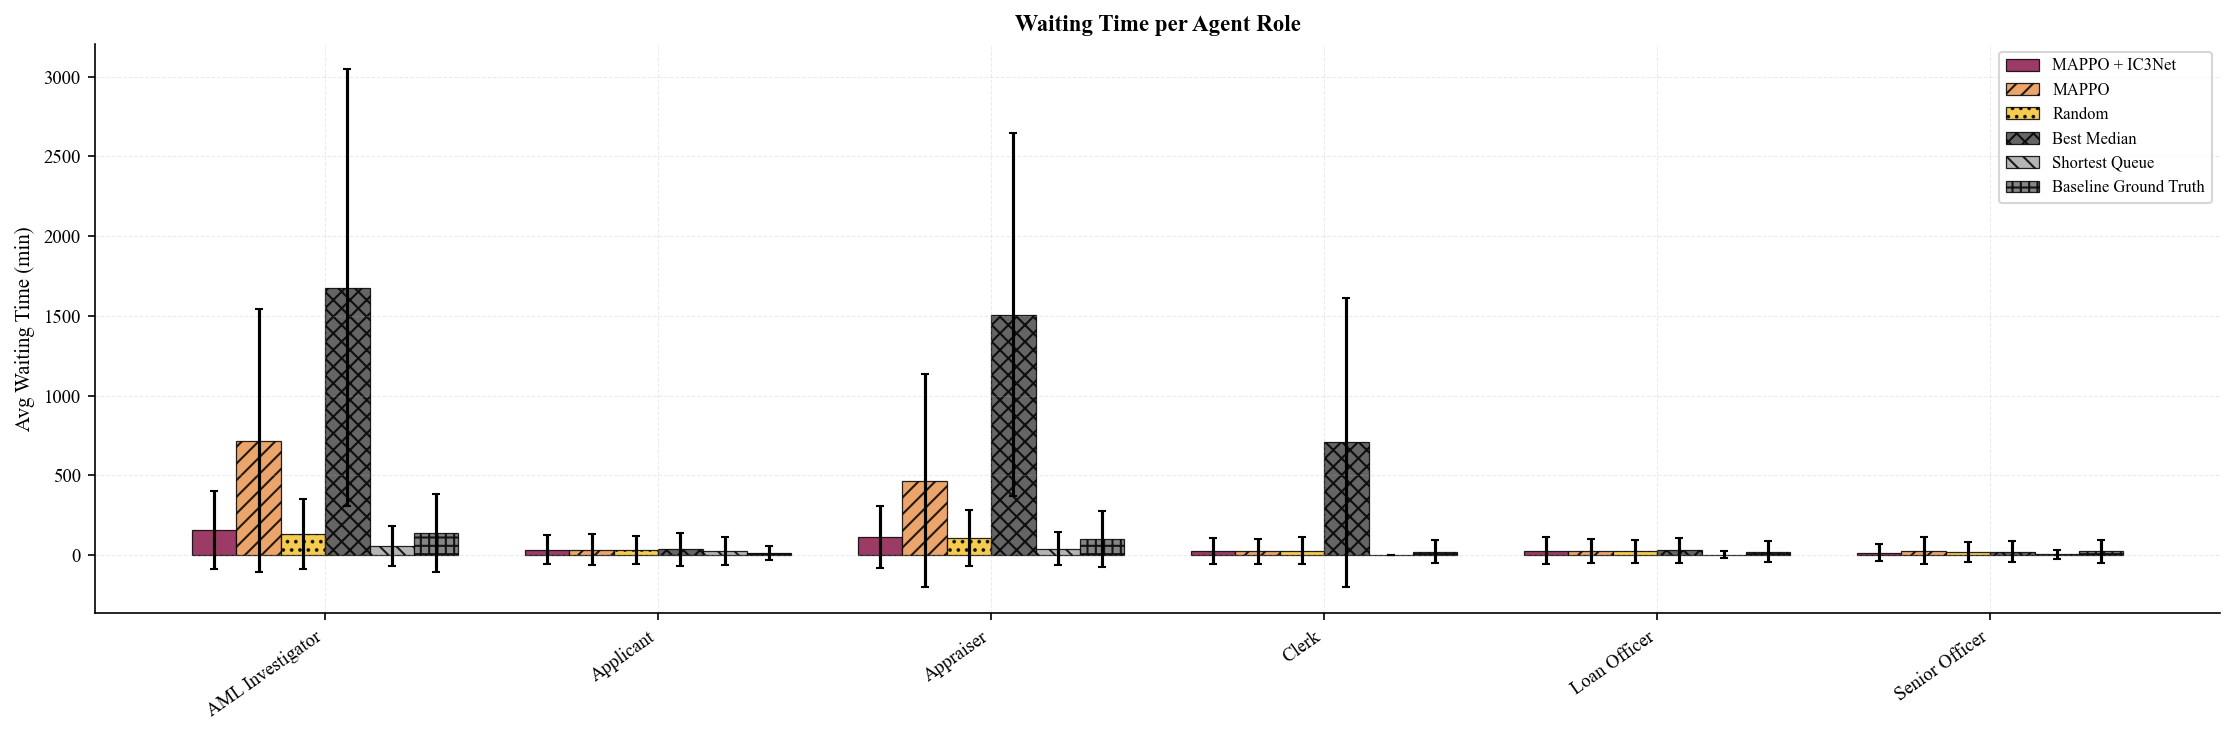

In [71]:
# ============================================================
# FIGURE 7e: Waiting Time per Agent Role (grayscale)
# Bar chart comparing avg waiting time per role across methods
# ============================================================

# Collect waiting times by role for each method
role_wait_data = {}  # method -> {role: [waiting_times]}
all_roles = set()
for name, episodes in all_data.items():
    rw = defaultdict(list)
    agent_col = "task_agent_name" if "task_agent_name" in episodes[0].columns else "task_agent_id"
    for ep in episodes:
        for _, row in ep.iterrows():
            if pd.notna(row.get("task_assigned_time")) and pd.notna(row.get("task_started_time")):
                wt = max(0, calc_minutes_between(row["task_assigned_time"], row["task_started_time"]))
                agent = str(row[agent_col]).split("|")[0]
                role = get_agent_role(agent)
                rw[role].append(wt)
                all_roles.add(role)
    role_wait_data[name] = rw

all_roles = sorted(all_roles)
method_names_list = list(all_data.keys())
n_methods = len(method_names_list)
n_roles = len(all_roles)

fig, ax = plt.subplots(figsize=(max(10, n_roles * 2.5), 5))
ax.set_title("Waiting Time per Agent Role", fontweight="bold")

bar_width = 0.8 / n_methods
x_roles = np.arange(n_roles)

for mi, name in enumerate(method_names_list):
    means = []
    stds = []
    for role in all_roles:
        vals = role_wait_data[name].get(role, [])
        means.append(np.mean(vals) if vals else 0)
        stds.append(np.std(vals) if vals else 0)
    
    offset = (mi - n_methods / 2 + 0.5) * bar_width
    bars = ax.bar(x_roles + offset, means, bar_width, yerr=stds, capsize=2,
                  color=styles[name]["color"], hatch=styles[name]["hatch"],
                  edgecolor="black", linewidth=0.6, alpha=0.85,
                  label=method_label(name))

ax.set_xticks(x_roles)
ax.set_xticklabels(all_roles, rotation=35, ha="right")
ax.set_ylabel("Avg Waiting Time (min)")
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("waiting_time_per_role.pdf", bbox_inches="tight")
plt.show()

In [72]:
# ============================================================
# TABLE 3b: Volunteer/Fallback Breakdown per Agent Role
# ============================================================
print(f"\n{'='*120}")
print(f"  Table 3b: Assignment Type Breakdown per Agent Role")
print(f"{'='*120}")

for name, episodes in all_data.items():
    if "task_assignment_type" not in episodes[0].columns:
        continue
    
    agent_col = "task_agent_name" if "task_agent_name" in episodes[0].columns else "task_agent_id"
    role_assign = defaultdict(lambda: defaultdict(int))
    role_totals = defaultdict(int)
    
    for ep in episodes:
        for _, row in ep.iterrows():
            agent = str(row[agent_col]).split("|")[0]
            role = get_agent_role(agent)
            atype = str(row.get("task_assignment_type", "unknown"))
            role_assign[role][atype] += 1
            role_totals[role] += 1
    
    rows = []
    for role in sorted(role_assign.keys()):
        total = role_totals[role]
        vol = sum(v for k, v in role_assign[role].items() if "volunteer" in k.lower())
        fb = sum(v for k, v in role_assign[role].items() if "fallback" in k.lower())
        rows.append({
            "Role": role,
            "Total Tasks": total,
            "Volunteer": f"{vol} ({vol/total:.1%})" if total > 0 else "—",
            "Fallback": f"{fb} ({fb/total:.1%})" if total > 0 else "—",
            "Vol. Ratio": f"{vol/total:.1%}" if total > 0 else "—",
        })
    
    print(f"\n  ▸ {method_label(name)}")
    display(pd.DataFrame(rows).set_index("Role"))


  Table 3b: Assignment Type Breakdown per Agent Role

  ▸ MAPPO + IC3Net


,Total Tasks,Volunteer,Fallback,Vol. Ratio
Role,,,,
AML Investigator,1850,0 (0.0%),1850 (100.0%),0.0%
Applicant,180,0 (0.0%),180 (100.0%),0.0%
Appraiser,1850,0 (0.0%),1850 (100.0%),0.0%
Clerk,5910,0 (0.0%),5910 (100.0%),0.0%
Loan Officer,2900,0 (0.0%),2900 (100.0%),0.0%
Senior Officer,1050,0 (0.0%),1050 (100.0%),0.0%



  ▸ MAPPO


,Total Tasks,Volunteer,Fallback,Vol. Ratio
Role,,,,
AML Investigator,1850,831 (44.9%),1019 (55.1%),44.9%
Applicant,180,0 (0.0%),180 (100.0%),0.0%
Appraiser,1850,554 (29.9%),1296 (70.1%),29.9%
Clerk,5910,0 (0.0%),5910 (100.0%),0.0%
Loan Officer,2900,0 (0.0%),2900 (100.0%),0.0%
Senior Officer,1050,0 (0.0%),1050 (100.0%),0.0%



  ▸ Random


...

,Total Tasks,Volunteer,Fallback,Vol. Ratio
Role,,,,
AML Investigator,1850,1850 (100.0%),0 (0.0%),100.0%
Applicant,180,180 (100.0%),0 (0.0%),100.0%
Appraiser,1850,1850 (100.0%),0 (0.0%),100.0%
Clerk,5910,5910 (100.0%),0 (0.0%),100.0%
Loan Officer,2900,2900 (100.0%),0 (0.0%),100.0%
Senior Officer,1050,1050 (100.0%),0 (0.0%),100.0%



  ▸ Shortest Queue


,Total Tasks,Volunteer,Fallback,Vol. Ratio
Role,,,,
AML Investigator,1850,1850 (100.0%),0 (0.0%),100.0%
Applicant,180,180 (100.0%),0 (0.0%),100.0%
Appraiser,1850,1850 (100.0%),0 (0.0%),100.0%
Clerk,5910,5910 (100.0%),0 (0.0%),100.0%
Loan Officer,2900,2900 (100.0%),0 (0.0%),100.0%
Senior Officer,1050,1050 (100.0%),0 (0.0%),100.0%



  ▸ Baseline Ground Truth


,Total Tasks,Volunteer,Fallback,Vol. Ratio
Role,,,,
AML Investigator,1850,0 (0.0%),0 (0.0%),0.0%
Applicant,180,0 (0.0%),0 (0.0%),0.0%
Appraiser,1850,0 (0.0%),0 (0.0%),0.0%
Clerk,5910,0 (0.0%),0 (0.0%),0.0%
Loan Officer,2900,0 (0.0%),0 (0.0%),0.0%
Senior Officer,1050,0 (0.0%),0 (0.0%),0.0%


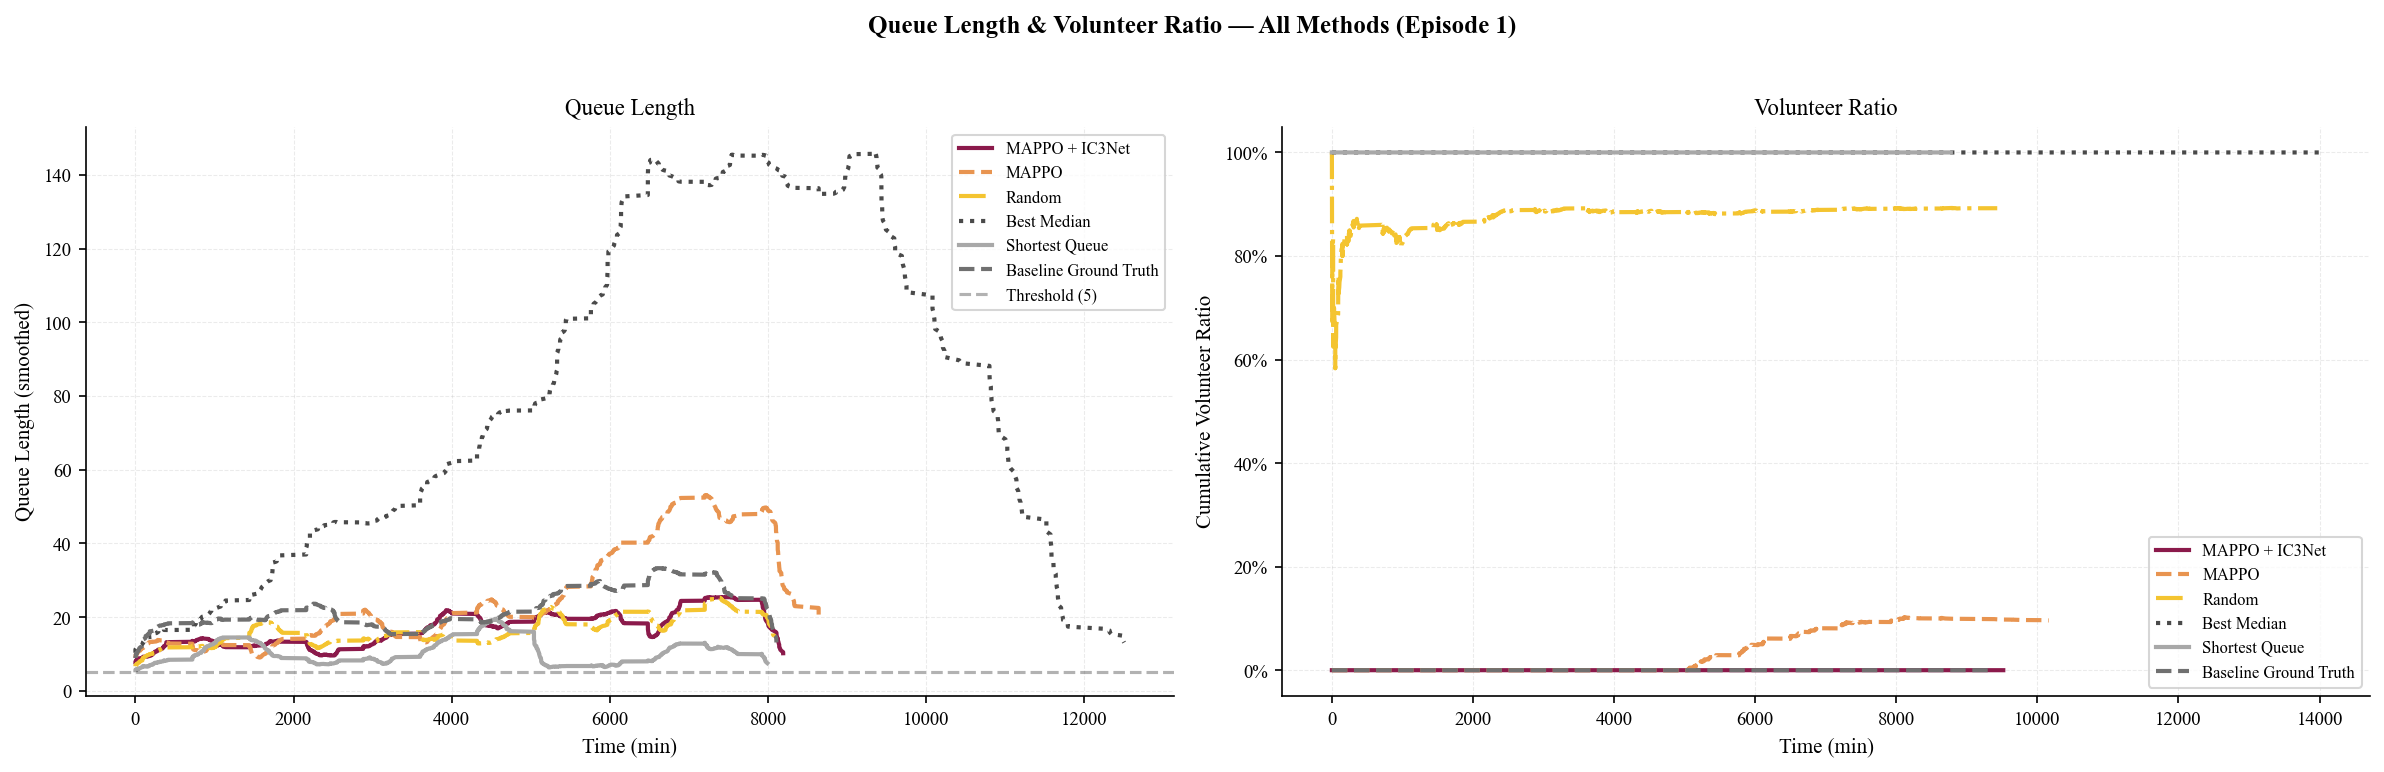

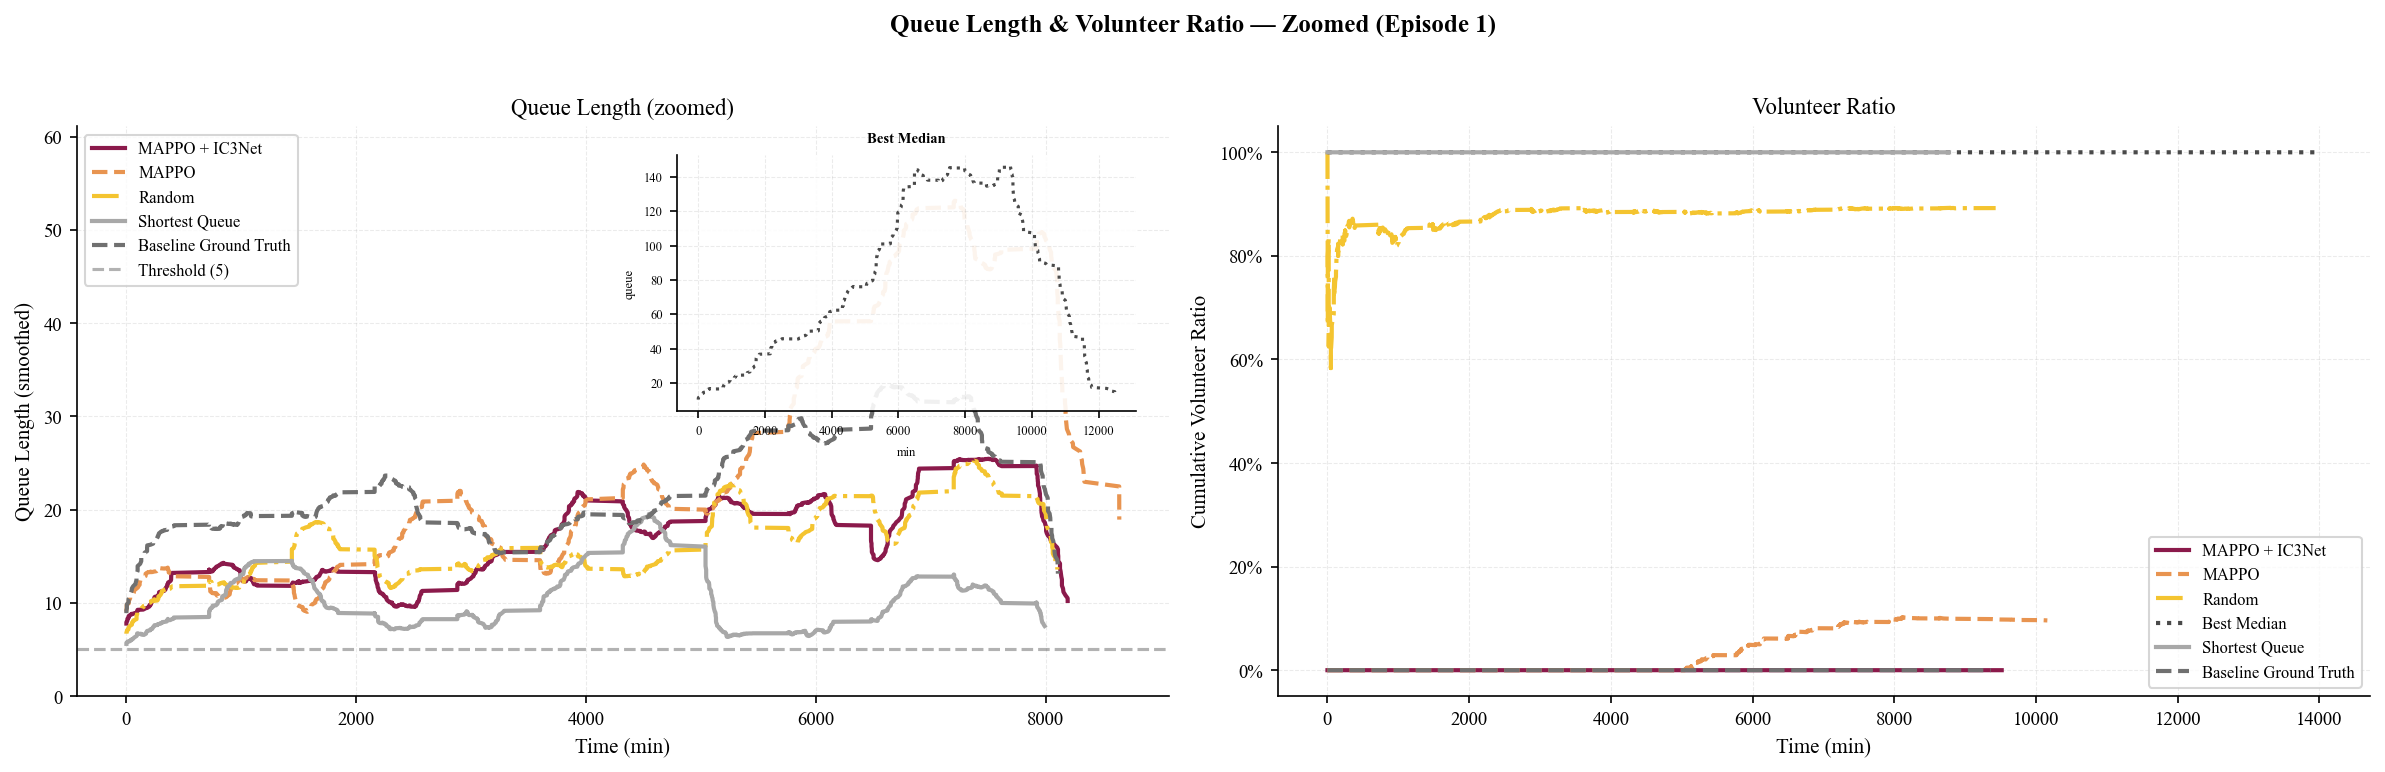

In [73]:
# ============================================================
# FIGURE 7f: All Methods Overlay — Queue & Volunteer (Episode 1)
# Two versions: full scale + zoomed (inset for Best Median)
# ============================================================

def _is_best_median(name):
    return "best_median" in name.lower() or "best median" in name.lower()

# ── Version 1: Full scale ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Queue Length & Volunteer Ratio — All Methods (Episode 1)", fontweight="bold", y=1.02)

for name, episodes in all_data.items():
    if not episodes:
        continue
    ep = episodes[0]
    s = styles[name]
    df_s = ep.sort_values("task_assigned_time").dropna(subset=["task_assigned_time"])
    if len(df_s) == 0:
        continue
    t0 = df_s["task_assigned_time"].min()
    x_min = [calc_minutes_between(t0, t) for t in df_s["task_assigned_time"]]
    queues = []
    for _, row in df_s.iterrows():
        t = row["task_assigned_time"]
        pending = ((df_s["task_assigned_time"] <= t) & (df_s["task_completed_time"] > t)).sum()
        queues.append(pending)
    if len(queues) >= 10:
        window = max(5, len(queues) // 20)
        smoothed = np.convolve(queues, np.ones(window)/window, mode="valid")
        ax1.plot(x_min[:len(smoothed)], smoothed, color=s["color"],
                 linestyle=s["linestyle"], linewidth=2, label=method_label(name))
    else:
        ax1.plot(x_min, queues, color=s["color"], linestyle=s["linestyle"],
                 linewidth=2, label=method_label(name))
    if "task_assignment_type" in ep.columns:
        is_vol = df_s["task_assignment_type"].str.contains("volunteer", case=False, na=False).astype(int)
        cum_ratio = is_vol.cumsum().values / np.arange(1, len(is_vol) + 1)
        ax2.plot(x_min, cum_ratio, color=s["color"], linestyle=s["linestyle"],
                 linewidth=2, label=method_label(name))

ax1.axhline(OVERLOAD_THRESHOLD, color="black", linestyle="--", alpha=0.3, label=f"Threshold ({OVERLOAD_THRESHOLD})")
ax1.set_xlabel("Time (min)"); ax1.set_ylabel("Queue Length (smoothed)"); ax1.set_title("Queue Length")
ax1.legend(fontsize=8)
ax2.set_xlabel("Time (min)"); ax2.set_ylabel("Cumulative Volunteer Ratio")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0)); ax2.set_ylim(-0.05, 1.05)
ax2.set_title("Volunteer Ratio"); ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig("queue_volunteer_overlay.pdf", bbox_inches="tight")
plt.show()

# ── Version 2: Zoomed to non-Best-Median range, with BM inset ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Queue Length & Volunteer Ratio — Zoomed (Episode 1)", fontweight="bold", y=1.02)

# Collect data for determining zoom range
bm_queue_data = None
non_bm_max_queue = 0

for name, episodes in all_data.items():
    if not episodes:
        continue
    ep = episodes[0]
    s = styles[name]
    df_s = ep.sort_values("task_assigned_time").dropna(subset=["task_assigned_time"])
    if len(df_s) == 0:
        continue
    t0 = df_s["task_assigned_time"].min()
    x_min = [calc_minutes_between(t0, t) for t in df_s["task_assigned_time"]]
    queues = []
    for _, row in df_s.iterrows():
        t = row["task_assigned_time"]
        pending = ((df_s["task_assigned_time"] <= t) & (df_s["task_completed_time"] > t)).sum()
        queues.append(pending)

    if len(queues) >= 10:
        window = max(5, len(queues) // 20)
        smoothed = list(np.convolve(queues, np.ones(window)/window, mode="valid"))
        plot_x, plot_y = x_min[:len(smoothed)], smoothed
    else:
        plot_x, plot_y = x_min, queues

    if _is_best_median(name):
        bm_queue_data = (plot_x, plot_y, s)
    else:
        ax1.plot(plot_x, plot_y, color=s["color"], linestyle=s["linestyle"],
                 linewidth=2, label=method_label(name))
        non_bm_max_queue = max(non_bm_max_queue, max(plot_y) if plot_y else 0)

    if "task_assignment_type" in ep.columns:
        is_vol = df_s["task_assignment_type"].str.contains("volunteer", case=False, na=False).astype(int)
        cum_ratio = is_vol.cumsum().values / np.arange(1, len(is_vol) + 1)
        ax2.plot(x_min, cum_ratio, color=s["color"], linestyle=s["linestyle"],
                 linewidth=2, label=method_label(name))

# Set y-axis to non-BM range with some padding
ax1.set_ylim(0, non_bm_max_queue * 1.15)
ax1.axhline(OVERLOAD_THRESHOLD, color="black", linestyle="--", alpha=0.3, label=f"Threshold ({OVERLOAD_THRESHOLD})")
ax1.set_xlabel("Time (min)"); ax1.set_ylabel("Queue Length (smoothed)"); ax1.set_title("Queue Length (zoomed)")
ax1.legend(fontsize=8)

# Add Best Median as inset
if bm_queue_data:
    inset = ax1.inset_axes([0.55, 0.50, 0.42, 0.45])  # [x, y, width, height] in axes coords
    bx, by, bs = bm_queue_data
    inset.plot(bx, by, color=bs["color"], linestyle=bs["linestyle"], linewidth=1.5)
    inset.set_title("Best Median", fontsize=7, fontweight="bold")
    inset.tick_params(labelsize=6)
    inset.set_xlabel("min", fontsize=6)
    inset.set_ylabel("queue", fontsize=6)
    inset.patch.set_alpha(0.9)
    inset.patch.set_facecolor("white")
    for spine in inset.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

ax2.set_xlabel("Time (min)"); ax2.set_ylabel("Cumulative Volunteer Ratio")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0)); ax2.set_ylim(-0.05, 1.05)
ax2.set_title("Volunteer Ratio"); ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig("queue_volunteer_overlay_zoomed.pdf", bbox_inches="tight")
plt.show()

-
-
-

#
#
#
 
O
p
e
r
a
t
i
o
n
a
l
 
M
e
t
r
i
c
s
 
O
v
e
r
 
T
r
a
i
n
i
n
g

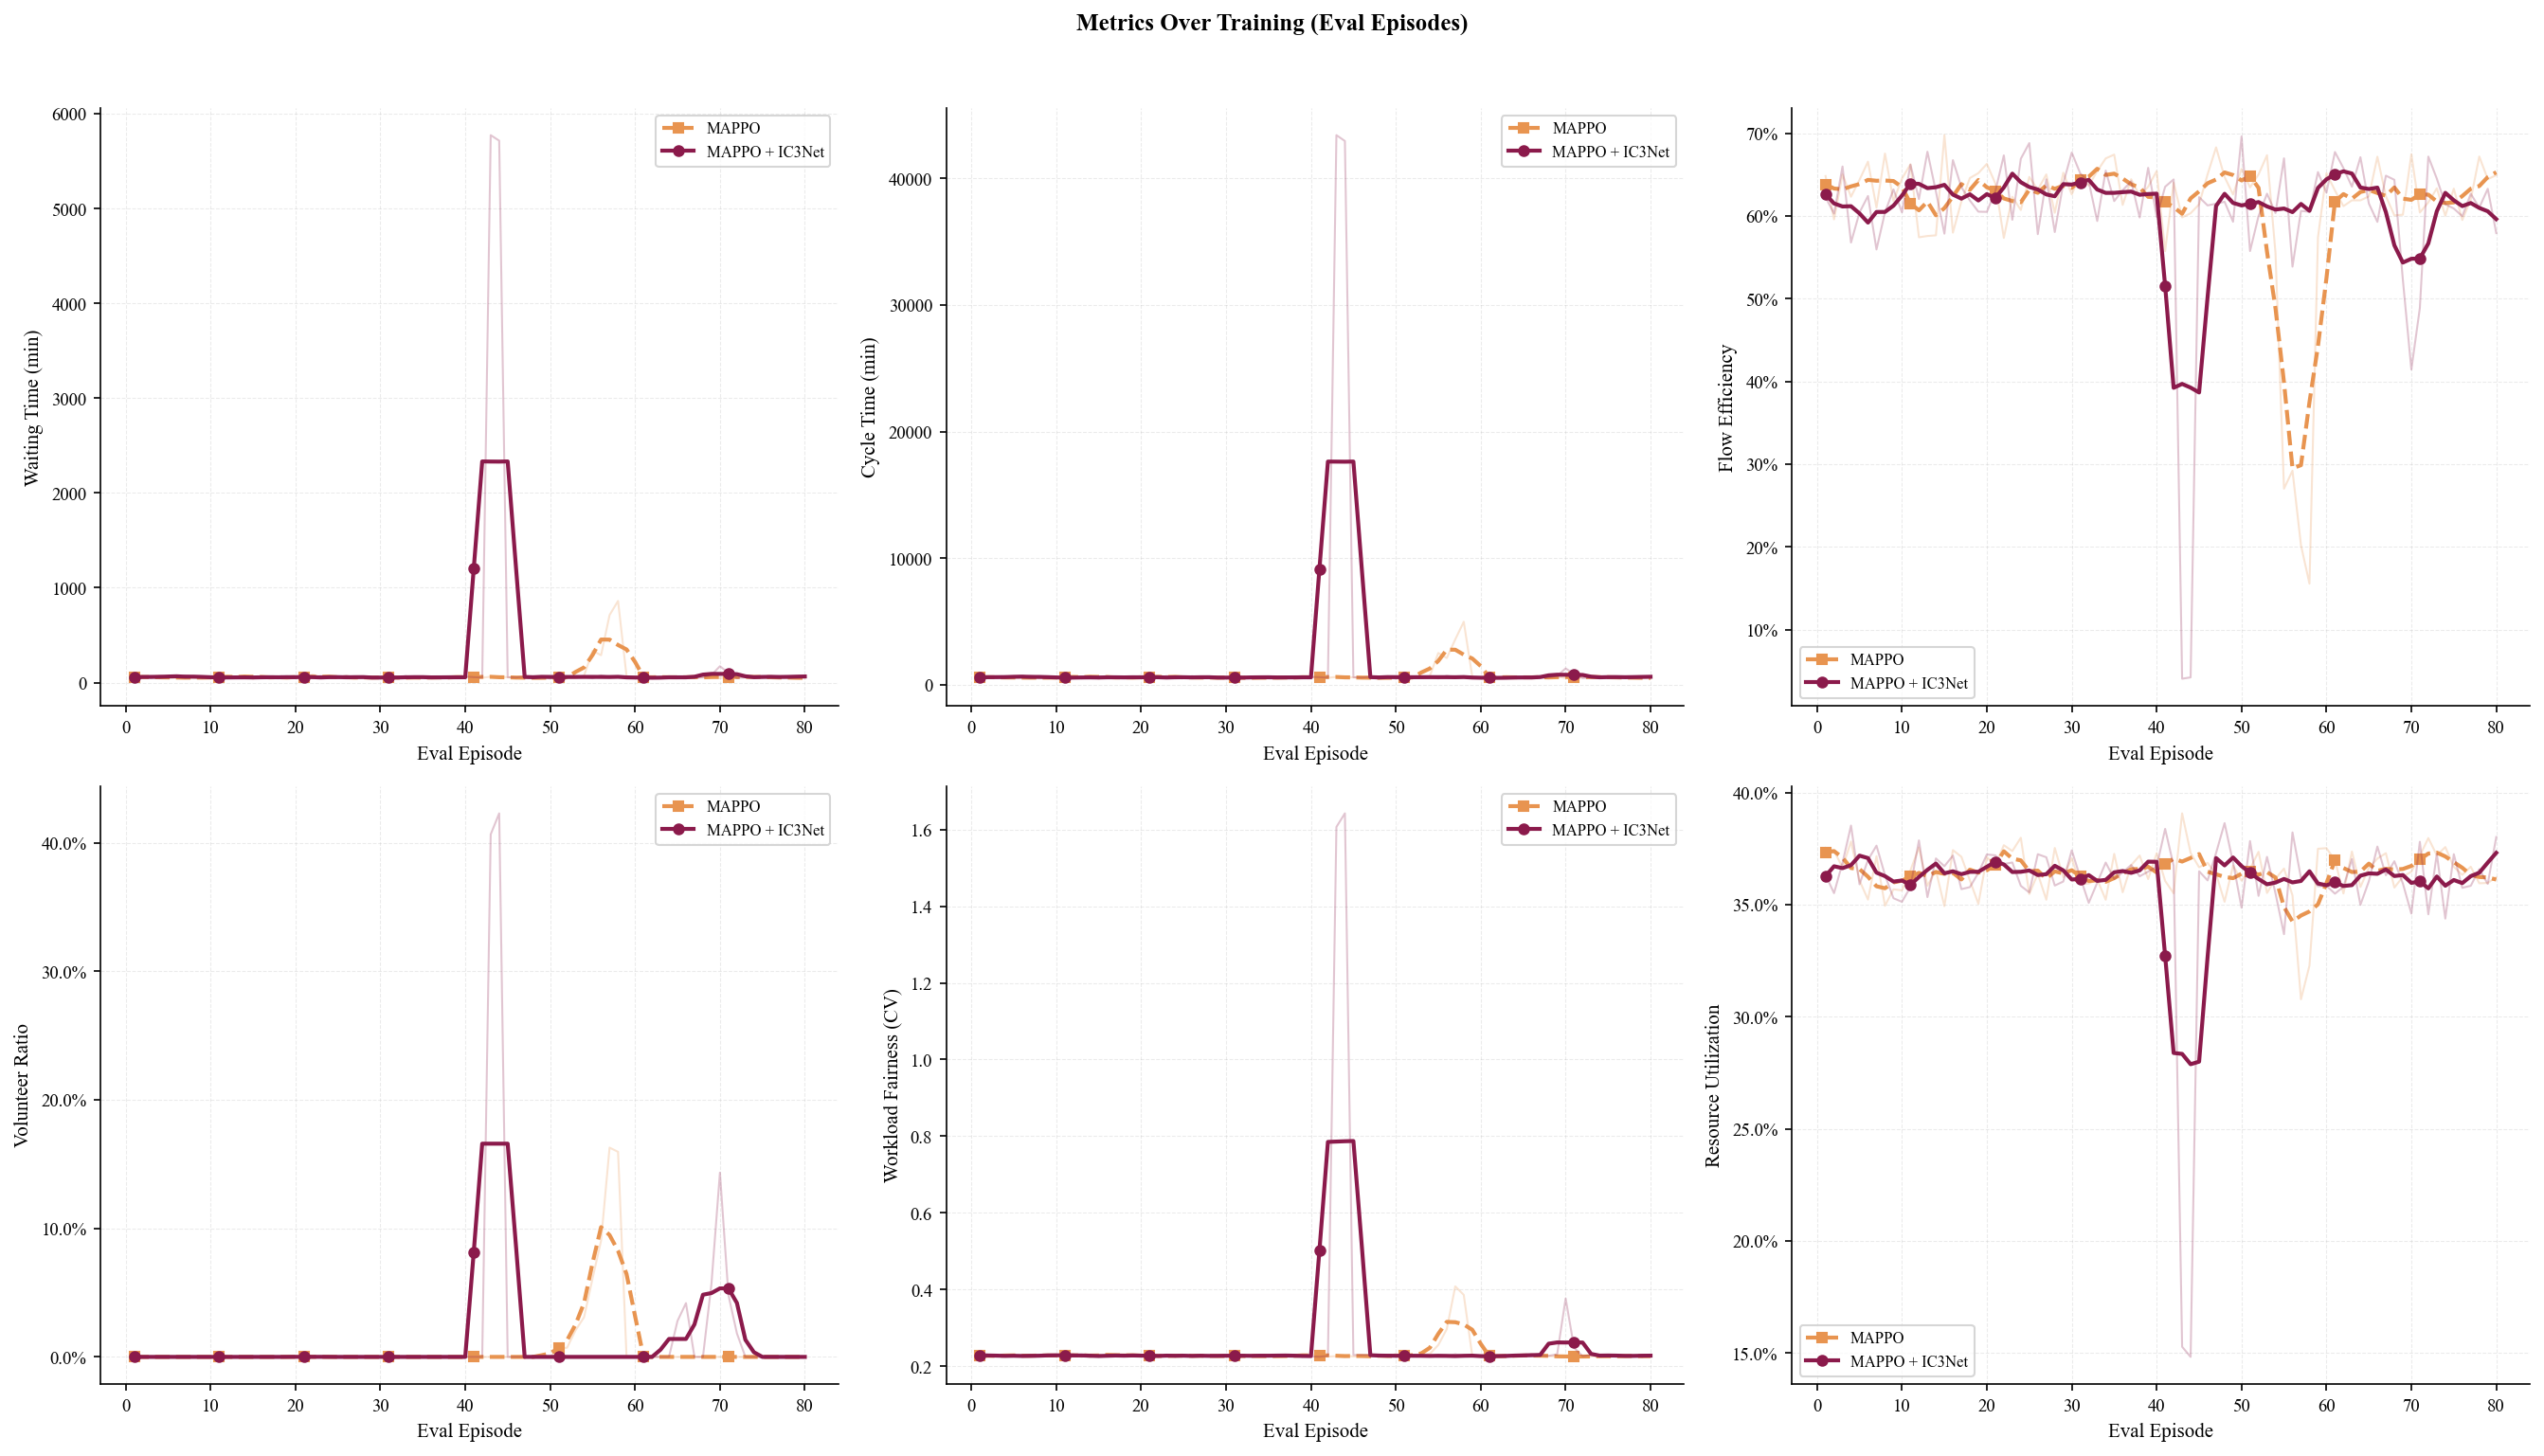

In [74]:
# ============================================================
# FIGURE 8: Operational Metrics Over Training Episodes (grayscale)
# (Uses eval logs to show how metrics evolve during training)
# ============================================================
eval_methods = discover_methods(EXPERIMENT_DIR, "eval")

if eval_methods:
    # Load eval data per episode
    eval_over_training = {}  # method -> list of metric dicts (one per eval episode)
    for name, csv_files in eval_methods.items():
        ep_metrics = []
        for f in csv_files:
            try:
                df = pd.read_csv(f)
                if len(df) == 0:
                    continue
                for col in ["case_open_time", "case_completed_time",
                            "task_assigned_time", "task_started_time", "task_completed_time"]:
                    if col in df.columns:
                        df[col] = safe_parse_timestamps(df[col])
                pm = compute_process_metrics(df)
                om = compute_operational_metrics(df, OVERLOAD_THRESHOLD)
                pm.update(om)
                ep_metrics.append(pm)
            except Exception:
                pass
        if ep_metrics:
            eval_over_training[name] = ep_metrics
    
    if eval_over_training:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle("Metrics Over Training (Eval Episodes)", fontweight="bold", y=1.02)
        
        track_metrics = [
            ("avg_waiting_time_min", "Waiting Time (min)"),
            ("avg_cycle_time_min", "Cycle Time (min)"),
            ("flow_efficiency", "Flow Efficiency"),
            ("volunteer_ratio", "Volunteer Ratio"),
            ("workload_fairness_cv", "Workload Fairness (CV)"),
            ("resource_utilization", "Resource Utilization"),
        ]
        
        for ax, (mk, ylabel) in zip(axes.flat, track_metrics):
            for name, ep_list in eval_over_training.items():
                vals = [m.get(mk, np.nan) for m in ep_list]
                eps = np.arange(1, len(vals) + 1)
                s = styles.get(name, {"color": "#333333", "linestyle": "-", "marker": "o"})
                ax.plot(eps, vals, alpha=0.25, color=s["color"], linewidth=1)
                if len(vals) >= SMOOTH_WINDOW:
                    ax.plot(eps, smooth(vals, SMOOTH_WINDOW), color=s["color"],
                            linewidth=2, linestyle=s["linestyle"], marker=s["marker"],
                            markevery=max(1, len(vals) // 8), markersize=5,
                            label=method_label(name))
                else:
                    ax.plot(eps, vals, color=s["color"], linewidth=2,
                            linestyle=s["linestyle"], marker=s["marker"],
                            markersize=5, label=method_label(name))
            ax.set_xlabel("Eval Episode")
            ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="best")
            if mk in ("flow_efficiency", "volunteer_ratio", "resource_utilization"):
                ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
        
        plt.tight_layout()
        plt.savefig("metrics_over_training.pdf", bbox_inches="tight")
        plt.show()
    else:
        print("No eval episodes found for training progression.")
else:
    print("No eval logs found — skipping training progression charts.")

In [75]:
# ============================================================
# Load Gate Activation Data (IC3Net comm only)
# ============================================================
# gate_activations.csv is saved per episode with columns:
#   step, activity, Agent1, Agent2, ...  (1=gate open, 0=closed)

gate_data = {}  # method_name -> list of DataFrames (one per episode)
for name, csv_files in methods.items():
    # Derive method dir from CSV paths: .../logs/final_eval/*.csv -> ...
    method_dir = os.path.dirname(os.path.dirname(os.path.dirname(csv_files[0])))
    episodes_dir = os.path.join(method_dir, "episodes")
    if not os.path.isdir(episodes_dir):
        continue
    ep_gates = []
    for ep_name in sorted(os.listdir(episodes_dir)):
        gate_file = os.path.join(episodes_dir, ep_name, "gate_activations.csv")
        if os.path.isfile(gate_file):
            df = pd.read_csv(gate_file)
            df["episode"] = ep_name
            ep_gates.append(df)
    if ep_gates:
        gate_data[name] = ep_gates
        print(f"{method_label(name)}: {len(ep_gates)} episodes with gate data, "
              f"{len(ep_gates[0].columns)-3} agents")

if not gate_data:
    print("No gate activation data found. Run experiments with updated trainer to generate gate_activations.csv")

No gate activation data found. Run experiments with updated trainer to generate gate_activations.csv


In [76]:
# ============================================================
# FIGURE 9a: Gate Activation per Activity Type (MAPPO + IC3Net only)
# Only comm-enabled methods shown — no-comm variant's gate is non-functional
# ============================================================
if gate_data:
    # Filter to only comm-enabled methods
    comm_gate_data = {k: v for k, v in gate_data.items() if "comm" in k}
    
    if comm_gate_data:
        fig, axes = plt.subplots(1, len(comm_gate_data), figsize=(8, 5), squeeze=False)
        fig.suptitle("Gate Activation Rate per Activity Type (MAPPO + IC3Net)", fontweight="bold", y=1.02)

        for idx, (name, ep_list) in enumerate(comm_gate_data.items()):
            ax = axes[0][idx]

            # Use last 5 episodes (converged behaviour)
            recent = ep_list[-5:]
            all_gates = pd.concat(recent, ignore_index=True)

            # Filter out empty activity rows (idle steps)
            all_gates = all_gates[all_gates["activity"].str.len() > 0]
            if all_gates.empty:
                ax.text(0.5, 0.5, "No task-level gate data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title("MAPPO + IC3Net")
                continue

            # Agent columns = everything except step, activity, episode
            agent_cols = [c for c in all_gates.columns if c not in ("step", "activity", "episode")]

            # Mean gate activation per activity, sorted by rate (high -> low)
            activity_rates = all_gates.groupby("activity")[agent_cols].mean().mean(axis=1).sort_values(ascending=True)

            colors = ["#333333" if any(kw in act.lower() for kw in ["assess", "approve", "check application"])
                      else "#999999" for act in activity_rates.index]

            bars = ax.barh(range(len(activity_rates)), activity_rates.values,
                           color=colors, edgecolor="black", linewidth=0.6)
            ax.set_yticks(range(len(activity_rates)))
            ax.set_yticklabels(activity_rates.index, fontsize=8)
            ax.set_xlabel("Gate Open Rate (0=never, 1=always)")
            ax.set_xlim(0, 1)
            ax.set_title("MAPPO + IC3Net")
            ax.axvline(0.5, color="black", linestyle=":", alpha=0.3, label="Random baseline")

            # Legend: dark = collaborative tasks
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor="#333333", edgecolor="black", label="Collaborative"),
                               Patch(facecolor="#999999", edgecolor="black", label="Solo")]
            ax.legend(handles=legend_elements, fontsize=8, loc="lower right")

        plt.tight_layout()
        plt.savefig("gate_activation_per_activity.pdf", bbox_inches="tight")
        plt.show()
    else:
        print("Skipping: no comm-enabled methods with gate data")
else:
    print("Skipping: no gate activation data available")

Skipping: no gate activation data available


In [77]:
# ============================================================
# FIGURE 9b: Gate Activation Over Training (MAPPO + IC3Net only)
# Only comm-enabled methods — no-comm variant's gate is non-functional
# ============================================================
if gate_data:
    comm_gate_data = {k: v for k, v in gate_data.items() if "comm" in k}
    
    if comm_gate_data:
        fig, axes = plt.subplots(1, len(comm_gate_data), figsize=(7, 4), squeeze=False)
        fig.suptitle("Gate Activation Rate Over Training (MAPPO + IC3Net)", fontweight="bold", y=1.02)

        for idx, (name, ep_list) in enumerate(comm_gate_data.items()):
            ax = axes[0][idx]

            agent_cols = [c for c in ep_list[0].columns if c not in ("step", "activity", "episode")]

            # Compute mean gate rate per episode
            ep_numbers = []
            ep_rates = []
            for i, df in enumerate(ep_list):
                rate = df[agent_cols].mean().mean()  # mean over agents and timesteps
                ep_numbers.append(i + 1)
                ep_rates.append(rate)

            ax.plot(ep_numbers, ep_rates, color="gray", linewidth=0.8, alpha=0.5, label="Raw")
            # Smoothed trend
            if len(ep_rates) > 5:
                window = min(5, len(ep_rates))
                smoothed = pd.Series(ep_rates).rolling(window, center=True, min_periods=1).mean()
                ax.plot(ep_numbers, smoothed, color="black", linewidth=2.5, label="Smoothed")
            ax.set_xlabel("Training Episode")
            ax.set_ylabel("Mean Gate Open Rate")
            ax.set_ylim(0, 1)
            ax.set_title("MAPPO + IC3Net")
            ax.axhline(0.5, color="black", linestyle=":", alpha=0.3, label="Random (0.5)")
            ax.legend(fontsize=8)

        plt.tight_layout()
        plt.savefig("gate_activation_over_training.pdf", bbox_inches="tight")
        plt.show()
    else:
        print("Skipping: no comm-enabled methods with gate data")
else:
    print("Skipping: no gate activation data available")

Skipping: no gate activation data available


In [78]:
# ============================================================
# FIGURE 9c: Gate Activation Heatmap (Agents x Timesteps, MAPPO + IC3Net only)
# Shows which agents communicate at which moments (last episode).
# Agents grouped by role with separator lines.
# Visuals: grayscale heatmap cells (cmap="Greys"); role-coloured labels.
# ============================================================
TITLE_FS, AXLABEL_FS, TICK_FS, ROLE_FS, CBAR_FS = 24, 20, 14, 16, 15

_HEATMAP_ROLE_COLORS = {}  # no explicit per-role colours in single-seed
_HEATMAP_FALLBACK = ["#000000", "#444444", "#777777", "#AA4444", "#4444AA"]

if gate_data:
    comm_gate_data = {k: v for k, v in gate_data.items() if "comm" in k}

    if comm_gate_data:
        n_panels = len(comm_gate_data)
        fig, axes = plt.subplots(1, n_panels, figsize=(16, 9), squeeze=False)
        fig.suptitle("Gate Activation Heatmap — Last Episode (MAPPO + IC3Net)",
                     fontweight="bold", fontsize=TITLE_FS, y=1.00)

        for idx, (name, ep_list) in enumerate(comm_gate_data.items()):
            ax = axes[0][idx]

            # Use last (pooled) episode
            last_ep = ep_list[-1]
            agent_cols = [c for c in last_ep.columns
                          if c not in ("step", "activity", "episode", "run_idx")]

            # Group agents by role and sort within groups
            def get_role(agent_name):
                return agent_name.rsplit("-", 1)[0].strip()

            role_order = {}
            for a in agent_cols:
                role = get_role(a)
                if role not in role_order:
                    role_order[role] = []
                role_order[role].append(a)

            sorted_agents = []
            role_boundaries = []  # (start_idx, role_name)
            for role in sorted(role_order.keys()):
                role_boundaries.append((len(sorted_agents), role))
                sorted_agents.extend(sorted(role_order[role]))

            # Reorder gate matrix by grouped agents
            gate_matrix = last_ep[sorted_agents].values.T  # (n_agents, n_timesteps)

            # Downsample if too many timesteps
            max_bins = 200
            n_steps = gate_matrix.shape[1]
            bin_size = 1
            if n_steps > max_bins:
                bin_size = n_steps // max_bins
                n_bins = n_steps // bin_size
                gate_matrix = gate_matrix[:, :n_bins * bin_size].reshape(
                    gate_matrix.shape[0], n_bins, bin_size
                ).mean(axis=2)

            # Grayscale heatmap cells (blokjes blijven zwart/wit/grijs)
            im = ax.imshow(gate_matrix, aspect="auto", cmap="Greys", vmin=0, vmax=1,
                           interpolation="nearest")

            # Assign role colours from the palette defined above
            role_colors = {}
            for i_role, role in enumerate(sorted(role_order.keys())):
                if role in _HEATMAP_ROLE_COLORS:
                    role_colors[role] = _HEATMAP_ROLE_COLORS[role]
                else:
                    role_colors[role] = _HEATMAP_FALLBACK[i_role % len(_HEATMAP_FALLBACK)]

            # Y-tick labels: short agent id, role-coloured, bold
            ax.set_yticks(range(len(sorted_agents)))
            short_labels = [a.rsplit("-", 1)[-1] for a in sorted_agents]
            ax.set_yticklabels(short_labels, fontsize=TICK_FS, family="monospace")
            for i_tick, agent in enumerate(sorted_agents):
                lab = ax.get_yticklabels()[i_tick]
                lab.set_color(role_colors[get_role(agent)])
                lab.set_fontweight("bold")

            # Horizontal separators + role labels on the right
            for start_idx, role in role_boundaries:
                if start_idx > 0:
                    ax.axhline(start_idx - 0.5, color="white", linewidth=2)
                n_in_role = len(role_order[role])
                mid_y = start_idx + n_in_role / 2 - 0.5
                ax.text(1.02, mid_y, role,
                        fontsize=ROLE_FS, va="center", ha="left",
                        color=role_colors[role], fontweight="bold",
                        transform=ax.get_yaxis_transform(), clip_on=False)

            # X-axis: approximate simulation time
            x_label = "Timestep"
            if bin_size > 1:
                x_label = f"Timestep (bins of {bin_size} steps)"
            ax.set_xlabel(x_label, fontsize=AXLABEL_FS, labelpad=10)
            ax.tick_params(axis="x", labelsize=TICK_FS)
            ax.set_title("MAPPO + IC3Net", fontsize=AXLABEL_FS, fontweight="bold", pad=12)

            # Colorbar — bigger label + ticks
            cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.10)
            cbar.set_label("Gate Open Rate", fontsize=AXLABEL_FS, labelpad=10)
            cbar.ax.tick_params(labelsize=TICK_FS)

        plt.tight_layout()
        plt.savefig("gate_activation_heatmap.pdf", bbox_inches="tight")
        plt.show()
    else:
        print("Skipping: no comm-enabled methods with gate data")
else:
    print("Skipping: no gate activation data available")


Skipping: no gate activation data available


---
## Summary: Combined Results Table

In [79]:
# ============================================================
# COMBINED SUMMARY TABLE (LaTeX-ready)
# ============================================================
def fmt_ms(m, s, pct=False, dec=1):
    """Format mean \u00b1 std."""
    if np.isnan(m): return "—"
    if pct: return f"{m:.{dec}%} \u00b1 {s:.{dec}%}"
    return f"{m:.{dec}f} \u00b1 {s:.{dec}f}"

rows = []
for name in method_names:
    row = {"Method": method_label(name)}
    
    # Process metrics
    pm = process_metrics[name]
    def p_agg(key):
        v = [m[key] for m in pm if not np.isnan(m.get(key, np.nan))]
        return (np.mean(v), np.std(v)) if v else (np.nan, np.nan)
    
    ct_m, ct_s = p_agg("avg_cycle_time_min")
    wt_m, wt_s = p_agg("avg_waiting_time_min")
    ut_m, ut_s = p_agg("resource_utilization")
    tp_m, tp_s = p_agg("case_throughput_per_hour")
    fe_m, fe_s = p_agg("flow_efficiency")
    
    row["Cycle Time"] = fmt_ms(ct_m, ct_s)
    row["Wait Time"] = fmt_ms(wt_m, wt_s)
    row["Utilization"] = fmt_ms(ut_m, ut_s, pct=True)
    row["Throughput"] = fmt_ms(tp_m, tp_s)
    row["Flow Eff."] = fmt_ms(fe_m, fe_s, pct=True)
    
    # Operational metrics
    om = operational_metrics[name]
    def o_agg(key):
        v = [m[key] for m in om if not np.isnan(m.get(key, np.nan))]
        return (np.mean(v), np.std(v)) if v else (np.nan, np.nan)
    
    vr_m, vr_s = o_agg("volunteer_ratio")
    wf_m, wf_s = o_agg("workload_fairness_cv")
    
    row["Vol. Ratio"] = fmt_ms(vr_m, vr_s, pct=True)
    row["Fairness (CV)"] = fmt_ms(wf_m, wf_s, dec=2)
    
    # Learning metrics (if available)
    if name in learning_metrics:
        lm = learning_metrics[name]
        row["Best Reward"] = f"{lm['best_eval_reward']:.0f}" if not np.isnan(lm.get('best_eval_reward', np.nan)) else "—"
        row["Stability"] = f"{lm['stability_cv']:.3f}" if not np.isnan(lm.get('stability_cv', np.nan)) else "—"
    else:
        row["Best Reward"] = "—"
        row["Stability"] = "—"
    
    rows.append(row)

df_combined = pd.DataFrame(rows).set_index("Method")

print(f"\n{'='*110}")
print(f"  Combined Results Summary ({time_label})")
print(f"{'='*110}")
display(df_combined)

# ── LaTeX export ──
latex = df_combined.to_latex(escape=False)
print("\n\nLaTeX table:\n")
print(latex)


  Combined Results Summary (working hours (07:00-15:00))


,Cycle Time,Wait Time,Utilization,Throughput,Flow Eff.,Vol. Ratio,Fairness (CV),Best Reward,Stability
Method,,,,,,,,,
MAPPO + IC3Net,559.5 ± 106.2,54.5 ± 17.6,33.4% ± 2.1%,1.2 ± 0.0,65.4% ± 6.4%,0.0% ± 0.0%,0.26 ± 0.01,-24667,0.001
MAPPO,1235.7 ± 395.5,176.6 ± 78.4,28.1% ± 2.9%,1.0 ± 0.1,40.1% ± 11.6%,10.1% ± 4.8%,0.38 ± 0.07,-31711,0.041
Random,539.2 ± 85.3,50.2 ± 12.1,33.7% ± 1.7%,1.2 ± 0.0,66.5% ± 5.9%,89.1% ± 0.6%,0.26 ± 0.01,—,—
Best Median,3315.1 ± 491.8,739.9 ± 179.8,26.9% ± 1.6%,0.8 ± 0.1,15.3% ± 1.7%,100.0% ± 0.0%,0.91 ± 0.01,—,—
Shortest Queue,321.7 ± 30.2,13.8 ± 3.6,34.0% ± 1.6%,1.3 ± 0.0,102.5% ± 5.2%,100.0% ± 0.0%,0.25 ± 0.01,—,—
Baseline Ground Truth,525.1 ± 102.8,47.4 ± 15.7,34.1% ± 2.0%,1.2 ± 0.0,70.8% ± 7.6%,0.0% ± 0.0%,0.23 ± 0.00,—,—




LaTeX table:

\begin{tabular}{llllllllll}
\toprule
 & Cycle Time & Wait Time & Utilization & Throughput & Flow Eff. & Vol. Ratio & Fairness (CV) & Best Reward & Stability \\
Method &  &  &  &  &  &  &  &  &  \\
\midrule
MAPPO + IC3Net & 559.5 ± 106.2 & 54.5 ± 17.6 & 33.4% ± 2.1% & 1.2 ± 0.0 & 65.4% ± 6.4% & 0.0% ± 0.0% & 0.26 ± 0.01 & -24667 & 0.001 \\
MAPPO & 1235.7 ± 395.5 & 176.6 ± 78.4 & 28.1% ± 2.9% & 1.0 ± 0.1 & 40.1% ± 11.6% & 10.1% ± 4.8% & 0.38 ± 0.07 & -31711 & 0.041 \\
Random & 539.2 ± 85.3 & 50.2 ± 12.1 & 33.7% ± 1.7% & 1.2 ± 0.0 & 66.5% ± 5.9% & 89.1% ± 0.6% & 0.26 ± 0.01 & — & — \\
Best Median & 3315.1 ± 491.8 & 739.9 ± 179.8 & 26.9% ± 1.6% & 0.8 ± 0.1 & 15.3% ± 1.7% & 100.0% ± 0.0% & 0.91 ± 0.01 & — & — \\
Shortest Queue & 321.7 ± 30.2 & 13.8 ± 3.6 & 34.0% ± 1.6% & 1.3 ± 0.0 & 102.5% ± 5.2% & 100.0% ± 0.0% & 0.25 ± 0.01 & — & — \\
Baseline Ground Truth & 525.1 ± 102.8 & 47.4 ± 15.7 & 34.1% ± 2.0% & 1.2 ± 0.0 & 70.8% ± 7.6% & 0.0% ± 0.0% & 0.23 ± 0.00 & — & — \\
\bottom